## Generates plots and analysis for the EEG dataset in Chapter 5

In [1]:
import math
import statsmodels.graphics.tsaplots

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit, vectorize, types, typed
from matplotlib.ticker import MaxNLocator
from numba.typed import Dict
from seaborn import kdeplot, heatmap
from scipy.special import logsumexp, hyp2f1
from functools import lru_cache
from time import perf_counter
from scipy.stats import beta, norm


# @vectorize(['float64(float64)', 'float32(float32)'], nopython=True)
def lgamma_numba(x):
    return math.lgamma(x)

# @njit(fastmath=True)
def dgamma(x, a, b, log=False):
    log_val = a*np.log(b) - lgamma_numba(a) + (a-1)*np.log(x) - b*x 
    if log:
        return log_val 
    else:
        return np.exp(log_val)

def dnorm(x, mu, sd, log=False):
    v = sd**2
    if log:
        return -0.5*np.log(2*np.pi*v) - 0.5*(x-mu)**2 / v
    else:
        return np.sqrt(2*np.pi*v)**(-1) * np.exp(-0.5*(x-mu)**2 / v)

def sample_posterior(y, x, params):
    lam, a, b = params
    sum_yy = np.sum(y*y)
    sum_xy = np.sum(x*y)
    sum_xx = np.sum(x*x)
    n = y.size
    
    a_n = a + 0.5 * n
    lam_n = lam + sum_xx
    m_n = sum_xy / lam_n
    b_n = b + 0.5 * (sum_yy - m_n * m_n * lam_n)

    sigma2 = 1 / np.random.gamma(a_n, 1/b_n)
    phi = np.random.normal(m_n, np.sqrt(sigma2/lam_n))
    return phi, sigma2

def compute_waic(y_, states, params):

    y = y_[:, 1:]
    x = y_[:, :-1]

    state_store = [states[i, :].reshape(y.shape[0], y.shape[1]) for i in range(states.shape[0])]
    
    d, T_ = y.shape

    likelihood_sums = np.zeros(d*(T_), dtype=np.float64)
    log_likelihood_sums = np.zeros(d*(T_), dtype=np.float64)
    log_likelihood_2_sums = np.zeros(d*(T_), dtype=np.float64)

    n_samples = len(state_store)
    
    for ind, states in enumerate(state_store):
        print(ind)

        unique = np.unique(states)
        thetas = {}
        for key in unique:
            y_k = y[states == key]
            x_k = x[states == key]

            thetas[key] = sample_posterior(y_k, x_k, params)
        
        for j in range(d):
            for t in range(T_):
                i = j*(T_) + t
                s = states[j, t]
                phi, sigma2 = thetas[s]
                like = dnorm(y[j, t], phi*x[j, t], np.sqrt(sigma2))
                likelihood_sums[i] += like
                log_likelihood_sums[i] += np.log(like)
                log_likelihood_2_sums[i] += np.log(like)*np.log(like)
    
    lppd = 0.0
    penalty = 0.0
    for j in range(d):
        for t in range(T_):
            i = j*(T_) + t
            lppd += np.log(likelihood_sums[i] / (n_samples))
            penalty += (log_likelihood_2_sums[i] - log_likelihood_sums[i]*log_likelihood_sums[i]/n_samples) / (n_samples - 1)
    
    print("lppd = ", lppd) 
    print("waic = ", -2*(lppd - penalty))

In [2]:
def order_of_appearance(arr1, arr2):

    out1 = []
    out2 = []
    
    vals = dict()
    counter = 1
    for (i, j) in zip(arr1, arr2):
        if i in vals:
            out1.append(vals[i])
        else:
            vals[i] = counter
            counter += 1
            out1.append(vals[i])

        if j in vals:
            out2.append(vals[j])
        else:
            vals[j] = counter
            counter += 1
            out2.append(vals[j])

    return out1, out2

def beta_tail(x, M, p):

    y = 1.0 - x

    return M * (y**p / p) * hyp2f1(p, 1.0, p + 1.0, y)

def beta_tail_prime(x, M, p):

    return -M * (1.0 - x)**(p - 1.0) / x

def inverse_tail(gamma, M, p,
                 tol=1e-12,
                 maxiter=100):

    # asymptotic starting guess
    x = np.exp(-gamma / M)

    for _ in range(maxiter):

        f = beta_tail(x, M, p) - gamma
        fp = beta_tail_prime(x, M, p)

        x_new = x - f / fp

        # stay inside (0,1)
        x_new = np.clip(x_new, 1e-14, 1 - 1e-14)

        if abs(x_new - x) < tol:
            return x_new

        x = x_new

    return x

def fk_beta_process_epsilon(M, p, epsilon, seed=None):
    
    # stopping threshold:
    # generate while Γ_i < N(epsilon)
    RNG = np.random.default_rng(seed)
    gamma_max = beta_tail(epsilon, M, p)

    jumps = []
    gammas = []

    gamma = 0.0

    while gamma < gamma_max:

        gamma += RNG.exponential()

        if gamma >= gamma_max:
            break

        jump = inverse_tail(gamma, M, p)

        jumps.append(jump)
        gammas.append(gamma)

    return np.array(jumps)

def sim_corm_prior(n_samps, n, M, phi, q, epsilon=1e-10):

    n_clusters1 = []
    n_clusters2 = []
    n_shared = []
    
    for i in range(n_samps):
        directing_jumps = fk_beta_process_epsilon(M, phi, epsilon)
        n_jumps = len(directing_jumps)
        
        series1_jumps = directing_jumps * np.random.gamma(phi, 1, n_jumps)
        series2_jumps = directing_jumps * np.random.gamma(phi, 1, n_jumps)
        
        series1_jumps /= np.sum(series1_jumps)
        series2_jumps /= np.sum(series2_jumps)
        
        s1_clusters = np.random.choice(len(series1_jumps), n, p=series1_jumps)
        s2_clusters = np.random.choice(len(series1_jumps), n, p=series2_jumps)

        s1_cps = np.random.binomial(1, q[0], n)
        s2_cps = np.random.binomial(1, q[1], n)
        s1_cps[0] = s2_cps[0] = 1
        
        s1_states_unique = np.unique(s1_clusters[s1_cps == 1])
        s2_states_unique = np.unique(s2_clusters[s2_cps == 1])
        
        shared = np.intersect1d(s1_states_unique, s2_states_unique)
        
        n_clusters1.append(len(s1_states_unique))
        n_clusters2.append(len(s2_states_unique))
        n_shared.append(len(shared))
    
    return np.mean(n_clusters1), np.var(n_clusters1), np.mean(n_clusters2), np.var(n_clusters2), np.mean(n_shared), np.var(n_shared)


def sim_corm_trajectory(n, M, phi, q, seed=1, epsilon=1e-10):
    
    RNG = np.random.default_rng(seed)
    
    directing_jumps = fk_beta_process_epsilon(M, phi, epsilon, seed)
    n_jumps = len(directing_jumps)
    
    series1_jumps = directing_jumps * RNG.gamma(phi, 1, n_jumps)
    series2_jumps = directing_jumps * RNG.gamma(phi, 1, n_jumps)
    
    series1_jumps /= np.sum(series1_jumps)
    series2_jumps /= np.sum(series2_jumps)
    
    s1_clusters = RNG.choice(len(series1_jumps), n, p=series1_jumps)
    s2_clusters = RNG.choice(len(series1_jumps), n, p=series2_jumps)
    
    s1_cps = RNG.binomial(1, q[0], n)
    s2_cps = RNG.binomial(1, q[1], n)
    s1_cps[0] = s2_cps[0] = 1
    
    states_1 = np.cumsum(s1_cps*s1_clusters)
    states_2 = np.cumsum(s2_cps*s2_clusters)

    for i in range(n):
        if s1_cps[i]:
            states_1[i] = s1_clusters[i]
        else:
            states_1[i] = states_1[i-1]

        if s2_cps[i]:
            states_2[i] = s2_clusters[i]
        else:
            states_2[i] = states_2[i-1]
        
    return order_of_appearance(states_1, states_2)

    


In [8]:
phis = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
Ts = [200, 400, 600]
Ms = [1, 2, 3]
q = [0.05, 0.05]

n_iter = 10000

means = {}
variances = {}
for M in Ms:
    means[M] = []
    variances[M] = []
    for T_ in Ts:
        means[M].append([])
        variances[M].append([])
        for phi in phis:
            _, _, _, _, m, v = sim_corm_prior(n_samps=n_iter, n=T_, M=M, phi=phi, q=q)
            print(f'T = {T_}, M = {M}, phi = {phi}, q = {q}, mean shared = {m}, var shared = {v}')
            means[M][-1].append(m)
            variances[M][-1].append(v)

T = 200, M = 1, phi = 0.1, q = [0.05, 0.05], mean shared = 0.6876, var shared = 0.5550062400000001
T = 200, M = 1, phi = 0.2, q = [0.05, 0.05], mean shared = 1.0971, var shared = 0.7138715899999999
T = 200, M = 1, phi = 0.3, q = [0.05, 0.05], mean shared = 1.3606, var shared = 0.78536764
T = 200, M = 1, phi = 0.4, q = [0.05, 0.05], mean shared = 1.534, var shared = 0.7902440000000001
T = 200, M = 1, phi = 0.5, q = [0.05, 0.05], mean shared = 1.6751, var shared = 0.79633999
T = 200, M = 1, phi = 0.6, q = [0.05, 0.05], mean shared = 1.7648, var shared = 0.81948096
T = 200, M = 1, phi = 0.7, q = [0.05, 0.05], mean shared = 1.8292, var shared = 0.8104273599999999
T = 200, M = 1, phi = 0.8, q = [0.05, 0.05], mean shared = 1.8739, var shared = 0.7989987900000001
T = 200, M = 1, phi = 0.9, q = [0.05, 0.05], mean shared = 1.9283, var shared = 0.78955911
T = 200, M = 1, phi = 1.0, q = [0.05, 0.05], mean shared = 1.9683, var shared = 0.8124951100000001
T = 200, M = 1, phi = 1.1, q = [0.05, 0.05]

In [91]:
sim_corm_prior(n_samps=10000, n=200, M=3, phi=0.5, q=[0.1, 0.1])

(6.6247, 3.86124991, 6.6384, 3.7710454400000004, 3.206, 1.861364)

In [92]:
sim_corm_prior(n_samps=10000, n=200, M=3, phi=1.5, q=[0.1, 0.1])

(6.6429, 3.77197959, 6.6359, 3.79973119, 4.174, 1.9361239999999997)

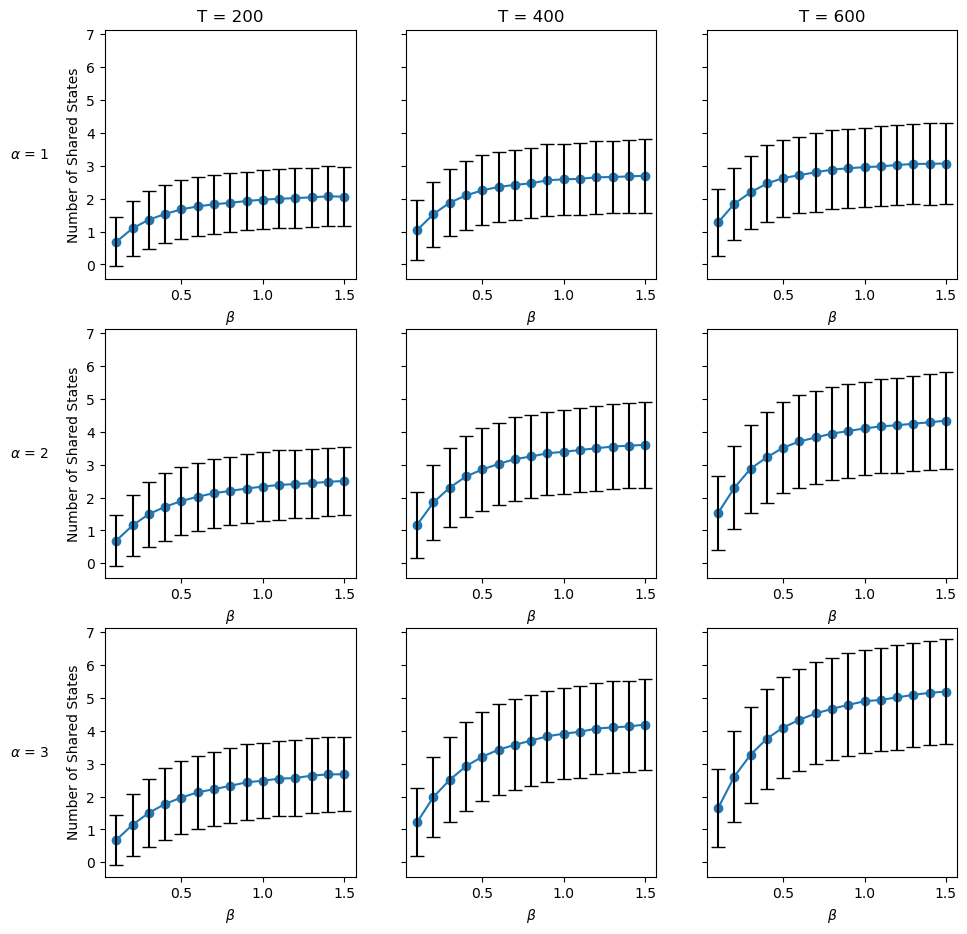

In [9]:
# plot above
fig, ax = plt.subplots(3, 3, figsize=(11, 11), sharey=True)
for i, M in enumerate(Ms):
    for j, T_ in enumerate(Ts):
        ax[i, j].plot(phis, means[M][j], marker='o', linestyle='-')
        
        # Add vertical error bars
        # print(len(means[i]))
        # print(len(variances[i]))
        ax[i, j].errorbar(phis, means[M][j], yerr=np.sqrt(np.array(variances[M][j])), fmt='none', capsize=5,ecolor='black')
        ax[i, j].set_xlabel(r'$\beta$')
        
        if i == 0:
            ax[i, j].set_title(f"T = {T_}")

        # if i == 0:
        #     ax[i, j].set_title(f"T = {T_}")
        # if j == 0:
        #     ax[i, j].set_ylabel(f'M = {M} \n Number of Shared States')

        if j == 0:
            ax[i, j].set_ylabel('Number of Shared States')
            alpha = r'$\alpha$'
            ax[i, j].text(
                -0.3, 0.5,
                f'{alpha} = {M}',
                transform=ax[i, j].transAxes,
                rotation=0,
                va='center',
                ha='center'
            )
        
plt.show()
fig.savefig('images/sncorm_n_shared.pdf', bbox_inches='tight', format='pdf')

49587


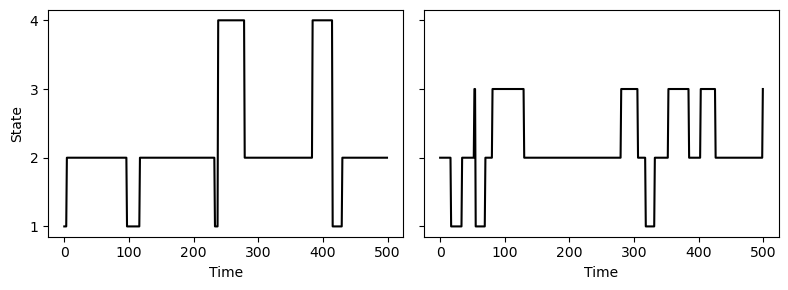

In [419]:
n = 500
M = 1

q = [0.05, 0.05]

seed = 49587
# seed = int(np.random.rand()*100000)

phis = [1]

print(seed)
fig, axs = plt.subplots(len(phis), 2, figsize=(8, 3), sharey='row', sharex=True)
for i, phi in enumerate(phis):
    
    states1, states2 = sim_corm_trajectory(n=n, M=M, phi=phi, q=q, seed=seed)
    
    axs[0].plot(states1, color='black')
    axs[0].set_ylabel('State')
    axs[0].yaxis.set_major_locator(MaxNLocator(integer=True))
    phi_ = r'$\beta$'
    
    # axs[0].text(-0.19, 0.5, f'{phi_} = {phi}', transform=axs[0].transAxes, rotation=0, va='center', ha='center')
    
    axs[1].plot(states2, color='black')
    
    axs[1].set_yticks([])
    axs[1].yaxis.set_major_locator(MaxNLocator(integer=True))

    if i == len(phis)-1:
        axs[0].set_xlabel('Time')
        axs[1].set_xlabel('Time')

fig.tight_layout()
fig.savefig('images/eeg_prior_state_sim.pdf', bbox_inches='tight', format='pdf')

plt.show()

In [2]:
eeg_dat = np.loadtxt('eeg_dat.csv', delimiter=',')
d, n = eeg_dat.shape
names = ['FP1-F7', 'F7-T7', 'T7-P7', 'FP2-F8', 'F8-T8', 'T8-P8']
times = np.arange(n-1)
start = 325
end = 340
dx = (end-start) / n
times = []
for i in range(n):
    times.append(start + i*dx)
print(eeg_dat.shape)

(6, 1279)


In [5]:
# load MCMC samples
states = np.loadtxt(f'eeg_results/sncorm_states.csv', delimiter=',', dtype=np.int64)
print(len(states))
state_store = [states[i, :].reshape(d, n-2) for i in range(states.shape[0])]
store_M = np.loadtxt(f'eeg_results/sncorm_Ms.csv', delimiter=',').flatten()
store_phi = np.loadtxt(f'eeg_results/sncorm_phis.csv', delimiter=',').flatten()

10000


Plot Series Coloured by States

9


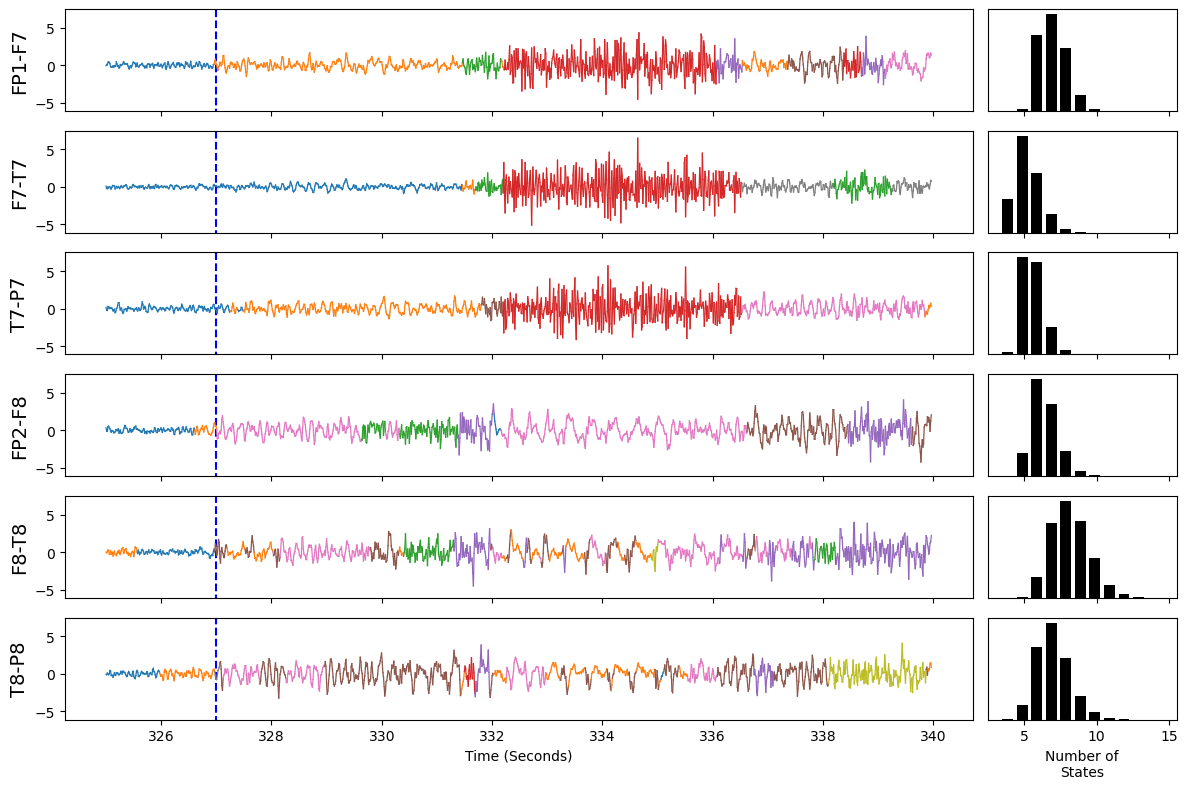

In [82]:
samp_ind = 9000
samp_states = state_store[samp_ind]
max_state = np.max(samp_states) + 1

print(max_state)

all_counts = [
    len(set(state_store[i][j, :]))
    for i in range(len(state_store))
    for j in range(d)
]

min_count = min(all_counts)
max_count_hist = max(all_counts)

# Integer-centered aligned bins
bins = np.arange(min_count - 1.5, max_count_hist + 1.5, 1)

fig, axs = plt.subplots(
    d,
    2,
    sharex='col',
    figsize=(12, 8),
    gridspec_kw={'width_ratios': [12, 2.5]}
)

# Ensure axs is always 2D
axs = np.atleast_2d(axs)

for j in range(d):

    ax_ts = axs[j, 0]
    ax_hist = axs[j, 1]

    ax_ts.vlines([327], -100, 100, color='blue', linestyle='dashed')

    ax_ts.set_ylabel( names[j], fontsize=14, rotation=90)

    ax_ts.set_ylim(
        np.min(eeg_dat) - 1,
        np.max(eeg_dat) + 1
    )

    for i in range(samp_states.shape[1] - 1):

        color = plt.cm.tab10(
            samp_states[j, i] / max_state
        )

        ax_ts.plot(times[i:i+2], eeg_dat[j, i:i+2], lw=0.9, color=color)

    if j == (d - 1):
        ax_ts.set_xlabel('Time (Seconds)')

    counts = [len(set(state_store[i][j, :])) for i in range(len(state_store))]

    ax_hist.hist(counts, bins=bins, color='black', density=True, align='mid', width=0.75)

    ax_hist.set_xlim(
        min_count - 1.5,
        max_count_hist + 1.5
    )
    ax_hist.set_yticks([])
    # ax_hist.set_ylabel('Density')
    if j == (d - 1):
        ax_hist.set_xlabel('Number of\nStates')

plt.tight_layout()

fig.savefig('images/eeg_sncorm_states.pdf', bbox_inches='tight', format='pdf')

plt.show()

Plot Number of States per Series and the Number of Shared States Across Series

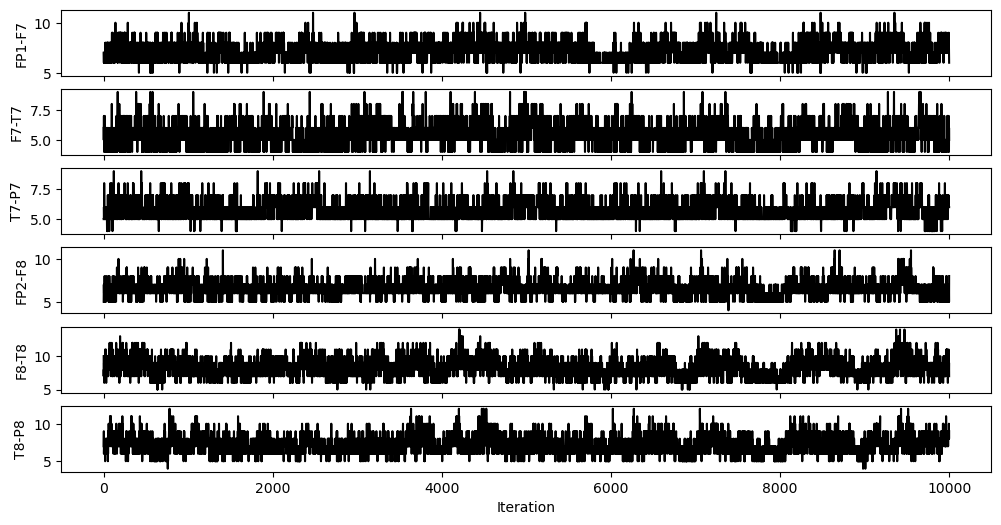

In [32]:
fig, ax = plt.subplots(6, 1, sharex=True, figsize=(12, 6))
for j in range(d):
    n_states = [len(set(state_store[i][j, :])) for i in range(len(state_store))]
    ax[j].plot(n_states, color='black')
    ax[j].set_ylabel(names[j])
    if j == (d-1):
        ax[j].set_xlabel('Iteration')
plt.show()

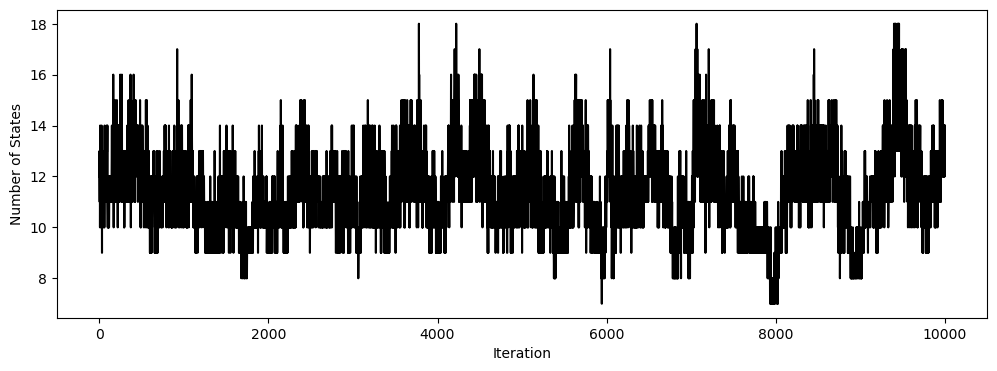

In [73]:
# total states
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(12, 4))
n_states = [len(set(states[i])) for i in range(len(states))]
ax.plot(n_states, color='black')
ax.set_xlabel('Iteration')
ax.set_ylabel('Number of States')
plt.show()

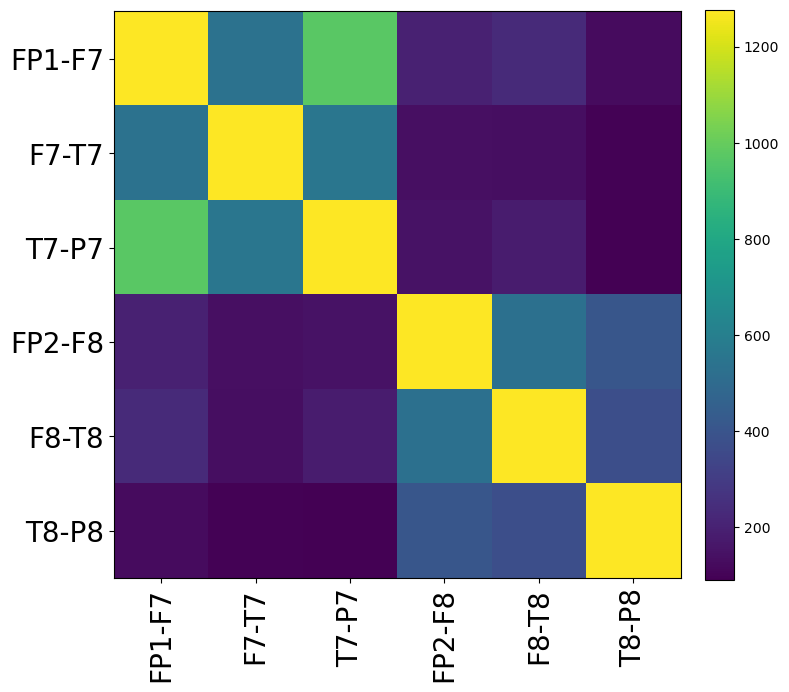

In [34]:
# heatmap where cell (i, j) is the intersection of s_{0:T, i} and s_{0:T, j}
grid = np.zeros((d, d))
for k in range(len(state_store)):
    for i in range(d):
        grid[i, i] += len(state_store[k][j, :])
        for j in range(i+1, d):
            i_set = state_store[k][i, :]
            j_set = state_store[k][j, :]
            c = np.sum(i_set == j_set)
            grid[i, j] += c
            grid[j, i] += c

grid /= len(state_store)

ticks = np.arange(d)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names, rotation=90)
ax.set_yticklabels(names)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)
img = ax.imshow(grid, cmap="viridis")
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
fig.savefig('images/eeg_heatmap.pdf', bbox_inches='tight', format='pdf')
plt.show()


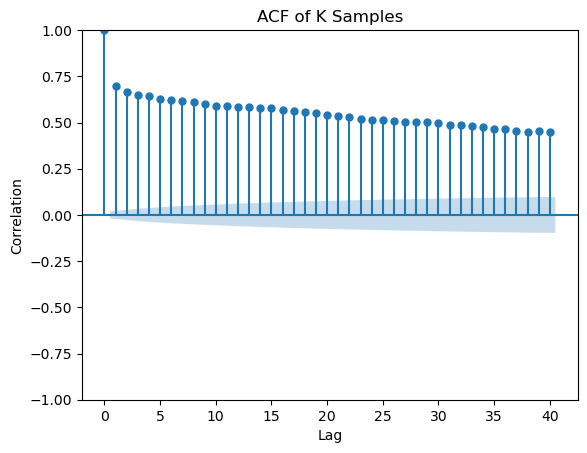

In [35]:
fig, ax = plt.subplots(1, 1)
statsmodels.graphics.tsaplots.plot_acf(np.array(n_states), ax=ax)
ax.set_title('ACF of K Samples')
ax.set_ylabel('Correlation')
ax.set_xlabel('Lag')
plt.show()

Plot M and Phi posterior densities

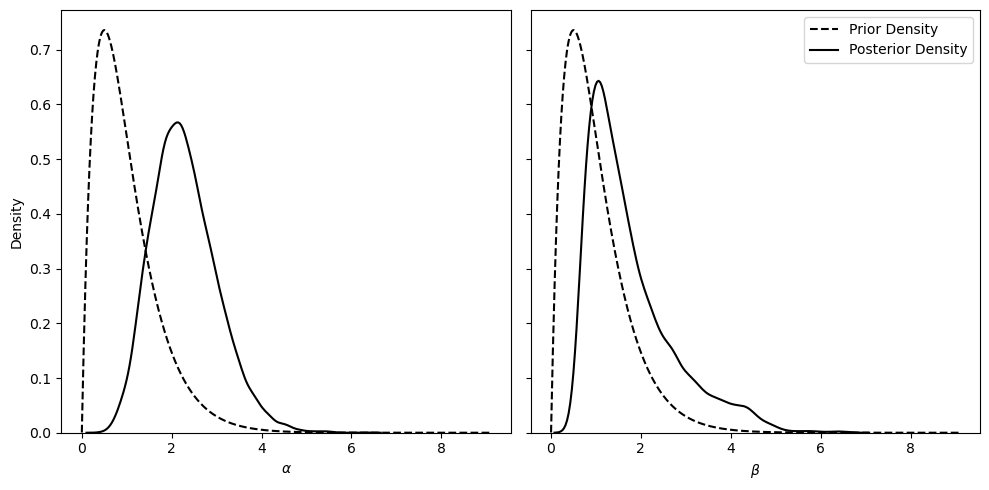

In [7]:
# density of M and phi
max_ = max(np.max(store_M), np.max(store_phi))
M_x_vals = np.arange(0.0001, max_ + 2.5, 0.01)
phi_x_vals = np.arange(0.0001, max_ + 2.5, 0.01)

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

M_a, M_b = 2.0, 2.0
phi_a, phi_b = 2.0, 2.0

ax[0].plot(M_x_vals, dgamma(M_x_vals, M_a, M_b), label='Prior Density', color='black', linestyle='--')
# ax[0].plot(M_x_vals, kde_M(M_x_vals), label='Posterior Density', color='black')
kdeplot(store_M, ax=ax[0], color='black', label='Posterior Density')
ax[0].set_ylabel('Density')
ax[0].set_xlabel(r'$\alpha$')
# ax[0].set_xlim(-0.1, 4)

ax[1].plot(phi_x_vals, dgamma(phi_x_vals, phi_a, phi_b), label='Prior Density', color='black', linestyle='--')
# ax[1].plot(phi_x_vals, kde_phi(phi_x_vals), label='Posterior Density', color='black')
kdeplot(store_phi, ax=ax[1], color='black', label='Posterior Density')
ax[1].set_ylabel('Density')
ax[1].set_xlabel(r'$\beta$')
ax[1].legend(loc='upper right')
# ax[1].set_xlim(-0.1, 4)
fig.tight_layout()
fig.savefig('images/eeg_corm_phi_M.pdf', bbox_inches='tight', format='pdf')
plt.show()

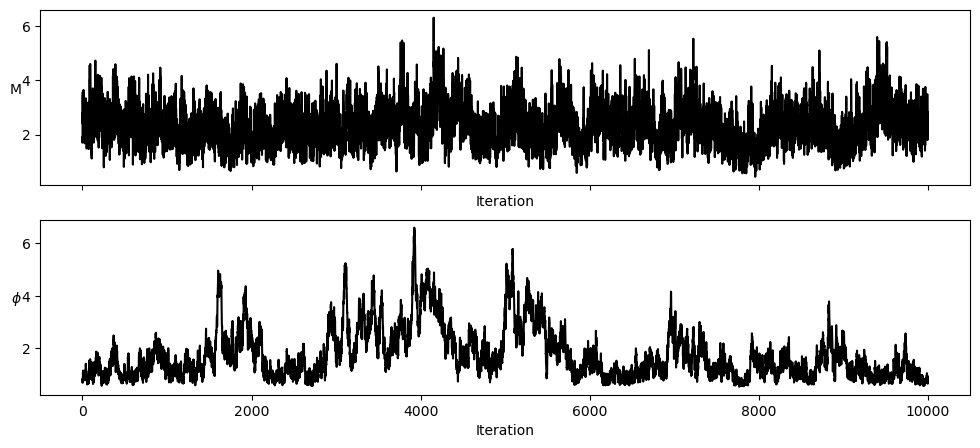

In [37]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 5))
ax[0].plot(store_M, color='black')
ax[0].set_ylabel('M', rotation=0)
ax[0].set_xlabel('Iteration')

ax[1].plot(store_phi, color='black')
ax[1].set_ylabel(r'$\beta$', rotation=0)
ax[1].set_xlabel('Iteration')

plt.show()

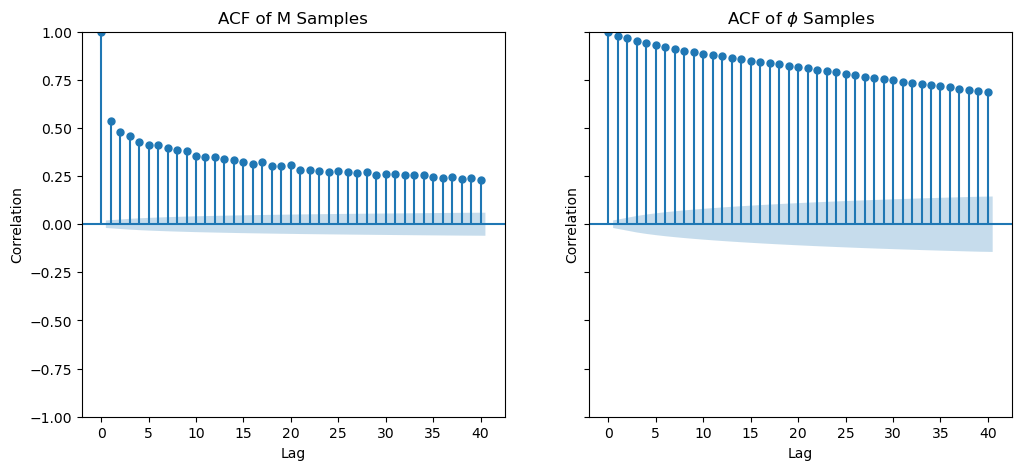

In [38]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 5))
statsmodels.graphics.tsaplots.plot_acf(store_M, ax=ax[0])
ax[0].set_title('ACF of M Samples')
ax[0].set_ylabel('Correlation')
ax[0].set_xlabel('Lag')

statsmodels.graphics.tsaplots.plot_acf(store_phi, ax=ax[1])
ax[1].set_title(r'ACF of $\beta$ Samples')
ax[1].set_ylabel('Correlation')
ax[1].set_xlabel('Lag')

plt.show()

## Posterior Checks

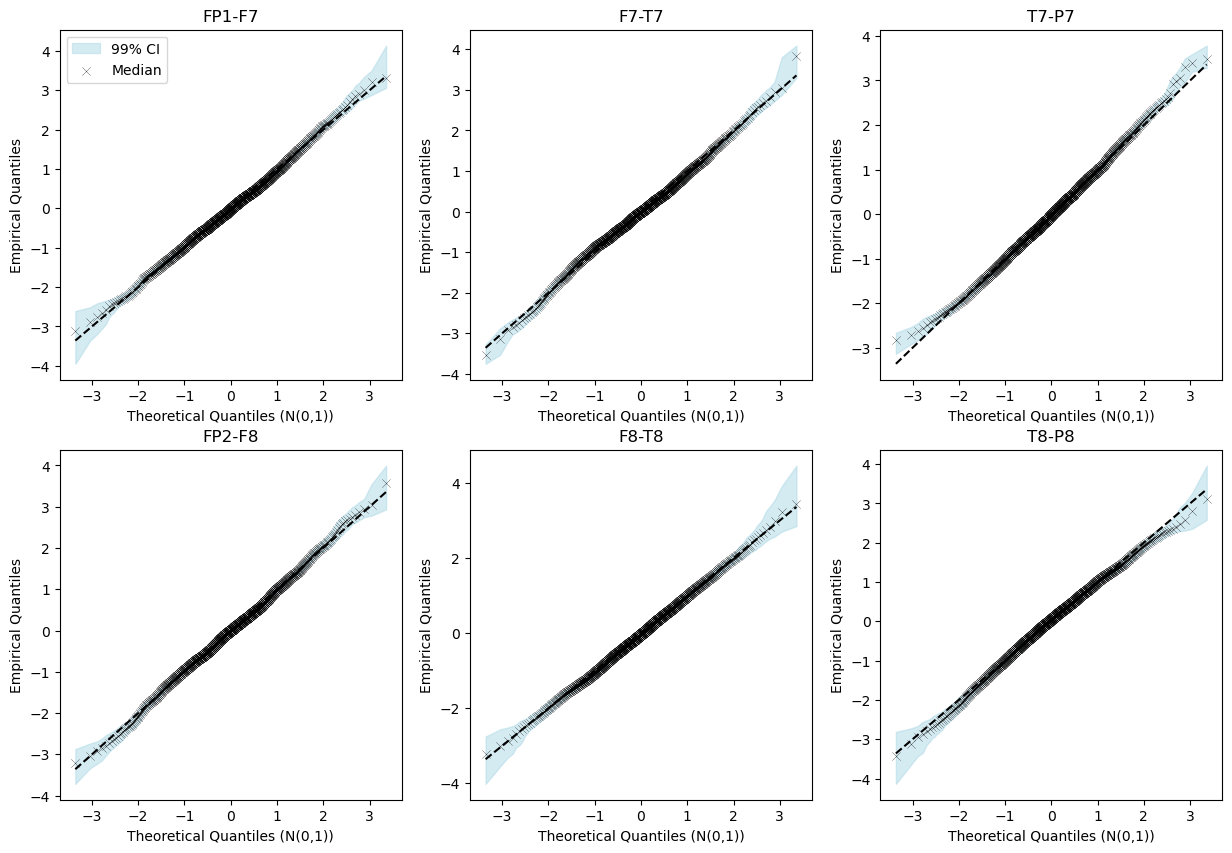

In [95]:

def bayesian_qqplot(ax, residuals, alpha=0.05, legend=True):
    """
    residuals: array of shape (n_draws, n_points)
    alpha: envelope level (e.g. 0.05 → 95% interval)
    """
    n_draws, n_points = residuals.shape

    # Sort each row (empirical quantiles)
    sorted_resid = np.sort(residuals, axis=1)
    
    # Theoretical quantiles (same for all rows)
    probs = (np.arange(1, n_points + 1) - 0.5) / n_points
    theo_q = norm.ppf(probs)

    # Compute envelope across draws
    lower = np.percentile(sorted_resid, 100 * (alpha / 2), axis=0)
    upper = np.percentile(sorted_resid, 100 * (1 - alpha / 2), axis=0)
    median = np.median(sorted_resid, axis=0)

    # Envelope
    ax.fill_between(theo_q, lower, upper, color='lightblue', alpha=0.5, label=f'{int((1-alpha)*100)}% CI')

    # Median line
    ax.scatter(theo_q, median, color='black', label='Median', linewidth=0.2, marker='x')
    
    # Reference line
    ax.plot(theo_q, theo_q, 'k--')
    
    ax.set_xlabel('Theoretical Quantiles (N(0,1))')
    ax.set_ylabel('Empirical Quantiles')
    if legend:
        ax.legend(loc='upper left')

def acf_lag(x, lag):
    n = len(x)
    
    # Compute mean
    mean = 0.0
    for i in range(n):
        mean += x[i]
    mean /= n

    # Compute variance (denominator)
    var = 0.0
    for i in range(n):
        diff = x[i] - mean
        var += diff * diff

    # Compute covariance at lag
    cov = 0.0
    for i in range(n - lag):
        cov += (x[i] - mean) * (x[i + lag] - mean)

    # Normalize
    if var == 0.0:
        return 0.0
    
    return cov / var

names = ['FP1-F7', 'F7-T7', 'T7-P7', 'FP2-F8', 'F8-T8', 'T8-P8']
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for i in range(2):
    for j in range(3):
        ind = 3*i + j
        residuals = np.loadtxt(f'eeg_results/sncorm_residuals_{ind}.csv', delimiter=',')
        # print(residuals.shape)
        if ind == 0:
            bayesian_qqplot(ax[i, j], residuals, alpha=0.01, legend=True)
        else:
            bayesian_qqplot(ax[i, j], residuals, alpha=0.01, legend=False)
        ax[i, j].set_title(names[ind])

fig.savefig("images/eeg_qq.pdf", bbox_inches='tight', format='pdf')
plt.show()

In [125]:
h=20
alpha = 0.05

names = ['FP1-F7', 'F7-T7', 'T7-P7', 'FP2-F8', 'F8-T8', 'T8-P8']

for j in range(6):
    out = f'{names[j]}'
    # for t in [250, 500, 750, 1000, 1250]:
    for t in [250, 500, 750, 1000, 1250]:
        y_true = eeg_dat[j, t+1:t+1+h]
        acf1 = np.loadtxt(f'eeg_results/sncorm_acf1s_{t}.csv', delimiter=',')[j, :]
        acf2 = np.loadtxt(f'eeg_results/sncorm_acf2s_{t}.csv', delimiter=',')[j, :]
        variance = np.loadtxt(f'eeg_results/sncorm_variances_{t}.csv', delimiter=',')[j, :]
        
        p1 = round(np.mean(acf1 < acf_lag(y_true, 1)), 3)
        p2 = round(np.mean(acf2 < acf_lag(y_true, 2)), 2)
        p3 = round(np.mean(variance < np.var(y_true)), 2)
        
        out = out + f' & {p1} & {p2} & {p3}'
        # out = out + f' & {p1} & {p2}'
        # out = out + f' & {(p1 > alpha/2) and (p1 < 1-alpha/2)} & {(p2 > alpha/2) and (p2 < 1-alpha/2)} & {(p3 > alpha/2) and (p3 < 1-alpha/2)}'
    # print(outp)
    print(out)

FP1-F7 & 0.673 & 0.05 & 0.88 & 0.867 & 0.55 & 0.61 & 0.323 & 0.07 & 0.58 & 0.919 & 0.83 & 0.64 & 0.939 & 0.86 & 0.75
F7-T7 & 0.951 & 0.76 & 0.72 & 0.593 & 0.14 & 0.8 & 0.276 & 0.06 & 0.92 & 0.92 & 0.4 & 0.44 & 0.188 & 0.04 & 0.17
T7-P7 & 0.952 & 0.78 & 0.87 & 0.793 & 0.49 & 0.68 & 0.177 & 0.06 & 1.0 & 0.757 & 0.39 & 0.97 & 0.726 & 0.4 & 0.27
FP2-F8 & 0.448 & 0.1 & 0.34 & 0.239 & 0.03 & 0.88 & 0.996 & 0.97 & 0.71 & 0.95 & 0.9 & 0.99 & 0.993 & 0.98 & 0.93
F8-T8 & 0.76 & 0.44 & 0.93 & 0.638 & 0.58 & 0.85 & 0.946 & 0.94 & 0.6 & 0.759 & 0.53 & 0.76 & 0.355 & 0.11 & 0.96
T8-P8 & 0.767 & 0.3 & 0.98 & 0.324 & 0.19 & 0.33 & 0.9 & 0.89 & 0.06 & 0.279 & 0.3 & 0.94 & 0.251 & 0.18 & 0.3


0.448
0.103
0.336


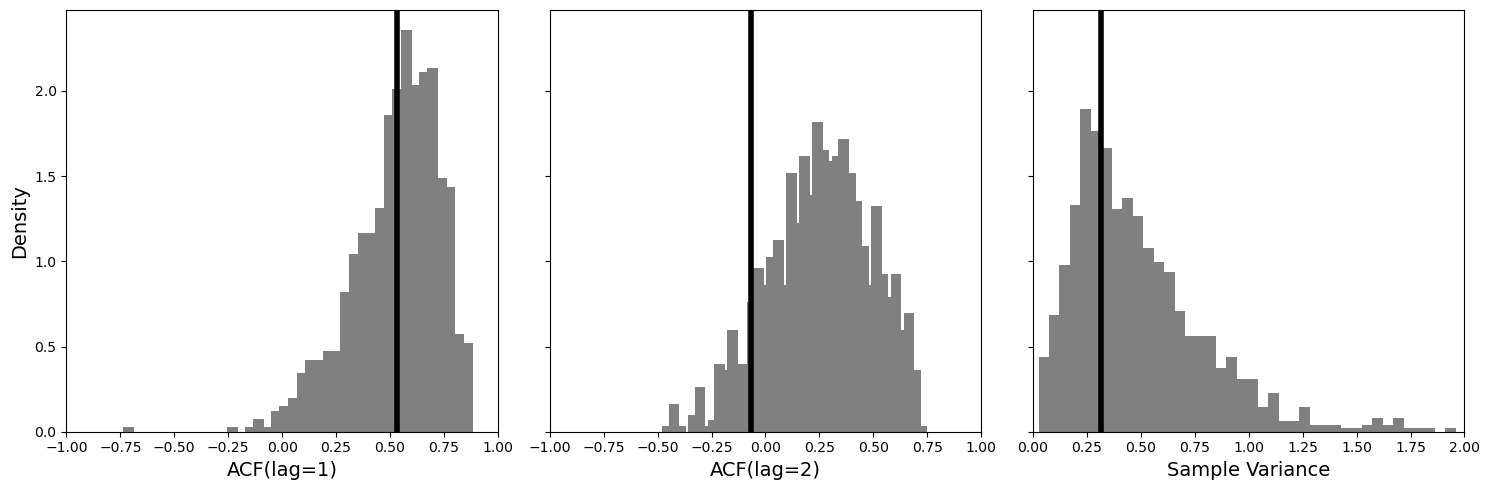

In [119]:
j = 3
t = 250
h = 20

bins = 40

y_true = eeg_dat[j, t+1:t+h+1]

acf1 = np.loadtxt(f'eeg_results/sncorm_acf1s_{t}.csv', delimiter=',')[j, :]
acf2 = np.loadtxt(f'eeg_results/sncorm_acf2s_{t}.csv', delimiter=',')[j, :]
variance = np.loadtxt(f'eeg_results/sncorm_variances_{t}.csv', delimiter=',')[j, :]

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
axs[0].hist(acf1, bins=bins, color='grey', width=0.05, density=True)
axs[0].set_xlabel('ACF(lag=1)', fontsize=14)
axs[0].set_ylabel('Density', fontsize=14)
axs[1].hist(acf2, bins=bins, color='grey', width=0.05, density=True)
axs[1].set_xlabel('ACF(lag=2)', fontsize=14)
axs[2].hist(variance[variance < 2], bins=bins, color='grey', width=0.05, density=True)
axs[2].set_xlabel('Sample Variance', fontsize=14)

axs[0].axvline(x=acf_lag(y_true, 1), color='black', linewidth=4)
axs[1].axvline(x=acf_lag(y_true, 2), color='black', linewidth=4)
axs[2].axvline(x=np.var(y_true), color='black', linewidth=4)

axs[0].set_xlim(-1, 1)
axs[1].set_xlim(-1, 1)
axs[2].set_xlim(0, 2)

print(np.mean(acf1 < acf_lag(y_true, 1)))
print(np.mean(acf2 < acf_lag(y_true, 2)))
print(np.mean(variance < np.var(y_true)))

fig.tight_layout()
fig.savefig("images/eeg_hppc_plots.pdf", bbox_inches='tight', format='pdf')
plt.show()

## Comparison of Models with Log Predictive Scores

1276
fox -1.1537006658872997
netcp -105.6466985515317
bh -129.4799065228308
globalccp -120.98613430767
nonglobalccp -121.99216427896681
sticky_ihmm -99.00414826893666
ihmm -147.8713643372639
npcp -112.15918852412415


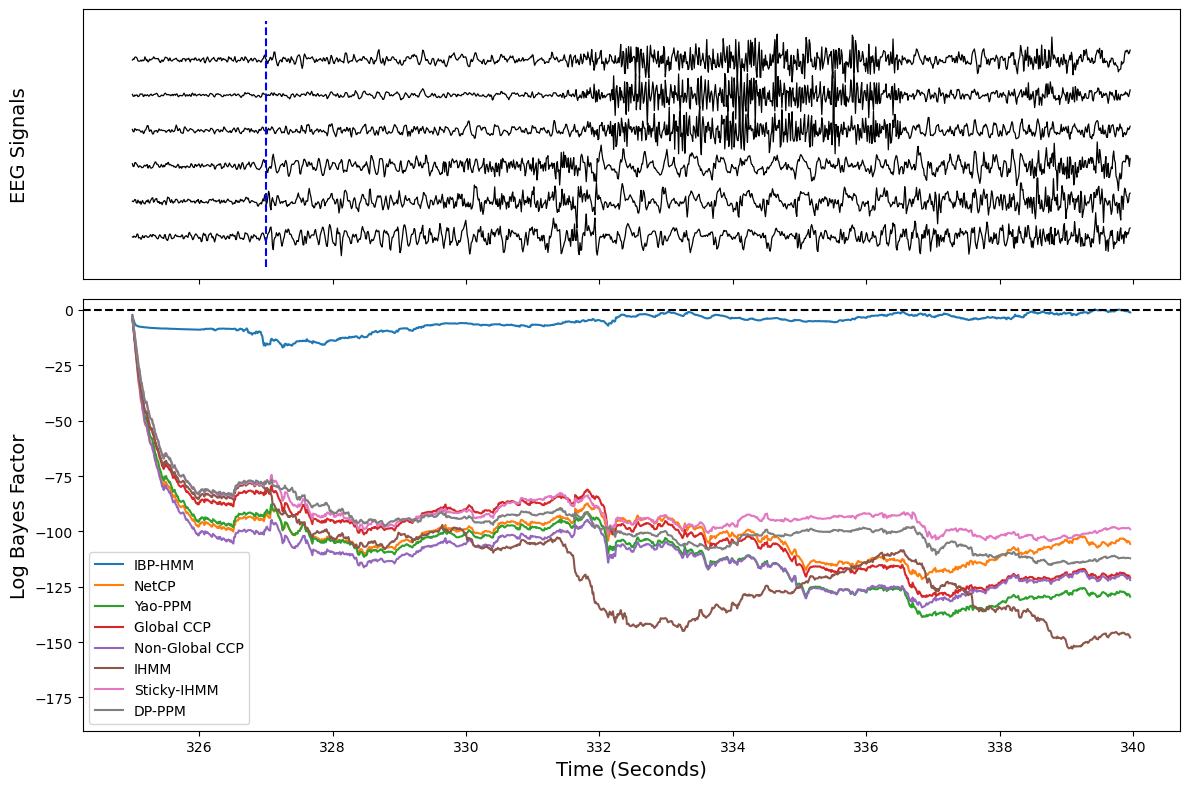

In [22]:
# maybe plot all to show the variation?

# Obtained from KCL CREATE computing cluster
sncorm = [-2.0059383237816832, -3.960193193372561, -5.822905310338022, -6.233017198023169, -6.559063177458159, -6.7957670051453105, -6.671286448041206, -5.708360252651067, -4.386532415260623, -5.700859665664723, -4.596387910581636, -2.993672543908362, -4.5232231453577505, -2.9905388555724803, -3.902429283002153, -1.5794535003603731, -1.1249950741167665, -1.906112636819366, -4.39196693548476, -3.059176204482479, -1.7449849036190996, -1.5435554052116438, 0.18740963611707273, 0.019557687790783235, -1.1655868199541737, -2.27520747900192, -0.5328536132872446, -0.7691773934638834, 0.46794097685255165, 2.145577578827924, 2.211318501790601, 4.224036470177527, 4.531506463935002, 4.1311647090105765, 6.334890330911377, 8.134910585702555, 8.922936034624687, 10.328410280157044, 12.734904836541602, 12.659352283020928, 13.594025025750256, 9.21500187609615, 10.131752502202739, 6.383674908362838, 7.087588918033677, 7.714596296089077, 7.625840489375348, 9.068560078953796, 8.570963234434146, 10.912624799409985, 12.316368530891584, 14.740613579012736, 17.430968131579256, 16.2793537208879, 14.282899470414096, 17.028322524581107, 17.655484805168406, 19.48834782927488, 18.861864409929137, 22.09729838879134, 23.432246822559645, 23.56355574733107, 24.250835749612968, 24.0405072338456, 22.379760237425607, 23.017024660737878, 23.728276950193177, 26.256235107289715, 29.21522040547659, 31.00151664507195, 29.94217506830716, 30.04541734207387, 31.260807717161544, 31.525123921508126, 33.32273622941142, 33.536459549344904, 35.916311192358044, 37.959998605331606, 35.99103884322268, 38.15154410962224, 40.0006239240231, 43.163682552863555, 45.12189387416708, 45.515232418477325, 47.66332510659609, 47.7220467424121, 45.04348738007692, 46.01338333177827, 45.04305343379585, 45.0105023491393, 45.167634294859596, 45.96122843932902, 48.92568158172387, 46.35579204162985, 46.278007781742126, 47.99039570690484, 48.20570061618081, 49.186519869142536, 49.385510062442485, 50.50025813302, 51.927783205124186, 54.26487599938146, 54.12910209420416, 47.69330478350253, 49.36616809778673, 49.77506730262918, 51.62289041999317, 53.19493379080727, 55.48203969695285, 57.43682038617635, 56.27769984392076, 58.960808234718755, 56.19475014142495, 58.104513362690476, 60.340389046540466, 59.88947249452837, 59.554775680910595, 60.42244743396227, 63.44290646586512, 64.42205555819706, 66.64051311194129, 64.72150873438855, 66.13274201922515, 66.64833426457878, 68.04101568494019, 70.55536786194595, 69.73717886440504, 72.28033869892296, 73.37078439825801, 73.45620951780627, 66.94501986374527, 66.49699688034724, 62.06513273322615, 61.93763566879506, 62.8184857341292, 63.16934681024332, 59.428715009024835, 59.36066847533328, 58.76991360967849, 60.43875375005114, 61.79583812308675, 60.43792906038808, 54.4784088174626, 54.01490879385205, 54.92693846026753, 56.85076074428737, 55.32213754914299, 53.97754543500745, 51.305925036858504, 52.850421146848056, 53.463019658424294, 53.198507087999154, 55.418361447145514, 56.28510893135403, 57.799053047127266, 59.82544185277262, 61.70194986292903, 60.313388935086365, 56.393484956207345, 57.30029488698198, 56.70387869458179, 58.050618486824774, 59.4818288505655, 59.39177393762461, 55.569582495386655, 53.31961831510482, 51.0698343791019, 43.613885579010024, 43.3963860700809, 39.057687088142195, 32.41966882795696, 24.89904227966358, 21.53178244902912, 21.20994637924683, 15.30960507713377, 11.831372211564693, 7.527106298197504, -5.06595617927376, -10.241074094354392, -19.284976725414353, -23.63566749697838, -26.464955256234862, -30.292127132997166, -33.83936814559268, -35.80633136342035, -37.80575727471631, -38.887922559901604, -39.093224965190394, -41.86931260149706, -44.792192261959464, -46.51151200692869, -46.309199931994414, -45.43231136973577, -50.139218643930924, -53.75549840563052, -57.95483688404957, -62.39912197452002, -68.95519274107865, -70.80946398667969, -75.88015347156909, -75.6828529943724, -78.63938378572725, -78.54664964834566, -79.4037732906759, -79.00854035313398, -82.7390546320252, -84.11133958477203, -85.85883339570209, -86.81837876607703, -90.17632414807439, -92.53554837799128, -93.98713247567373, -99.91113652477952, -101.35462365327061, -111.08551848773048, -115.55947621775053, -120.1632473828249, -125.62334747934386, -130.3373910104234, -132.02569357471137, -135.1499662878708, -141.60271102430818, -143.8917088437937, -152.2941101352096, -154.89820580859197, -157.16959266724893, -158.1498540815116, -162.2852769210916, -165.17400223512064, -166.97243592750783, -167.0517270010624, -171.45884992979506, -172.80575436131036, -173.50491760212546, -175.61233895331225, -177.3646085148539, -180.71792757652162, -180.94133991395557, -184.48420224756754, -185.5420565437635, -187.93521316174193, -189.97396583776276, -192.29763565959402, -191.7800568897354, -195.15658995189034, -195.79011630838792, -200.55543646736245, -208.14348193340203, -211.34126919344035, -223.0342595633597, -227.025250021422, -230.89629424462174, -236.72823855381682, -239.17638366559174, -242.7001250232223, -244.87730288540715, -245.8966872597942, -248.33474734726946, -250.19061023230714, -255.10087996478407, -258.7002624668443, -263.23624246747977, -271.438537331651, -272.73690873140055, -280.9502488093029, -289.20500850787874, -291.91943398795433, -297.2278077509803, -300.716123060763, -306.62115306388415, -312.6162160777144, -314.7923976209066, -317.31868517137383, -321.1276778739825, -325.69319474809396, -327.5955081956912, -328.80263597171046, -335.4193124536471, -337.99890084075076, -341.21635267996794, -343.3766572657052, -347.04573409252293, -348.0171544153378, -354.4257842515022, -358.22845073594715, -360.63847071684444, -362.7116439455115, -367.0226307385055, -368.81584726873155, -369.68743235722184, -371.1399348992524, -375.23129990476554, -379.33897289719897, -383.1875658080674, -384.8184827521786, -386.66926000987155, -387.80593871814614, -391.6078659370289, -394.78221543688875, -395.94076246040004, -399.18459462013027, -409.54592958897507, -416.7979245935653, -423.2312610048283, -425.30767513375014, -426.30766002340164, -431.9861754163601, -436.4826077961617, -439.33752998118547, -442.28033210073784, -446.1563655691829, -452.1061700730316, -456.41656093176925, -460.97240776242626, -466.9718278712629, -472.2832770843221, -474.7448286009125, -478.8726286074344, -485.567541207388, -491.6690126032164, -498.78742224906966, -502.1234247625371, -508.2871971712568, -511.9403813500463, -514.465335294512, -516.630500315605, -518.5319764413772, -526.9900803065874, -529.5816576632924, -531.1948425870135, -533.1250093166128, -534.06423607977, -536.3864352778317, -538.5184677976317, -539.7858313376087, -540.6301270423116, -544.1846889129301, -547.831985062394, -551.6314385992187, -558.7972213601187, -568.3272120538425, -576.5408325993895, -580.0146297065661, -584.9899668746508, -588.5454524455943, -593.0082987563702, -596.5013450150625, -599.1586141779579, -601.5372782612094, -604.9618046605801, -611.0167714659316, -614.6942165424199, -615.3809702051427, -618.2815905003512, -619.7754967985661, -622.8288730155751, -624.0465019755153, -625.3864777958404, -630.1028197948577, -632.1909872972378, -637.0232111691624, -640.3603245079466, -642.750842857276, -647.522549443767, -651.1064096404451, -653.8679175819221, -658.6797946445138, -660.9781188280891, -667.996726341316, -677.9128271070315, -685.7759648393609, -687.5851472096809, -689.0777892402012, -697.5815036795051, -699.8994755440535, -701.9094358002067, -703.9368391250226, -711.3189964923047, -714.662970795551, -716.9373377904711, -717.9571268839996, -719.7385638144248, -724.3318844840558, -725.1435787420777, -730.9117365511871, -733.5654079479872, -737.030737533345, -739.1510510707951, -742.3716458722574, -743.6569625081294, -747.2357327395632, -753.6644441258976, -754.6923090830443, -756.4036191580763, -759.5107054279196, -766.0128489428814, -771.7477351625889, -779.1377140313319, -786.2082376826849, -790.1640401767106, -797.226634539082, -801.2993135045314, -803.3878200091183, -808.6406345135204, -814.2015667759413, -816.9785555642895, -820.0650465911216, -821.91428476077, -825.5092950728761, -830.5693643383412, -832.1175754573594, -834.8544002033134, -838.2378087487019, -840.5284059840507, -844.3121061377839, -846.2596636429855, -850.424362002334, -852.6728851372295, -854.4430847005508, -858.9458246599877, -864.0944108124622, -866.8098376542014, -870.9857611034165, -875.8940776533549, -879.9088313022548, -881.4937766221012, -887.3097092767747, -894.7419564726866, -902.4863021421623, -908.1058307883735, -912.3550272762383, -916.6511992026059, -919.5033264929523, -920.8039497081244, -926.1222636807813, -935.1250453162296, -939.1109678539981, -943.7250516484218, -947.3520536188198, -951.5823828662435, -954.5922728894366, -956.8764975710986, -959.0997448201618, -962.7638106933927, -966.4365097588776, -968.983091832381, -974.2883935327035, -978.7987809506717, -985.2371327804801, -988.0542470134646, -991.8241543270215, -994.0819859638283, -996.4303490621007, -1000.7726858629064, -1003.1404496819255, -1007.243009900419, -1011.0892545286489, -1017.0058862235351, -1024.9685967791277, -1026.9450053116927, -1032.7434424810306, -1043.663096350868, -1050.763372624522, -1053.1448039745555, -1057.4490772894364, -1060.7304909714392, -1062.7416759126131, -1069.237215586117, -1078.002806036322, -1085.4421067868846, -1089.7962147986273, -1094.1706939870644, -1101.550113473289, -1104.222958223162, -1106.4518004106312, -1107.9009365997535, -1111.789311440276, -1116.611048104023, -1119.348428768438, -1127.8192537739267, -1130.458261704762, -1133.5090226616428, -1135.7172343771313, -1141.3157491404359, -1144.6065748831177, -1147.6445802034593, -1150.10111399668, -1152.4512509708325, -1154.7713882053665, -1157.3698125503226, -1158.90144718381, -1160.9472218680194, -1162.8668533458674, -1165.9325232227413, -1167.2485082459632, -1171.8471497899886, -1180.513539287767, -1185.7520530753443, -1188.853092532645, -1190.8863912207157, -1197.6751020377521, -1199.5410722536458, -1202.1054858546504, -1206.3494563488284, -1210.1327431903865, -1212.153938465708, -1214.639211582637, -1218.0745564082729, -1222.441150735917, -1233.6147437728018, -1238.3516983069571, -1251.5551470187147, -1257.810613570655, -1259.3972631214588, -1262.2485297498042, -1269.673747628633, -1272.7763281906969, -1278.917527847294, -1281.0458991628882, -1283.2149328634578, -1285.6876042700417, -1288.4153052899635, -1292.6759429537426, -1295.953825959191, -1297.1682633265648, -1301.76529670633, -1305.3638931411174, -1310.781304902778, -1312.7817356536427, -1319.954956300547, -1323.5919228522703, -1329.0262271953513, -1331.6571052664872, -1333.6742783617003, -1341.366818154214, -1345.8233873169856, -1358.1112906009187, -1363.2260754774818, -1370.8511251483726, -1378.1054876498767, -1383.641671418972, -1388.2480453291455, -1392.0420631013828, -1395.3974289771058, -1403.9729559787522, -1409.3284957611884, -1420.3668779168709, -1426.5978440819058, -1431.6381141811316, -1438.8717464253857, -1448.5700686711027, -1454.1763388469449, -1459.3396289402558, -1462.0602842530254, -1471.5387537745335, -1477.9240375075215, -1485.8408349745093, -1492.92331275637, -1498.4177423351812, -1505.9728534081105, -1513.4136867364618, -1519.5748346399223, -1525.9113674639702, -1536.9158501418763, -1543.9553213196325, -1556.3159073774361, -1569.6137974490885, -1577.8242930151243, -1589.199719966909, -1597.4000643507716, -1601.9675245796084, -1612.5513536562355, -1618.6974670072138, -1627.0134882651723, -1632.0317374716742, -1640.1093218104154, -1646.3595622678413, -1653.1667665785185, -1664.9864916979338, -1672.7373267459718, -1684.5711216074321, -1691.3009315580214, -1695.928220571628, -1705.9607968287294, -1711.9858057499293, -1722.11603080429, -1730.473331261643, -1735.3310326158398, -1752.8248467501858, -1762.905644437693, -1776.1012453969197, -1789.136335348339, -1799.6848048744152, -1808.0254137690172, -1814.9879072165265, -1823.5927738222126, -1831.9772034156833, -1840.2786805716141, -1846.860439725884, -1851.8865689331315, -1856.9364446605755, -1865.2217883080486, -1870.7313305365174, -1875.5887693201469, -1878.3336323756225, -1882.342777701791, -1884.3710927629959, -1885.6164224270792, -1887.5654323755523, -1897.3594289545288, -1903.479722823486, -1909.59204061452, -1914.3632240633779, -1932.9364873839409, -1938.19445198604, -1949.5090431190845, -1958.370834473214, -1965.321253024161, -1978.6901245414344, -1985.385748683767, -1994.4318381270223, -2001.8542547099285, -2016.5876347453302, -2027.80743547604, -2039.7539956118, -2051.626177922379, -2058.6968828118243, -2070.8389952283956, -2079.3149073306918, -2091.0636032316056, -2099.887009132093, -2107.51686883485, -2116.2945440632357, -2122.4085559774244, -2129.1600599273456, -2136.321698932429, -2142.144900279994, -2146.821724374891, -2152.0155339892804, -2158.491331542529, -2164.002693625714, -2176.5472449193635, -2185.3054020054137, -2191.2135516658086, -2202.953106751378, -2212.2465037850943, -2222.9745646997562, -2233.577777017813, -2242.723425755374, -2254.321023879722, -2262.6201383243197, -2273.224071627297, -2281.018488450039, -2288.1025013089434, -2301.112241607065, -2308.800055812196, -2322.1525432984135, -2329.8653588057505, -2339.376663739845, -2345.3449314265886, -2351.9358269714635, -2358.1658279344933, -2363.59618067041, -2369.996166992476, -2375.906656343736, -2387.2836620205703, -2392.4650927531097, -2398.9261834007366, -2405.6840542301816, -2415.9891124838823, -2424.057985440884, -2432.827680193516, -2441.4122211817253, -2448.4221498384672, -2456.3251308374115, -2470.9548223896504, -2477.7999315619822, -2485.655029739594, -2495.6681290537645, -2505.6964250121814, -2514.3669325665687, -2523.5986058761687, -2529.976798177173, -2538.038010601707, -2550.058819356689, -2556.087923467626, -2563.292943924015, -2569.175751395096, -2574.6868313817577, -2581.3243610699374, -2591.4759356928525, -2600.579252932085, -2606.8712011434823, -2612.94886430705, -2618.639098969161, -2624.96082468159, -2637.62081660585, -2645.4686482657125, -2656.2046462206836, -2661.4932033734594, -2667.0849767831246, -2676.407224610833, -2682.332291116783, -2689.3865831353414, -2698.855546578783, -2709.7573432712784, -2723.2143475631983, -2734.4411922370837, -2744.249244163139, -2752.7001160485233, -2767.5616246236427, -2779.3281141883654, -2786.5705397285024, -2794.792611091213, -2801.6965436859714, -2807.6815213186774, -2813.347256845697, -2818.475119454891, -2826.230388284186, -2833.539781504232, -2840.4990532603997, -2849.305857049344, -2857.888821521434, -2868.6661439468076, -2877.037022796736, -2888.2501029621285, -2894.179344166056, -2903.3709511095767, -2909.1922915202263, -2914.6195314876427, -2921.8537817420624, -2926.5439946985634, -2934.7296133417635, -2939.489680986349, -2947.2370761893717, -2952.549204489318, -2958.409802190555, -2965.3616964174034, -2973.355250430408, -2984.6244692217037, -2998.1068344998066, -3012.1268606910976, -3019.1776252794484, -3028.881149477538, -3039.8774680624556, -3050.056029505669, -3059.0943343747194, -3066.0029830526637, -3072.771098135812, -3080.887302891147, -3088.6891863165024, -3096.0681283243166, -3102.5721399760887, -3112.535910583782, -3121.57538644768, -3131.5726485596892, -3139.1378615335293, -3147.589529191065, -3154.972247577198, -3167.3978204191276, -3175.2891393528594, -3182.6145487247195, -3188.3725329296917, -3193.6313815369294, -3203.3465903121973, -3210.5897637835005, -3221.923012853702, -3230.0511684663625, -3235.5813220562623, -3246.860931881477, -3254.61770716956, -3267.03496515171, -3279.881922752977, -3288.5622527117725, -3309.5189700448227, -3319.2954725856043, -3333.7522591967186, -3342.442396055116, -3358.8640850270676, -3366.7906622265714, -3376.721860190676, -3384.797918730572, -3393.511072062887, -3400.154756841542, -3411.688575047767, -3424.0108444876996, -3431.1803983911536, -3438.425188464963, -3446.850303968178, -3455.509412168154, -3462.620964357453, -3469.3952207443385, -3476.925470909997, -3485.0783474299906, -3497.260402812879, -3504.0799457696285, -3512.4272189869685, -3517.9886793210944, -3523.6750355191525, -3531.036762035754, -3537.477323880392, -3546.780727358734, -3554.4519492835857, -3560.4687685624367, -3569.5455575419883, -3578.925809987882, -3588.8120353923105, -3596.383363515751, -3607.58090905983, -3617.0476770530636, -3623.7302109409366, -3630.494905377078, -3643.027248474845, -3652.233776124493, -3658.718698001206, -3666.7770685887235, -3675.760831312651, -3683.516634733411, -3691.0521315478763, -3702.6294536773794, -3719.126906728015, -3726.407399552285, -3738.7804930103043, -3746.339604984465, -3752.6610469055513, -3759.6217884902035, -3767.8963963524216, -3774.6918502593167, -3783.4751662697254, -3788.659073393204, -3797.3589942238546, -3803.453187198051, -3808.8480705325755, -3818.1542689343987, -3826.117243734798, -3832.5148436145646, -3839.2611520385153, -3846.777893512911, -3854.229653814357, -3859.5313147644556, -3865.5852293484368, -3875.305449125319, -3882.1791218690037, -3888.28859547731, -3897.1249201294518, -3906.37189232864, -3920.848017051507, -3930.733749168855, -3945.851974258647, -3954.3640804110146, -3962.5171236659903, -3972.3092594861037, -3983.515384308769, -3991.2069425964346, -3999.0844658637357, -4005.9001890572713, -4012.3705090960157, -4021.3260832263018, -4027.1579797936847, -4035.6949166141376, -4042.2326958029416, -4048.828117861156, -4058.648204044948, -4069.2848777458767, -4079.4372729111137, -4091.067970036805, -4103.753230759797, -4113.450523991128, -4120.661164324464, -4129.345274337237, -4137.26624708382, -4145.136248031903, -4155.033560688411, -4166.814718602011, -4173.843558485836, -4182.274207075852, -4188.649430035309, -4196.579948290676, -4204.391873061481, -4214.757513540831, -4221.561701911708, -4228.368101684387, -4235.768251815435, -4242.893747767599, -4251.194785769519, -4258.282198955961, -4263.981543293732, -4272.421525475257, -4278.11485477521, -4285.333398364858, -4291.4744354209615, -4299.6694545376, -4308.663579301135, -4318.9245163832375, -4335.388690462893, -4341.9754933169115, -4353.859288279229, -4360.831759161693, -4367.903599301486, -4373.895708056051, -4382.416557924971, -4392.51872571081, -4402.82165554514, -4413.988236239155, -4421.8260693568855, -4429.166712843455, -4439.579224310477, -4449.198110531173, -4460.718211679893, -4472.023107231359, -4479.450466551919, -4486.393724663943, -4492.539044601148, -4499.10531167312, -4505.791124121364, -4512.512914488638, -4519.631334010424, -4528.899583195366, -4538.1885393768525, -4548.377442239555, -4559.221251980168, -4564.681469644077, -4573.877897249, -4582.584950339248, -4590.8000113655, -4599.350921642848, -4606.792271467999, -4617.162807021955, -4623.935594440527, -4631.562801861796, -4638.680775829153, -4649.409904778641, -4655.885910109258, -4662.184476069578, -4668.0713968344635, -4676.994582773165, -4683.2627551637925, -4690.099167002706, -4697.605057508727, -4709.480349799995, -4721.263389886005, -4729.001997005579, -4736.021248250325, -4744.48624755301, -4754.60750810413, -4763.57625222785, -4772.681089094392, -4779.567444982368, -4793.437546898938, -4805.812002693765, -4814.092863687665, -4820.728997680917, -4828.208922213907, -4834.759429713052, -4842.981419190617, -4850.321652668025, -4856.167840074679, -4862.4637775415, -4871.062815479955, -4879.199447781574, -4886.259126555735, -4896.245604489402, -4905.99668001555, -4911.693402470896, -4920.650621159772, -4928.278288627834, -4934.387019843938, -4944.25834034818, -4951.548856439536, -4957.87907181729, -4973.574648605575, -4979.5062455231955, -4992.327016526557, -5002.30562641169, -5014.093430925383, -5022.122992404237, -5030.417278072192, -5037.806858581007, -5046.3504470837825, -5053.320951552378, -5059.346833646333, -5064.935877715519, -5070.532943494546, -5081.253233973956, -5088.06121631878, -5101.029529021357, -5107.661631793852, -5115.383635789187, -5122.36511942008, -5127.465195949974, -5134.928277480123, -5141.981924802214, -5144.713066061579, -5148.3345560623275, -5154.403329391026, -5159.946471148923, -5163.963038336633, -5171.987913110999, -5178.949800446687, -5182.221481234254, -5195.336938513744, -5205.46135706709, -5210.895991416705, -5217.296037924263, -5225.336096720881, -5232.9475324611585, -5238.074965089375, -5243.147071613559, -5246.777957669196, -5249.283577360582, -5256.826480759726, -5262.063435894206, -5271.257283030455, -5277.224378919879, -5286.875950447352, -5295.9539739138945, -5300.785109127821, -5309.426704085446, -5319.898127441457, -5324.859891146128, -5330.862715977606, -5336.828376335033, -5342.406317661338, -5348.094181512272, -5355.849893868878, -5360.491047772746, -5373.1654454571435, -5383.426322494556, -5388.716342380604, -5399.398765965551, -5404.405651797673, -5409.922518286109, -5414.696708487937, -5418.291129033566, -5422.907057887023, -5428.472407998455, -5434.710356374286, -5442.85817115358, -5447.990672432235, -5452.490393106526, -5456.750258747248, -5460.967740905231, -5464.815020722967, -5472.576556831443, -5476.840572900792, -5480.913128574348, -5486.623573191878, -5491.368179023481, -5495.781952291956, -5503.754982767208, -5507.202102628779, -5512.404382807131, -5522.506331054536, -5529.212174590292, -5535.128116166829, -5538.834968163866, -5546.382949953913, -5550.581262668248, -5554.984210635736, -5561.491788093041, -5569.042771502036, -5577.234185134584, -5582.954615418213, -5588.867945538796, -5592.5791360436715, -5596.191539759575, -5603.964272601241, -5612.571494444318, -5618.353625562385, -5622.016845067052, -5629.9755659812345, -5639.219016493997, -5645.486529711414, -5653.371996442139, -5664.966507304116, -5673.811059385137, -5679.2670533067785, -5686.021006538127, -5698.395784266832, -5703.365287214572, -5710.501434795492, -5716.981376562702, -5722.192975095048, -5729.981528487313, -5734.975799411091, -5741.862008485653, -5752.806856917341, -5756.774799692281, -5762.483859065308, -5766.523499556461, -5773.996663368979, -5779.343641708042, -5789.009343038341, -5798.8112528207885, -5802.640144048482, -5808.860247217187, -5813.613570603889, -5817.875250381197, -5826.709650581213, -5832.808401942546, -5836.805732323054, -5841.705571600629, -5847.1564226217615, -5852.305406607343, -5858.846742573336, -5867.001875845852, -5872.552786171939, -5880.441848151227, -5886.077186304822, -5891.811917797622, -5898.705967429549, -5905.611575016474, -5911.481083912074, -5915.294552007533, -5921.965245051064, -5931.277383403181, -5938.821712731239, -5944.42037872001, -5954.54774009044, -5961.621447243561, -5966.1531718195665, -5972.989443996927, -5982.4407622608605, -5988.06415624148, -5997.074277838276, -6007.863871302843, -6015.090745659238, -6025.787625127053, -6037.706408277179, -6043.989889611388, -6050.515796473863, -6057.532121858174, -6066.57429030896, -6082.6784337463005, -6089.225400553512, -6096.114412589677, -6102.626477040236, -6112.623025504078, -6117.579559051184, -6125.266017220441, -6134.473013191167, -6141.0966577674535, -6150.547858968893, -6164.586471829022, -6171.800418084973, -6179.98826076775, -6189.844126457362, -6198.0846959958835, -6206.788013967187, -6217.263426252857, -6223.977689267043, -6235.521575095984, -6242.968252021358, -6252.774400544507, -6270.64204711189, -6280.895707932994, -6292.282520705974, -6302.109884604923, -6312.476328676021, -6322.67357271295, -6333.91174938088, -6343.120101730283, -6352.604312003441, -6358.8738568677445, -6368.438402378996, -6378.61415282619, -6389.867880573375, -6397.551034845534, -6409.249161609779, -6418.776996048498, -6426.986013602448, -6439.393169917591, -6447.106970115311, -6460.615665315134, -6470.431299511911, -6481.719219160659, -6495.43275994504, -6503.586908522009, -6510.797732983499, -6517.746561330185, -6529.157255169372, -6537.4482215675525, -6544.380631284854, -6553.305334173126, -6560.059904953168, -6568.520051681456, -6577.642674259347, -6585.178124240538, -6594.2667780942575, -6602.607881606757, -6610.161988270513, -6619.522031229764, -6630.067072113644, -6639.038553077866, -6649.409276892343, -6658.253509945425, -6666.697712932014, -6673.079734270497, -6682.180323778514, -6688.299971758396, -6698.838250794682, -6707.332054661443, -6720.849373566571, -6730.037551353046, -6737.615700640473, -6744.92838067358, -6752.811086518962, -6758.850137554947, -6767.6927493006515, -6774.386724731273, -6784.212573694483, -6790.425692901854, -6799.749193013409, -6808.033743909757, -6815.621100529843, -6823.351344315469, -6831.270297337413, -6838.261868015059, -6843.701325072642, -6850.426275578265, -6856.084989089553, -6862.0764176373095, -6870.787699345445, -6877.5142003035935, -6884.61682149179, -6892.874647212335, -6899.125955602842, -6906.7968063901735, -6914.699157244664, -6926.762290392902, -6935.053412322933, -6946.256143527039, -6954.767762284523, -6962.018438951269, -6971.619690850345, -6979.967584403319, -6986.114090026539, -6994.740953005201, -7003.932491250214, -7016.63106510842, -7023.892273384534, -7029.788136885052, -7038.2930063267795, -7045.396107613678, -7051.243807803986, -7063.107079708759, -7070.179266332976, -7077.236898437724, -7084.123734066454, -7091.338140872369, -7096.732449450571, -7104.989742950548, -7113.4436890794, -7119.922334340805, -7125.9782094172415, -7133.406657170994, -7141.944537881107, -7151.565125778741, -7162.495606599808, -7168.06500854246, -7176.965866212026, -7185.473435858651, -7193.7625855232645, -7199.371386963187, -7206.378440062053, -7212.334359874917, -7220.44880497932, -7227.010675317642, -7232.660950201276, -7237.6795289613265, -7243.244996627157, -7247.194280267947, -7253.97181462788, -7261.830038090538, -7267.95255026024, -7272.269688435012, -7279.084554644532]
fox = [-4.345729561220881, -7.966050236480001, -10.947649863316636, -12.374138499824818, -13.292993393274841, -13.840628491891747, -13.890901084479736, -13.084104755928742, -11.886334417081514, -13.253304516375104, -12.221328657454567, -10.663157841829204, -12.235388994074622, -10.75931332280574, -11.713786279433238, -9.427417171411232, -9.010997288377462, -9.796765861055967, -12.300825430839504, -11.026803686950945, -9.7631190560993, -9.59229122665391, -7.898961739831577, -8.099942821116823, -9.302329632860264, -10.43289513479553, -8.71516409481111, -8.970475756815725, -7.74613619090664, -6.087827650055552, -6.0461304466290775, -4.056380144091366, -3.762078422855158, -4.178471640815682, -2.009085004510004, -0.2299673338301076, 0.5434255561584383, 1.9405172084309799, 4.319979213191367, 4.2303184460045, 5.1511893374914255, 0.785337889713456, 1.685897261390103, -1.9806469417740304, -1.3435138800044641, -0.7562303412455711, -0.8618652018850342, 0.5579492301508334, 0.048621594201080476, 2.3675457387444774, 3.7555604431648977, 6.174298544001635, 8.853333666325799, 7.692569900521608, 5.733252079318902, 8.433538805399278, 9.03972070079126, 10.855173496574881, 10.215065773587646, 13.430021254484261, 14.754931922879637, 14.871786997500823, 15.547981954053963, 15.33259121695586, 13.677772773578031, 14.305049427536503, 14.992024357984562, 17.50266552956001, 20.44741177394247, 22.227007334109622, 21.17394775840579, 21.271468363650367, 22.465412227224743, 22.719373465212506, 24.505125690606782, 24.711300682323163, 27.075412796966646, 29.103902480370195, 27.12681808480196, 29.27370858560706, 31.11245096783562, 34.267279357559744, 36.2114956509356, 36.6013473306651, 38.73720597811255, 38.786806166312616, 36.137067561694046, 37.06149970557248, 36.230561182182825, 36.244287550039395, 36.379698032378464, 37.14455513369943, 40.08473114029725, 37.815484430355525, 37.710165140384845, 39.4210447104967, 39.639362639415594, 40.63856234307764, 40.81804614920739, 42.009086738871886, 43.432226117904, 45.77372832265522, 45.629448713630275, 38.83904584211334, 40.621078615466075, 40.65082554457592, 42.36330984917988, 44.19514255333806, 46.69740524031233, 48.74659420950839, 47.764345651212494, 50.42030179440348, 47.750172416484936, 49.63375918696004, 51.834101925092, 51.429856865753294, 51.11310001313168, 51.973074022126674, 54.93098990010775, 55.89602897080995, 58.06697949584738, 56.22822709236389, 57.61696407149675, 58.09778128875452, 59.47707882159961, 61.93454314601077, 61.17009870342641, 63.65527579792447, 64.73644244564225, 64.85100809260418, 58.438689486563334, 58.03042218958307, 53.40277281495474, 52.659183257420764, 53.81052757141724, 53.960014443079984, 50.46574237026276, 50.775529095207524, 50.25928808218852, 51.82579254274918, 53.16741447354533, 51.426205911863256, 44.86071150033922, 44.783903865985344, 45.91648096327488, 47.97407004441504, 46.95662517173263, 45.12566125050483, 41.06781124353557, 42.793837470213276, 43.06149681022126, 42.5998901523141, 44.92623537485663, 45.10092785543679, 47.11426652093697, 49.3510887849439, 51.33460019945241, 49.630924254685176, 46.601917379680785, 47.427282472392925, 46.22845581359325, 47.9990326164823, 49.77065044247938, 49.5445747564014, 45.588691730953, 42.00471736849464, 39.188801701714794, 29.238128596670933, 27.310918312157714, 24.046149056751222, 16.263903321767, 9.359315863379232, 6.38919105915112, 5.599885917690942, -0.3251858058382373, -3.6396910721831346, -8.005320838918623, -18.390471635646062, -23.27044539169142, -32.77475638591112, -37.41360391904993, -40.42436125899442, -43.902863040461035, -47.18923182497809, -49.37369609044305, -51.50073136922104, -53.030809557120975, -53.60876320454116, -56.667083178127754, -60.16346648628124, -62.02043257304469, -62.46325159387232, -62.43495979387578, -66.23168976484196, -70.34247280535362, -73.24268516780495, -77.71498827626492, -84.68852188025222, -86.83361293914848, -91.35492368103809, -91.4235070424336, -94.30661826817355, -94.4098599689233, -95.44170088295247, -95.16367031080341, -98.2114164079681, -99.35038765210018, -101.03165516054526, -101.89172378493032, -104.65073628510228, -106.72551708643302, -108.18576973401005, -114.05388936961353, -115.58026225957603, -125.11781891759297, -129.51405812484987, -134.3117369184913, -139.7420649155898, -144.20767644686987, -146.0630296835398, -149.19288551335276, -155.4604472209768, -158.0609437200117, -165.5580817094488, -168.69771330815072, -171.2036794735551, -172.51960032683448, -176.57238176535228, -179.5324954677273, -181.5568681628103, -182.16721786063607, -185.55766087909208, -187.12437552456126, -188.0674949824064, -190.1704806017672, -192.13062315386694, -195.55814861616724, -195.847500218732, -199.38507123191548, -200.6851147800099, -203.2548628924405, -205.55952821189274, -207.80366275987507, -207.52852794156323, -210.72628210048154, -211.53481579800865, -216.1789970125358, -223.04768474402084, -226.08833630788263, -237.22139129635718, -241.32717029828498, -244.94850635850094, -250.45682269914772, -252.93965432702427, -256.3712549936918, -258.6187171039909, -259.7313582001646, -262.1131378270202, -264.1567434624126, -269.0218703497215, -272.6538408452305, -276.9490283042643, -284.6996774964244, -286.14837920135864, -294.0351946151448, -301.92048570960407, -304.9994122933539, -309.98732556702237, -313.3871810596017, -319.1712714261097, -325.2280598409154, -327.5769511075727, -329.7834677401718, -333.7422874069704, -338.3487861057991, -340.34526217151443, -341.51815991409853, -347.5212950054461, -350.4608842540338, -353.5602896289319, -355.8305652015358, -359.2471176356215, -360.3580833405223, -366.5152147401534, -370.44371681355676, -372.6190987329204, -374.6316741320554, -379.0558679817559, -381.25250920960485, -382.35150937476334, -384.0022153744161, -387.65608640457276, -391.4774332096855, -394.8325678683044, -396.6407957963869, -398.873487907732, -400.2127436871994, -403.92850132928595, -407.04000797907014, -408.23471331084676, -411.3743916584311, -421.13094980270967, -428.0664955117492, -434.0280801172683, -436.2940203330499, -437.406004587376, -442.1413498219275, -446.57231525343536, -449.4438935338224, -452.1629462506026, -455.9386606163577, -461.57243521448765, -466.228477439666, -471.1341441025402, -476.96866479587374, -482.056836237573, -484.5046613087567, -488.2970928143836, -494.8909129372529, -501.1064449230354, -508.68779992081693, -511.72347244037536, -517.9077373309037, -521.455635783059, -523.9288877418396, -526.0678512971269, -527.8844328202867, -536.5430957699509, -539.2829284556146, -540.9198088223035, -542.7918312845359, -543.8254392785556, -546.1486801168943, -548.6012096060389, -550.012501449975, -551.137535896681, -554.222632759183, -557.5714404115411, -560.9594310312185, -568.62094752625, -577.6571874106603, -585.1470865423453, -588.5762431099595, -593.4802641477089, -596.9597554674247, -601.3960441955097, -604.8235186232984, -607.5224278603602, -609.8419927349378, -613.3387541787964, -619.3663783902769, -623.0011224885618, -623.9977366421243, -627.1353299825995, -629.0470902254076, -631.9044986477912, -633.3405435373509, -634.7512211589589, -639.6090827137767, -641.3538522466124, -645.6107365541707, -649.0124179939309, -651.4045979832268, -655.609461988557, -659.2251250127603, -662.1319727486723, -666.4227995816885, -668.7912688868681, -675.8272665330247, -686.0562724059538, -693.356268458639, -695.2088991907835, -696.8518373271711, -704.7146304976155, -706.9760134299883, -708.9206272507091, -710.8446669939282, -718.1754999232861, -721.6525090080611, -723.8227662033206, -724.9404433212845, -726.8169226404774, -731.1248920325713, -732.1139798572037, -737.6189873043439, -740.3330239170937, -743.5906548576403, -745.7288718499502, -748.8437752884118, -750.2442966285919, -753.6998478364319, -760.324034215555, -761.4977562456628, -763.2005932533425, -765.9229225140259, -772.368561968659, -778.0741928124625, -785.3192216287406, -792.3537010682456, -796.3462924495014, -803.2694914532474, -807.3283431754858, -809.4327117287189, -814.7160153203674, -820.3777360938036, -823.0989408157807, -826.1922358470393, -828.0394653117164, -831.6620001796988, -836.7358620743332, -838.2874406377831, -840.9435377123161, -844.2780459557023, -846.7150724135994, -850.5392566643774, -852.4673769309305, -856.6488895756871, -858.7918021456654, -860.4660425463179, -864.8297483295623, -870.0896567250302, -872.7647744762165, -876.9163076295949, -881.8938651211038, -885.9145378870417, -887.5374402537403, -893.212789344052, -900.7711967680725, -908.6341739381788, -914.2588102579729, -918.5543950703176, -922.876603475219, -925.7370237281601, -927.0523870595665, -932.3546772747345, -941.6949908843675, -945.731402913592, -950.2952526999388, -953.9373458322075, -958.1670430526116, -961.1532827881888, -963.4125402627727, -965.6330542560522, -969.4484328534506, -973.3044494832053, -975.9289049086667, -981.3428228937044, -985.5322262827417, -991.961635192393, -994.8381552184258, -998.6149571210992, -1000.8547845216664, -1003.1712635619803, -1007.5903034321642, -1010.0373764287073, -1014.1254726010898, -1018.2122607535599, -1024.0880929983416, -1031.6256724929235, -1033.7317814644948, -1039.3510999059697, -1050.2073332013867, -1057.288330107231, -1059.6530143345851, -1063.960288717722, -1067.2238085391557, -1069.261700187296, -1075.7939157680955, -1084.5015211064344, -1091.8434123086756, -1096.3271325550127, -1100.96347015001, -1108.3950060058366, -1111.0777364523346, -1113.3504956566544, -1114.944062551863, -1118.8509834542351, -1123.4222790888987, -1126.153059824153, -1134.4771662532225, -1137.288800805787, -1140.329908914274, -1142.5665471641773, -1148.1147440202624, -1151.225708036979, -1154.4382917976386, -1156.9930614180569, -1159.362505566368, -1161.8350051738728, -1164.424061880522, -1166.1769240969438, -1168.1546632767672, -1170.2702853663827, -1173.077949484393, -1174.66958448555, -1179.4526680813242, -1187.4309237604225, -1192.6876613597005, -1195.8113880011567, -1197.8821767118018, -1204.646767251715, -1206.5961743566147, -1209.3949822741702, -1213.6763848039323, -1217.5224004834015, -1219.747277510535, -1222.3785617677045, -1225.7156530182147, -1230.2525689035901, -1240.5812483826478, -1245.3263692862504, -1258.1778385418168, -1264.5495160055748, -1266.1299448114091, -1268.9369356395553, -1276.318721366652, -1279.5424216837134, -1285.6028168338185, -1287.7862859497604, -1290.0436542251641, -1292.531275650205, -1295.3064107290868, -1299.5643297142371, -1302.9769826091017, -1304.411230437195, -1308.9673769113099, -1312.812257630466, -1317.655750163455, -1319.7589249227215, -1327.070128902983, -1330.733631403504, -1336.0252362839979, -1338.689300113585, -1340.7459715160462, -1348.2783043765216, -1352.6910786578435, -1364.9952690066536, -1370.0809781288067, -1377.5080493930436, -1384.85849308392, -1390.187856107889, -1394.6814560796292, -1398.4117691188303, -1401.7179653542728, -1410.0470455772875, -1415.5527459172872, -1426.6402821839954, -1432.8998911321535, -1437.9399840309975, -1445.0394383565351, -1454.2217321874366, -1459.9413006529403, -1464.992391978914, -1467.714738846103, -1476.7631894511173, -1483.26913761514, -1491.202464720533, -1498.0985946098408, -1503.6356094647524, -1511.2491861385797, -1518.872588249158, -1525.1162341744737, -1531.4552172657236, -1542.416259974238, -1549.554992199918, -1562.02985777397, -1575.2965402753998, -1582.8205523487884, -1594.6639003333996, -1602.6056729798822, -1607.1364158564813, -1618.1625271149894, -1624.2673350865873, -1632.2298611918038, -1637.140454849173, -1644.8924496397922, -1651.0323723026997, -1657.8988209133831, -1670.149576852243, -1677.866715065117, -1689.5669675913475, -1696.2480804352265, -1700.747330950061, -1710.4157154090326, -1716.5720054919434, -1726.6914200117594, -1735.100520879571, -1739.994890906167, -1756.9539000119805, -1767.0933951167826, -1780.4952235407493, -1794.088128388293, -1804.712139921243, -1812.8112065655607, -1819.6081137779722, -1828.2306608123158, -1836.5603084723082, -1844.9778007828509, -1851.6877445297273, -1856.9487472210265, -1862.0573083952513, -1870.2651992167177, -1875.757540618553, -1880.852837571544, -1884.115064516425, -1888.3157395273727, -1890.7630856237568, -1892.4157823997261, -1894.7078104431116, -1903.4560860230708, -1909.522134294142, -1915.5846218296015, -1920.5286072202498, -1938.1006286147137, -1942.9955116914884, -1954.4547776395168, -1963.7185794969714, -1970.2614275630672, -1982.1310326376647, -1989.0484994367212, -1997.7121447810678, -2005.087032445603, -2019.4955815449266, -2030.6452989414806, -2042.1482972115987, -2053.7503284312475, -2060.8793884143606, -2073.0646687698936, -2081.5433867157108, -2093.3712422826, -2102.518728595772, -2110.2288633007306, -2119.2867195787644, -2125.3336886141738, -2131.9154926645847, -2139.1721215909392, -2145.150470752407, -2149.9297629967887, -2155.13097059238, -2161.463918229358, -2166.9707270025347, -2179.494445961025, -2188.3456040438073, -2194.282537210279, -2205.8656654186725, -2214.7158829829723, -2225.511700347641, -2235.7615213192253, -2244.738985458612, -2256.313173315432, -2264.651903309513, -2275.2166961687462, -2282.9923254764685, -2290.0680060297773, -2303.0515827933514, -2310.675085872481, -2324.1912354756673, -2331.861630192657, -2341.5247508666034, -2347.5692243958674, -2354.291305515787, -2360.6426866747925, -2366.1658140593067, -2372.669993973555, -2378.7484968780177, -2390.1366525797266, -2395.644707213218, -2402.039378828498, -2408.9348018933515, -2418.5414798808033, -2426.8436439642355, -2435.37881142977, -2443.6280717619293, -2450.538945399932, -2458.4153274836867, -2472.425761192951, -2479.2623545089505, -2487.1473336733493, -2497.1106995829177, -2507.4891685844714, -2516.0544990793155, -2525.190214309846, -2531.5435354005317, -2539.324262037407, -2550.917969102793, -2557.029760725823, -2564.3283650331505, -2570.270713757014, -2575.9405321561735, -2582.6905533875206, -2592.779102171736, -2601.8430379040906, -2608.173070686597, -2614.42286074876, -2620.2467792724533, -2626.7234695828465, -2639.511495634357, -2647.477050273785, -2658.3226134986735, -2663.733230063145, -2669.4334594416064, -2678.9520082660747, -2684.990748693558, -2692.125677689945, -2701.6721581201155, -2712.090330041719, -2725.2001071550008, -2736.021651309471, -2745.797722772163, -2754.398805539963, -2768.565599156866, -2780.264919620242, -2787.60585142265, -2795.8961972205807, -2802.948095902207, -2809.0102550264864, -2814.882298372629, -2820.309177650363, -2828.204311675596, -2835.7741045504254, -2842.7328948840723, -2851.5442665857418, -2860.2346346631607, -2871.171395228307, -2879.543133464608, -2890.961627244709, -2896.9781868657747, -2906.2555159213925, -2912.2189496577384, -2917.7637558450137, -2925.243142591518, -2930.0487969846863, -2938.3746755175844, -2943.2764194387755, -2951.0329872793964, -2956.338096188992, -2962.235977740507, -2969.0167777068255, -2976.9728335338013, -2988.115797667367, -3001.2374940489212, -3014.795302323735, -3021.8433886782364, -3031.5317781785525, -3042.1737630718144, -3052.3142990869455, -3061.311076688919, -3068.255848189164, -3075.0871367021123, -3083.266700006853, -3091.033036455112, -3098.5936153774446, -3105.1848557922053, -3115.115565376777, -3124.133966045627, -3134.3014864157703, -3141.940460364253, -3150.459334830656, -3157.952199504365, -3170.4426564624787, -3178.4956385846995, -3186.0124278182034, -3191.9640033557853, -3197.3766810769025, -3207.229561613498, -3214.5203679209358, -3225.421593645699, -3233.723542939532, -3239.3010425547564, -3250.6288376646066, -3258.2545196324377, -3270.711769950006, -3283.6049568850985, -3292.22796335478, -3313.1933270636555, -3322.8038235626113, -3337.45350563169, -3346.0726048520737, -3362.863805226049, -3370.8399505756893, -3380.926349387611, -3388.963328736401, -3397.960078851127, -3404.591568210389, -3416.2056342265832, -3428.513131430678, -3435.6141387040907, -3442.9487573618567, -3450.9925892667093, -3459.5969003078253, -3466.53439009568, -3473.3485670081545, -3481.0096061849604, -3488.9808555989835, -3501.5081611262895, -3508.4568378079716, -3516.861100683204, -3522.5371349839024, -3528.2938081226275, -3535.738033974229, -3542.2600415276374, -3551.44232466349, -3559.1575385079673, -3565.1923618658093, -3574.078794186008, -3583.243744045981, -3593.049676460331, -3600.64148847858, -3611.6197052316365, -3621.074584705702, -3627.68613510947, -3634.2966640967625, -3647.091454968647, -3656.2348179582123, -3662.638782477804, -3670.7253636197943, -3679.733261049591, -3687.4099196917423, -3694.8799925936773, -3706.4292520152458, -3722.9605143429985, -3730.129567607957, -3742.483188058424, -3750.021555539431, -3756.3954536850238, -3763.392172894, -3771.8007200795573, -3778.807737798889, -3787.648360110955, -3793.0324582193575, -3801.552464747604, -3807.816204433743, -3813.336931164693, -3822.4898977348103, -3830.3871105668877, -3836.962851187903, -3843.7819046123423, -3851.4961452645393, -3859.009350045416, -3864.409789058443, -3870.5882566219443, -3880.390269317158, -3887.252235512724, -3893.357491113937, -3901.9874833909553, -3911.3344709271673, -3925.364994574619, -3935.2222675824087, -3950.5684553331857, -3958.982809013556, -3967.131780358874, -3976.8742560136243, -3988.101514781522, -3995.8431019077557, -4003.8540848425073, -4010.8006867818463, -4017.4208503488217, -4026.4956562986877, -4032.401785258831, -4040.9375171496667, -4047.5339318041565, -4054.2105493548784, -4063.8858910504237, -4074.426998007688, -4084.4882334788317, -4096.096331433355, -4108.765797186746, -4118.559864360088, -4125.801954876721, -4134.539597851427, -4142.452807174302, -4150.266735665778, -4160.020702873338, -4171.868617521744, -4178.974983370576, -4187.337501551421, -4193.712046098222, -4201.702155970757, -4209.33343527605, -4219.855061355444, -4226.684421015111, -4233.5425690579395, -4240.933131846025, -4247.985720235988, -4256.286407413957, -4263.454236754355, -4269.2513131649785, -4277.466903071074, -4283.294408836584, -4290.498840331904, -4296.7497728965345, -4304.8237774641175, -4313.870560492792, -4324.370578011837, -4340.740843182763, -4347.384092148729, -4359.394906021319, -4366.4165026399605, -4373.360221768691, -4379.418688653291, -4387.9487362868895, -4397.9171530429085, -4407.934520654076, -4418.781660826606, -4426.520250133552, -4433.895617559565, -4444.2468964973905, -4454.081462821322, -4465.7531910689495, -4476.743351067682, -4484.14383989628, -4491.0320716442575, -4497.079023427317, -4503.682072937486, -4510.2143475567655, -4516.956792549319, -4524.072014843669, -4533.532726896278, -4542.851083618129, -4552.688616551212, -4563.192074338108, -4568.757826372381, -4577.956340024556, -4586.894556735273, -4594.634411479082, -4602.946475776819, -4610.378924899917, -4620.342229524164, -4627.107368598476, -4634.8340188571365, -4641.952988024517, -4652.831385746963, -4659.369076839209, -4665.581586103121, -4671.43865763703, -4680.399783592139, -4686.708609036368, -4693.683795949394, -4701.216476114533, -4712.615819501751, -4724.296330892292, -4731.975513848413, -4739.057844552057, -4747.577048048563, -4757.283622548087, -4766.286601967465, -4775.315113698889, -4782.261686394257, -4796.106496764133, -4808.391073013847, -4816.662290259745, -4823.302076513103, -4830.802368656699, -4837.377515808332, -4845.415389310187, -4852.6776858000785, -4858.507654887859, -4864.788257824939, -4873.194982508795, -4881.512586149659, -4888.873308690554, -4898.557693358325, -4908.571659547574, -4914.238413035204, -4923.449729096001, -4930.548201031992, -4936.672570092323, -4946.355387973228, -4953.473286858588, -4959.844635324781, -4975.688426205012, -4981.621033464808, -4994.104437734941, -5003.755038203282, -5015.614608983601, -5023.62783644401, -5031.858581089942, -5039.207584575082, -5047.567829761457, -5054.564561681417, -5060.6929365102915, -5066.49735395332, -5072.150169196415, -5082.374585121112, -5088.980456066491, -5102.050262340177, -5108.725914322096, -5116.850362693574, -5124.009294330296, -5129.330720507529, -5136.926883997959, -5144.03894051545, -5147.084281815503, -5150.792818859017, -5156.786227348169, -5162.258229644504, -5166.151671309123, -5174.53691040143, -5181.568096354978, -5184.988186074422, -5197.696659984635, -5207.903011220082, -5213.510859907619, -5219.767229486333, -5227.354664364096, -5234.911699315829, -5239.83818072979, -5244.7821207685365, -5248.53215413283, -5251.036858092501, -5259.054811213374, -5264.256284305727, -5273.188951214046, -5279.105975657293, -5289.174196352239, -5298.5884975363, -5303.64748662326, -5311.903749883789, -5322.071256338929, -5327.123151205303, -5333.363924323945, -5339.8046380474125, -5345.449631263909, -5351.203405237048, -5359.012323446441, -5363.825515085967, -5376.0428255876395, -5386.421340958185, -5391.547044981801, -5401.885133585369, -5407.038074938702, -5412.297246361285, -5417.009891198516, -5420.488405106747, -5425.23924346901, -5430.803640497409, -5436.731875213984, -5444.464458943181, -5449.884433407748, -5454.242388335571, -5458.653060629112, -5462.936194854494, -5466.759628517162, -5474.832160442401, -5479.1137933437185, -5483.4208034168505, -5489.392303436088, -5494.275647322683, -5498.748498157933, -5506.555425883469, -5510.115927655838, -5515.590800341018, -5525.659379820401, -5532.594198719675, -5538.551325502928, -5542.317178082589, -5549.753464010367, -5554.068856364029, -5558.519485793391, -5565.399877215117, -5572.845384960497, -5580.954977000015, -5586.94867490876, -5592.810800141646, -5596.740977631837, -5600.52724673803, -5608.164202781867, -5616.826323591694, -5622.930445626551, -5626.633635292156, -5634.413812780029, -5643.644694083056, -5649.628487656877, -5657.705390775943, -5669.293919864624, -5677.614397880367, -5683.200273697196, -5690.013415793893, -5702.152680145744, -5707.3115130805645, -5714.744669078455, -5721.24253510004, -5726.236129460114, -5734.030833649918, -5739.045535175578, -5745.747456271712, -5756.567375103465, -5760.639265974586, -5766.173947930186, -5770.256983881003, -5777.692555399277, -5782.915609307954, -5792.290931273576, -5801.9458731681425, -5805.9526268473655, -5812.347247302479, -5817.133615799514, -5821.37452005659, -5830.18465295507, -5836.029041626154, -5840.088669823571, -5845.121402277579, -5850.730449749939, -5855.754162613355, -5862.698718169199, -5870.852550677318, -5876.125284904211, -5883.988882594792, -5889.782733850625, -5895.626848825332, -5902.480160545157, -5909.203020654389, -5914.995030442996, -5918.842355674336, -5925.389152204191, -5935.012092005581, -5942.396996824185, -5948.683201480922, -5958.310836507208, -5965.061105357129, -5969.753004899991, -5976.885022835527, -5986.446246131983, -5992.287762479866, -6000.858130584157, -6011.2964286349425, -6018.441723694866, -6028.7327557345325, -6039.829811980375, -6046.628504756547, -6053.3354046412605, -6060.386668283856, -6069.17190171598, -6085.685750454402, -6092.120285232932, -6099.219945317313, -6105.902881352786, -6115.851804814717, -6121.001355098607, -6128.5369739495345, -6136.734769722222, -6143.575763702214, -6152.806543308285, -6166.126827128623, -6173.291319793805, -6181.395652837635, -6191.052412655083, -6199.090763654158, -6207.707430960813, -6217.9977904817615, -6224.818605716089, -6236.655381620889, -6244.20551089579, -6253.693044716458, -6271.924879473293, -6282.254232301449, -6293.8075628410215, -6303.791077061123, -6313.907962230812, -6324.077867698891, -6335.342797061905, -6344.159151473689, -6353.509092740053, -6359.874354147476, -6369.056592593233, -6379.562956145395, -6391.066915996454, -6398.925563699075, -6410.81042400848, -6420.187636732668, -6428.371457541504, -6441.074941748224, -6448.8577399981405, -6461.630171888605, -6471.810655476138, -6483.046802119875, -6496.975922666651, -6505.417864712744, -6512.800240663195, -6519.628746635798, -6531.1239984883, -6539.030939668678, -6546.117212482924, -6555.491014573595, -6562.2803495103235, -6570.419873390694, -6579.326394199017, -6587.225193308338, -6596.174992605103, -6604.1572704674945, -6611.498781688272, -6620.682025120879, -6631.735640845366, -6640.765009208862, -6650.960107871988, -6659.783516208973, -6668.152118383689, -6674.5213373304505, -6683.519804066862, -6689.708024947101, -6701.107038497904, -6709.775344692512, -6722.668480026859, -6732.0903790412085, -6739.593685958765, -6747.069780602289, -6755.11310796377, -6761.154163792018, -6769.470437768035, -6776.199836946692, -6785.7285820384195, -6791.933658608889, -6801.051771264366, -6809.3000701847, -6817.065185198184, -6824.4516555226555, -6832.288300679163, -6839.367308791291, -6844.7854973888, -6851.564950157546, -6857.264042534582, -6863.73221585023, -6872.140128288437, -6878.836219760523, -6885.4029804665415, -6893.624461013938, -6899.88401643645, -6907.149281326408, -6914.938386362846, -6926.892552328152, -6934.7969821193965, -6946.301891213631, -6954.815996593751, -6962.114404118952, -6971.897098319877, -6980.076030686496, -6986.2350425088025, -6994.864021301237, -7004.111145036805, -7016.695954986137, -7023.953991688601, -7029.930914335333, -7038.438257282454, -7045.657543565798, -7051.592425214468, -7063.581436978442, -7070.929704857501, -7078.25145822899, -7084.787458552638, -7091.948142609518, -7097.546880578794, -7105.450599790247, -7114.11050570608, -7120.412945576929, -7126.649101068554, -7134.115733145432, -7142.372691499726, -7151.542638433709, -7162.582644370862, -7168.121426131715, -7176.78114373171, -7185.409012351777, -7193.650053538223, -7199.494492681914, -7206.5997588513455, -7212.542560956125, -7220.666186402761, -7227.384511844915, -7233.137572124081, -7238.27411902653, -7243.720566117445, -7247.804089553219, -7254.409028395189, -7262.719579830765, -7268.737153752745, -7273.423389100899, -7279.731855525594]

netcp = [-5.547969177743043, -11.027662148639159, -16.423978306069298, -21.096910335855657, -25.396384184969712, -29.299868746877802, -32.62542540308154, -35.43598020186038, -37.722790375739066, -40.77366544879027, -42.93721930108923, -44.42779920030686, -46.86349863004818, -48.514503606164304, -50.57553172033342, -51.277562241183475, -52.50647685581362, -54.2143217381606, -56.451297009064916, -57.183623783623545, -57.74038165928345, -58.602904161949425, -59.05178995073973, -60.19906741138912, -61.95742305278546, -63.22395944083344, -63.403612561073125, -64.46381407988811, -65.00299631215354, -65.37605037884475, -65.91781814455895, -65.72838030202993, -66.1229841082065, -67.25129609904208, -66.95852201292472, -66.48074244480654, -66.57856477742608, -66.41403387330735, -65.6023395046854, -65.89763716894923, -66.21987894064279, -68.66666355752875, -68.71162745121634, -71.23137899403832, -71.61162089863706, -71.58630409065327, -71.9404878544453, -71.40030539057831, -71.5855211314856, -70.5088750088767, -69.85446865663319, -68.60882238039677, -67.13645583318899, -67.8519120193888, -69.3926357658374, -68.08805592575924, -67.8973859806031, -67.10141600166774, -67.76994276736546, -65.91679504639191, -65.06198830548611, -65.23362277319694, -64.86101837931339, -64.77787279822672, -66.18743578628597, -65.44681835988472, -65.3694870169484, -63.75107152385695, -61.83218613330289, -60.69753768396992, -61.40316643627194, -61.72803268369602, -61.20768652439594, -61.17898245626758, -60.03460998601992, -60.29029351637068, -58.69759492794088, -57.19697015127044, -58.54377075959269, -57.16080443023217, -55.923950194376225, -53.71237573748572, -52.22403936084383, -51.66106350996204, -50.22943972804774, -50.034786190333186, -51.49147297328245, -50.67458719336085, -50.879669829357404, -50.807842312609516, -50.73969780087796, -50.41460434342804, -48.22582869128543, -49.410920861848076, -49.622444684450244, -48.46035381117888, -47.84374216229705, -47.25805213825552, -47.36604611843915, -46.5561475452947, -45.35521335287748, -43.58165689102001, -43.71962898612786, -48.858374962908464, -47.56113588431258, -47.36173599598387, -45.89778407709263, -44.53625383111936, -42.777313740706624, -41.06811556479459, -41.42586537190611, -39.48925259549901, -41.32537155882749, -40.1390323159229, -38.59921890298215, -38.603506079805804, -38.534353221117485, -37.69606295038932, -35.29566172919498, -34.47205223582158, -32.75576012383108, -33.87999488227278, -32.753151533263846, -31.746460838813277, -30.689368704989302, -28.72076515297566, -28.941158738913053, -27.08917158938452, -26.308989282116972, -26.586443834413316, -30.166770274320267, -30.653130953686745, -33.265272972005874, -33.3931427078133, -32.195348954564075, -31.83766751730972, -34.45480857260235, -34.87137760169299, -35.2586855531967, -33.72253687125369, -32.354060308506774, -33.66892743028567, -39.139578795744654, -39.309727937887864, -38.736558700031374, -37.51170443879055, -38.67781321908061, -39.81760381574108, -42.100386281438944, -40.575437112330185, -39.87743175185988, -40.172244520739454, -38.22666013902627, -37.580295389481506, -35.9924754711252, -34.432274022437376, -33.29980473864177, -34.5059031337694, -37.11047343646639, -36.56848059591344, -37.123040436717346, -36.41351314566255, -35.47756097292914, -35.39464547260183, -38.59631026073968, -41.45795404687527, -43.64584531536042, -50.77765706223833, -52.05714754984268, -54.67192737740427, -60.80140879041945, -67.14621099924958, -70.35207682239941, -71.85457247079948, -78.17390795201709, -82.13281294334537, -86.39709209855054, -94.75400060453448, -99.49658055144681, -109.53502222248784, -114.32246996623786, -117.54229874502245, -120.74643128815394, -124.11751177091229, -126.60794204787958, -129.27315692257503, -131.27362463532103, -132.55427692042494, -135.8434008685648, -139.58796218010602, -142.1079771784217, -143.50699210395095, -144.89940112153735, -148.32730804843172, -152.50837457498187, -153.96973305752823, -158.60993267238572, -165.34878096899575, -167.88871630211057, -173.57075098370922, -174.37751713170394, -177.74027198753743, -178.4872272007377, -179.86576373178855, -180.24912005030873, -184.15212385131673, -185.69909413543235, -187.193125166363, -188.55601554970386, -190.88068368817227, -193.20232724542052, -194.82158319745866, -199.67422164628525, -201.17686557097375, -210.36901245275797, -214.0697620794424, -218.1358399359562, -222.7718993187684, -226.44242817966975, -228.56184207691527, -231.24901669713017, -239.98819785780282, -243.63696853167335, -250.46375230368037, -254.04967091905945, -257.3875217396863, -259.2242932193038, -264.10095196986987, -267.56007935709, -270.5729252366009, -271.8144268528192, -273.5959112914395, -275.15405265949136, -276.0147407704774, -278.0826174437873, -280.1133145366283, -283.7469977228745, -284.4909435833218, -287.7027742834633, -289.2806941491809, -291.90872825834833, -294.2219325358283, -295.79466732465676, -296.09270280918804, -298.82033193261026, -300.0366135134038, -303.8264719848625, -312.28532551594077, -314.58671132835934, -325.4343645335357, -330.0117347446661, -333.92578981333696, -340.0302886890791, -342.9944312144504, -345.95295826612823, -348.25420425612106, -349.4841720207241, -352.038593392425, -354.92150961204504, -359.43768039847055, -363.46713087777465, -367.3929992900249, -375.3734301412542, -376.9094038601441, -384.8773144677647, -393.0575462565066, -396.96079784354765, -401.57484632522403, -404.54821063731606, -410.37100978324423, -416.9678597488652, -419.2475685118583, -421.602306215715, -425.07676162314533, -429.9212428528598, -431.9825773215306, -432.8222936610817, -439.6500277710838, -443.19371656674195, -445.9707680322235, -448.2204950557293, -451.63036493502136, -453.1305180419055, -460.4224002166082, -464.86856865112395, -466.80689264793386, -468.80283162798975, -474.678613120637, -477.8176270234032, -479.0811976851819, -480.4842883172194, -483.30525920687063, -487.4235010480448, -491.23382975016614, -493.59054795549014, -496.4326068059429, -498.1351912405775, -501.40273486210236, -504.43723083325716, -505.7488779390912, -508.0822325970042, -517.4548789799704, -524.2444601886491, -530.1454845770969, -533.1356543500824, -534.5607976534709, -539.0766117135429, -543.6675831801311, -546.483047671109, -549.0277170642374, -553.286570770415, -558.739896517844, -563.242428891369, -568.4684776907175, -574.1297324264629, -579.1820009815671, -581.4616608765867, -585.0615811851777, -591.8263189573249, -597.9364454261965, -605.962705545186, -609.5138877957273, -616.2355785316366, -619.5616137113263, -621.8942601528172, -623.97261428594, -625.7302390306793, -634.0746182191949, -636.8377161220814, -638.3582003783052, -640.0925158078217, -641.1046513623962, -643.4368001876439, -645.9354950595773, -647.4662049743444, -648.7534217159271, -651.5945308498519, -654.4426572427004, -657.5942553327548, -664.8052923961204, -674.2202379713711, -681.7375109327013, -684.9936292287343, -689.9163443089583, -692.9748949839044, -697.2104967057821, -700.6890050297887, -703.4997094119781, -705.5802075116187, -708.907211567627, -714.6700118307481, -718.3197513442016, -719.2772365357858, -722.3110840537489, -724.3513741154412, -727.1730539271239, -728.708939378815, -730.3307991237479, -735.0956499181395, -736.4583254136608, -740.8812490456676, -744.221634528933, -746.4074148423849, -750.1458207316492, -753.6854770549608, -756.8815351945485, -761.1104356740414, -763.4311216031999, -770.0796945979253, -780.0760960037509, -786.474062195986, -788.1674579703175, -790.2269321923814, -798.225167913302, -800.2224913639454, -802.2532189348346, -804.0709241014359, -811.418017247513, -814.8978780385181, -816.805472691698, -818.1477846177553, -820.0998184785186, -824.2087204880758, -825.3102089088494, -830.6538960956179, -833.1081788794781, -836.7406401936872, -838.7780112405478, -841.7003425060741, -843.1613517927374, -846.1985416794411, -852.3048381211091, -853.3781072771136, -854.937574769773, -857.5449067138454, -864.2970352600455, -869.7926603166362, -877.5721967405066, -884.0841063636467, -888.1791271544598, -894.249349235431, -900.2840010721656, -902.6372628076108, -907.2338796777209, -912.7358934236106, -915.9070153353177, -918.6382302792979, -920.963749357175, -924.6700557826914, -929.7504978508321, -931.4850965728896, -934.0614029781668, -937.774394813238, -940.1619225155072, -944.4565685080448, -946.2644146771868, -950.4097641543292, -952.5979229503267, -954.0804727378558, -958.3876813667952, -963.6889611168716, -966.3383967148923, -970.4167636026915, -975.0887896594656, -978.8465734175602, -980.6091391997369, -986.2966576535274, -993.6558240781524, -1001.114848574801, -1006.3537071753491, -1009.9986577861994, -1014.5739100111502, -1017.7364031396362, -1019.3547708038915, -1024.6811852215599, -1034.500021012143, -1039.25636414913, -1044.1680649301686, -1048.055200220089, -1052.398945043779, -1055.1192449673101, -1057.6437406220625, -1059.8215891336552, -1063.6725640775185, -1067.3861174443975, -1070.0823038000492, -1075.5448898613358, -1079.7080444546184, -1085.544356538138, -1088.6248583398672, -1091.7432623292254, -1093.9393365684543, -1096.2109851678829, -1100.8265875808174, -1103.1679800324075, -1107.2205302729726, -1111.1489875848642, -1117.2417453746546, -1125.5213478790097, -1127.6546206698033, -1133.560381027252, -1144.6033028629765, -1149.833984011209, -1152.4132413412683, -1156.0820397754683, -1159.0300662821228, -1161.1968799931426, -1166.9199767943333, -1174.4754031465595, -1182.060520843546, -1185.8721511525218, -1190.549149296488, -1197.6143036924275, -1200.1463925198884, -1202.5480788697469, -1204.4546433134608, -1208.4009472528658, -1212.8230461631695, -1215.3137105569983, -1223.330286048676, -1226.2154792385318, -1229.280683784181, -1231.5659988660102, -1237.1465995711017, -1239.9867855676987, -1243.1244570521576, -1245.5907829973635, -1247.9990286510244, -1250.515021096315, -1253.1323909094876, -1255.2537967645521, -1257.1764602239086, -1259.7806194385823, -1262.2495011758972, -1264.137331113876, -1268.7086410823758, -1275.8533016728027, -1280.4969518063785, -1283.7314160010135, -1286.079713150415, -1293.1570463325763, -1295.3035597349235, -1298.121288092628, -1302.2433718535747, -1306.6890456734106, -1309.0548645390968, -1311.7544452081577, -1314.794359280726, -1319.8843608863033, -1329.4532064475243, -1334.619417185943, -1347.1550917230563, -1353.803078411111, -1355.3894396500277, -1358.1511928887232, -1365.7185483927847, -1369.097871764534, -1375.145483472265, -1377.1264561915448, -1379.3796322642813, -1381.8774162724912, -1384.6663799352632, -1389.1349409697893, -1392.5577338650082, -1394.2564675799279, -1398.627688803889, -1402.4307766901738, -1406.9180660675077, -1409.2502643342214, -1416.3563571437242, -1419.9285741898505, -1424.92525924262, -1427.5315202978202, -1429.6108738433718, -1436.838211990708, -1440.8751408388614, -1452.919688348543, -1458.1203219907372, -1464.9440118946018, -1472.3462340017375, -1477.758961598251, -1482.0869092222504, -1485.491130170286, -1488.5502027497907, -1497.3076856513562, -1502.896900922272, -1513.2206911167145, -1519.6515292201818, -1525.9461279443005, -1532.345398336906, -1542.1908415348305, -1548.1052598592453, -1553.3094550240828, -1556.1173692078287, -1565.7728910438768, -1572.4459695357311, -1579.8129768500444, -1587.495742506679, -1593.1675496836963, -1601.0409119971084, -1609.08514032307, -1615.6988537956477, -1622.268416889397, -1632.582703751632, -1639.6295268639387, -1650.494956493768, -1659.3565926034578, -1669.0240630259295, -1679.6868418350437, -1688.6198080793574, -1693.5337682165637, -1703.0378449512768, -1709.5738711702816, -1717.1753778123052, -1722.745808410449, -1729.9598619732487, -1736.1965520948172, -1742.4406147509146, -1753.1580214821684, -1760.977144630222, -1772.1690161112995, -1778.7308581462669, -1783.3881524980363, -1794.4720656134423, -1800.6140461206485, -1811.2804683265579, -1819.8501291858788, -1825.4608394376346, -1842.73229716476, -1852.3921830672796, -1865.9216503949606, -1878.5952178195348, -1888.5048763735947, -1896.787052780331, -1904.260829318547, -1912.7622968095018, -1921.7254021738413, -1930.5521005047199, -1938.1274385366908, -1944.3515819520962, -1950.1601517733698, -1958.3940324248522, -1964.5257618407816, -1970.051969004269, -1974.6850871206498, -1979.660050780591, -1983.9804180348783, -1987.5493017919664, -1991.8020490610838, -1999.127142656572, -2003.7633835771956, -2009.6927262709567, -2015.576696979559, -2031.1511610550263, -2038.2187119163611, -2047.9306109830327, -2056.575330774836, -2064.511412307496, -2074.402317352832, -2080.714913212583, -2089.3748861453523, -2097.0129859264857, -2111.672701466055, -2123.0027805119958, -2134.976827568553, -2145.819593045609, -2153.4466403216793, -2164.7425046960516, -2173.5817988867902, -2185.6078058514354, -2194.6146341140466, -2202.906917315221, -2211.7719885427928, -2218.025945762612, -2224.3588983042505, -2231.5119762835348, -2237.541367022051, -2243.0883791084575, -2248.891106058979, -2255.090313360825, -2260.92229177271, -2272.7511794502107, -2280.5914081980786, -2286.436824516024, -2297.182195944379, -2305.2869285531747, -2315.8159233295605, -2327.3926174787357, -2337.0764507604226, -2349.308795515292, -2357.5231471224984, -2368.056112462039, -2375.5592096752275, -2382.5846218728193, -2395.5313484869584, -2403.2857098656496, -2416.1395357644496, -2424.0044897110192, -2433.321894271302, -2439.2353501780494, -2446.0777672557233, -2452.4451303417377, -2458.15972708033, -2464.807652071885, -2471.43113107155, -2482.180162024439, -2488.0654196142223, -2495.441158164748, -2502.015732331207, -2512.19084489688, -2520.0705331186523, -2527.8780416308696, -2535.264019825074, -2542.5084751666277, -2550.197704049272, -2565.659690017773, -2572.970007123466, -2580.94343810487, -2590.381688369138, -2599.8992022093, -2608.1521482945236, -2616.4676299686844, -2623.161403538145, -2631.4017986737113, -2643.803698872783, -2650.1146692042234, -2657.2661943009134, -2663.2981475647516, -2669.131511528895, -2675.6023676342793, -2685.687923975558, -2695.484242848151, -2701.7836683684072, -2708.609115814742, -2714.5105093370266, -2721.20811714915, -2733.6581586960933, -2741.433095546046, -2752.7116922480636, -2758.907655251617, -2764.787528335801, -2774.770665340013, -2781.393738040531, -2789.253903578194, -2798.2649423733415, -2808.137481797934, -2819.5925629732196, -2832.3316046072014, -2842.2854238113887, -2852.288890827889, -2866.325997385244, -2877.507692901835, -2884.581269026233, -2892.246010518278, -2898.933065227597, -2905.0904710242535, -2911.2321353994253, -2917.1491680268564, -2925.207955839454, -2932.709700983463, -2939.031448957443, -2947.8446118019665, -2956.2769814245676, -2967.1189030736637, -2975.295578650616, -2986.2219571076303, -2992.480945607533, -3001.2223704420207, -3007.493903452135, -3013.4818741099884, -3021.6439485677333, -3027.333354876445, -3037.020488273543, -3043.053299953032, -3051.4882405726316, -3057.2318112014054, -3063.580625205599, -3069.8992558263026, -3077.529667429319, -3086.6753161668803, -3101.357106609315, -3114.3269248808506, -3121.492509622076, -3131.2486156395516, -3142.0771420777196, -3153.169562766174, -3161.53453284862, -3167.8941031372988, -3174.5004361737942, -3182.354575479708, -3189.7347148189147, -3196.808806894418, -3203.2943186140533, -3213.4275539781, -3222.2247587356637, -3231.8116983719933, -3239.5752303553836, -3247.854277103808, -3255.4891728433704, -3267.3196871635723, -3275.158116114796, -3283.2736112846733, -3289.678442071786, -3296.0315826187207, -3305.641509909263, -3312.5685530080773, -3322.4633583602304, -3330.8734700177906, -3337.0359316858494, -3349.0466908693925, -3356.5385254938856, -3369.5067567630635, -3382.5618307190284, -3391.82396029781, -3411.1678330326376, -3420.900363358459, -3435.203621238027, -3443.9222943411214, -3460.6877228605003, -3468.4206424311988, -3477.843667489595, -3485.749628793653, -3494.1647393357503, -3500.553629395297, -3511.563551752758, -3523.6308612153766, -3530.479329237004, -3537.625336628981, -3546.450496236152, -3554.862919586324, -3562.4231466220867, -3569.771540921685, -3577.3276402021493, -3585.168923932492, -3597.7809127878613, -3604.904581568074, -3613.7002064159387, -3619.948014587992, -3626.1030433165656, -3634.3933758735884, -3642.06481668397, -3651.077257469189, -3659.176954878808, -3665.400200170626, -3673.8003439287395, -3681.9582730309485, -3692.236264959892, -3699.9422546391074, -3709.8279612143483, -3719.694952916647, -3726.2458522680686, -3732.3862856108526, -3746.9062914967203, -3755.883324148008, -3762.296053971058, -3770.7655242342653, -3779.5869151335114, -3786.6811397594884, -3793.6667290205087, -3804.9709588038, -3821.5150304809413, -3829.2025327658084, -3841.2127508402623, -3848.8577912025435, -3855.353695142204, -3862.485252939571, -3870.9952322139693, -3878.3469289113496, -3887.3114488080937, -3893.3888721953936, -3901.7146395665477, -3908.567177759292, -3914.803106536668, -3923.283384555263, -3930.85626142617, -3937.959141474399, -3945.3121000685196, -3953.3649525095652, -3961.4011279504725, -3967.6130446738957, -3974.353016903205, -3984.790929706291, -3992.1342052587906, -3998.775573605861, -4006.5736765667375, -4015.4726500784295, -4028.983046391013, -4038.9562420707703, -4054.9775014342918, -4065.339642868821, -4073.7558646626817, -4083.5089445316694, -4095.020740634609, -4103.393980679031, -4111.720594834007, -4118.9519150088845, -4126.017694627301, -4135.90291013505, -4142.706206304519, -4151.999469694951, -4159.511650906832, -4166.339957500691, -4174.707201684096, -4184.79180112537, -4194.4640356970785, -4205.723466889134, -4217.916358783677, -4227.111692323547, -4234.320173037662, -4242.648681626136, -4250.3379432796555, -4258.182671704707, -4268.392844756437, -4280.578734454844, -4287.737890022936, -4296.152838046354, -4302.564142526076, -4310.371454337941, -4318.178825155849, -4328.545819090528, -4335.707169396381, -4342.660417980151, -4350.050749999716, -4357.00122699321, -4365.522774651572, -4372.923126059172, -4378.983919248418, -4386.777128148204, -4392.896535163682, -4399.971927151565, -4406.474510698803, -4414.4962487900475, -4423.360117090824, -4434.328117000031, -4450.004788553627, -4457.025786441621, -4468.915956972274, -4476.142862975218, -4482.884620881507, -4489.351556778639, -4497.93506607015, -4507.394469264319, -4517.130249868431, -4527.582992071353, -4535.319414184515, -4542.770413256936, -4553.344414080483, -4562.8898580261275, -4575.41536488329, -4586.615306092946, -4593.673898215249, -4600.38299937615, -4606.58241348999, -4613.240562465373, -4619.767603083843, -4626.921673309368, -4634.077424671291, -4643.694594081105, -4653.869601684695, -4663.257700042414, -4673.737352060025, -4679.901818526969, -4689.610861636075, -4698.457976565551, -4706.30806372286, -4713.945128218083, -4721.333406258901, -4730.624669308944, -4737.307650366877, -4745.362446913932, -4752.616935292599, -4763.206693721756, -4770.14519897214, -4776.309822382026, -4782.280923674705, -4790.946785102046, -4797.387321876645, -4804.577067456984, -4812.321318483156, -4823.154090825861, -4834.212164371186, -4841.8704057314435, -4848.823226370299, -4857.358970572611, -4866.89076078456, -4875.9296467674285, -4884.581978356296, -4891.682688728257, -4905.686970396745, -4918.165124768712, -4926.50863359673, -4933.033476172074, -4940.213700497304, -4946.50972474614, -4954.50793071047, -4961.9248746204885, -4967.860529885648, -4974.3254215153365, -4982.554586444232, -4990.959071678668, -4998.918696891766, -5008.146695252421, -5018.634124072884, -5024.462313976119, -5034.303089674859, -5041.094850182843, -5047.455351481446, -5057.04787949613, -5064.046001593486, -5070.662438917854, -5086.032582018428, -5092.136445123546, -5105.280246665007, -5114.532781848386, -5127.110002236811, -5135.191547117387, -5143.495053330261, -5150.819409490564, -5159.436655088388, -5166.437008228838, -5172.644387518172, -5178.65949742643, -5184.5004854637855, -5194.055246175033, -5200.471952097892, -5214.225436663478, -5220.614308867316, -5229.577640734877, -5236.915626774725, -5242.270616085223, -5250.179166617858, -5257.4381928969915, -5262.025002671648, -5266.594188143916, -5273.420409519917, -5278.38982177992, -5283.294700736706, -5289.365515897706, -5296.676858049785, -5301.135074822817, -5313.24469067343, -5323.843632064818, -5330.28202767185, -5337.377664334862, -5345.701983509716, -5352.10505599353, -5357.328540507857, -5362.975054574723, -5367.330174464441, -5370.892477656877, -5378.025907186694, -5383.093419228419, -5392.129604632934, -5397.985699478144, -5406.627073628349, -5414.992352925392, -5420.494445133616, -5428.773086099435, -5438.537685134399, -5443.254475386216, -5449.1947070407605, -5455.206072299975, -5460.940021241463, -5465.768417482169, -5473.033103452076, -5477.763754098024, -5489.634476564776, -5501.696157999548, -5506.484047421393, -5517.295287262284, -5522.588069973333, -5527.841813671698, -5532.3400685513425, -5536.0615001232, -5540.72482074433, -5545.952661008074, -5553.0853238934005, -5559.968933050554, -5564.876947678956, -5569.696765112287, -5574.425724585401, -5578.793359282628, -5582.732424659169, -5590.1785172276395, -5594.967890339086, -5599.514527500888, -5605.021619645783, -5609.611487511763, -5614.116025342247, -5620.8071059480635, -5624.537040757257, -5629.789740606208, -5638.440299489693, -5645.2384472841695, -5652.165368053463, -5656.062197074309, -5662.374798448821, -5666.584210487171, -5671.521797942284, -5677.571896344101, -5684.384641488288, -5692.706448833581, -5698.201959393561, -5704.234746060231, -5708.399032515547, -5712.385843724434, -5718.434755197586, -5726.736067144517, -5732.847410421716, -5737.104313914236, -5743.553000129025, -5752.593175874478, -5758.705741957378, -5767.166876228065, -5779.914082513526, -5787.8832178822695, -5792.868325790345, -5799.5596157679665, -5812.353157528823, -5817.802239647262, -5824.623202739941, -5831.123148993271, -5836.106279048555, -5843.965475666694, -5849.236181757267, -5856.029332379626, -5867.290231447603, -5871.581986027081, -5877.107010787894, -5881.506484745772, -5889.350585515706, -5894.287053946526, -5902.417489257299, -5912.235579234323, -5916.353059371948, -5921.569776475211, -5926.469681546368, -5930.719634850873, -5939.498647455215, -5945.529726392957, -5949.61593018138, -5954.691183999814, -5960.1575153661415, -5965.285963383835, -5971.22479753088, -5979.655725873889, -5984.655213534384, -5991.907862006929, -5997.684515219428, -6003.113408350775, -6009.5999498521805, -6016.278913559984, -6021.668037861183, -6025.6812412423515, -6032.317771628434, -6041.71740862654, -6049.827557956735, -6054.702379090704, -6063.853639562744, -6070.046858058488, -6074.4236504159235, -6081.448507087933, -6090.989979978234, -6096.455873747648, -6104.895615277562, -6115.460007434321, -6122.179044989004, -6133.1180517281855, -6145.683216522456, -6152.424034646688, -6158.783974922479, -6165.656420974358, -6174.205569337016, -6192.3895508247915, -6199.339507173781, -6206.1425421419935, -6212.2446656612665, -6222.855018052691, -6227.679882744794, -6235.179077351536, -6244.301095539339, -6250.480544044419, -6259.64196092778, -6274.584131458968, -6281.305307590904, -6289.401073746301, -6298.681992174077, -6306.529916004558, -6315.360970986209, -6326.026732885523, -6332.877096999976, -6344.8129608454055, -6353.135084909983, -6362.4117029144745, -6380.004054573087, -6390.450529436198, -6401.631091092591, -6410.484876527829, -6420.4839084875985, -6430.647343627121, -6442.319423101054, -6450.897741977297, -6460.376397183315, -6466.940335833302, -6476.132944347998, -6485.540743468156, -6497.060296849316, -6504.869858270171, -6516.479944626456, -6525.7997461323675, -6534.017431205485, -6546.267033675065, -6554.149270397103, -6568.211199530475, -6578.342388505658, -6588.962398319671, -6601.9447389191555, -6609.906381718026, -6617.015462795893, -6623.872068790856, -6634.8899505134, -6643.279678801183, -6650.158924371719, -6659.1469775589585, -6666.302753268821, -6674.214609157202, -6682.976163152339, -6690.6917718856275, -6699.108301072751, -6707.777480621165, -6714.942531034392, -6723.82331589236, -6733.906059305742, -6743.181210235854, -6753.195193689821, -6762.739930454474, -6771.523076842878, -6778.349353522496, -6786.59508930232, -6793.1401199735365, -6803.431145293548, -6812.650832208694, -6824.4449833005565, -6833.543353051835, -6841.085877175278, -6848.359580258587, -6856.18068559746, -6862.49486544328, -6870.632742449083, -6877.509202570084, -6886.792949467977, -6892.953486134612, -6902.115522174702, -6910.445825095145, -6918.372213957169, -6925.819124035127, -6933.548585129119, -6940.739569742056, -6946.738832617237, -6953.92441469184, -6960.540665214146, -6967.250512701883, -6975.871794995324, -6983.697264518894, -6990.370256023627, -6997.85916282881, -7004.839661933894, -7011.69644847115, -7020.145959649879, -7032.542570718375, -7040.943907172702, -7052.504723306509, -7061.679686882185, -7069.336395963767, -7078.782464998399, -7086.461011212073, -7092.91851286549, -7101.041322118809, -7109.8792647995815, -7121.628600176173, -7128.675657753182, -7134.6490702239225, -7143.362430378955, -7150.783793481768, -7156.742523691463, -7169.116231863389, -7176.3599495089975, -7183.92032633793, -7189.881401359981, -7196.776753872246, -7202.7322066956585, -7209.876428889091, -7218.449531274947, -7224.995090877317, -7231.265148262733, -7238.740595857171, -7247.3838569340305, -7256.113463946748, -7266.510995393945, -7272.444308020904, -7281.104794382147, -7289.47656775416, -7296.971874925605, -7302.669083058682, -7309.720529740266, -7315.657362173054, -7323.632975536735, -7330.523922864068, -7336.155008933791, -7341.786962961008, -7347.363458373354, -7352.254037217958, -7358.372971566312, -7366.2700184700525, -7372.738255100801, -7377.916386986543]
bh = [-5.340711429453849, -10.42385935355449, -15.31345558527396, -19.425833780385886, -23.240095068031536, -26.736742239243004, -29.748138555859335, -32.328077903953215, -34.4790326333075, -37.46992862057004, -39.59145962633709, -41.08167997698405, -43.52643365599828, -45.1929023433597, -47.28425453606537, -48.00665134666551, -49.261233468817984, -50.99053094640429, -53.246022551866254, -54.021821173220296, -54.614086452159015, -55.50781366562442, -55.98850298403298, -57.16545093820053, -58.94706009657275, -60.23953629949009, -60.46020416783785, -61.544626610259975, -62.10535877110782, -62.50345112488657, -63.06431469097346, -62.896819165298176, -63.31468129997986, -64.46094195491679, -64.19313101210743, -63.736529288551885, -63.84909234702592, -63.708139809342896, -62.92011890784931, -63.233110583190836, -63.57752527779177, -66.03110653134488, -66.09477289958504, -68.61332361695922, -69.01547870921905, -69.01078971973293, -69.38408923206534, -68.86288168742624, -69.05870072678404, -67.99639633098553, -67.35781621882084, -66.12690454613924, -64.67233490427239, -65.39871627303766, -66.94216983504927, -65.65252404898519, -65.47409338524106, -64.68935201152011, -65.36726384167729, -63.53171877374527, -62.68780090481321, -62.874825905477756, -62.51588652730653, -62.44197643187197, -63.85526384957568, -63.12220869208232, -63.05983501252426, -61.45529708543435, -59.54427863325915, -58.41623700056704, -59.12771517181171, -59.452618783763434, -58.94683183281567, -58.93380702509298, -57.80039081423018, -58.061841296323976, -56.482437939284004, -54.99179932872992, -56.343696127874246, -54.97166804793641, -53.73896785485853, -51.536781164748064, -50.05661402001933, -49.49988811807059, -48.07617996375601, -47.888265741775946, -49.33427613760258, -48.52687213116281, -48.71253807418716, -48.64003138340041, -48.600820285677976, -48.28929230044838, -46.11451898828821, -47.287306482139364, -47.51241947152422, -46.364667873295815, -45.7541037075926, -45.181746579235046, -45.295818260495196, -44.495832157659244, -43.30001451646468, -41.5328278336731, -41.676962673241825, -46.800275184896286, -45.51856108835372, -45.3233150799368, -43.862778648511885, -42.51479121817159, -40.76425312876304, -39.064353133213075, -39.427169755851594, -37.49234222129785, -39.33052685351659, -38.150233200506435, -36.61554254144583, -36.624309862331316, -36.56032149249923, -35.72634337592409, -33.332684336030674, -32.51533035201654, -30.806159328104116, -31.932458382368313, -30.815416958231836, -29.815778217983123, -28.766419200702043, -26.804743976068348, -27.027808780483177, -25.178914693994606, -24.404104580573588, -24.683854198299677, -28.264029931499536, -28.754233002762, -31.3493224433761, -31.46129588743752, -30.296019213882264, -29.946708318110844, -32.568963006086406, -32.994680312532665, -33.37953870494569, -31.85323243269543, -30.48780936969703, -31.793198625884052, -37.27020734639295, -37.449178521987285, -36.87981610145438, -35.66267734983675, -36.833950657999665, -37.97863934642903, -40.264131361996895, -38.74522227826609, -38.05161520347371, -38.351846353932174, -36.41183068610485, -35.768073349486315, -34.183374950742426, -32.625870537583296, -31.498049022331198, -32.70599638141255, -35.310684362119645, -34.766716074560556, -35.32987061650664, -34.62452810224681, -33.69247032607913, -33.6132525739725, -36.81578517977561, -39.67140252978137, -41.85431304388211, -49.00599638336293, -50.17432859346905, -52.44424322560217, -59.53826181991099, -65.84230240566474, -68.70610331595876, -69.89176480051344, -76.15241160184866, -80.20495033367577, -84.27359790981069, -93.40604249247879, -97.95367989026931, -109.08294287309222, -113.87915976956359, -117.14486780165055, -120.41863549327122, -123.84599719495407, -126.37560836652655, -129.09910830252224, -131.20584704579142, -132.563899976878, -135.8314934685436, -139.54970699015385, -142.1364576789905, -143.5657806340481, -144.92259386584584, -148.29155448081818, -152.32687570259083, -153.8226010748282, -158.39776595632998, -165.12123494320858, -167.4957694167156, -173.5355506401061, -174.1411266004179, -177.8982934606323, -178.45169087280422, -179.66391428666174, -179.88478666903376, -184.18597091586355, -185.69497090875987, -187.0224946008664, -188.3576548802724, -190.8951638914287, -193.26127681647864, -195.02099706709723, -199.7618827434014, -201.22978203182473, -210.89779596176578, -214.52071166087063, -218.56450760590843, -223.17478682078686, -226.85341499923706, -228.98489958998448, -231.66600508222362, -240.3575814231323, -243.93018297373317, -250.97675099572274, -254.43888379749413, -257.8782442118508, -259.8358717420735, -264.83257602488686, -268.2944824694305, -271.3230044991408, -272.6146034148214, -274.39572566044825, -276.0155371933099, -276.87342459213323, -278.9171592793442, -280.9749958972717, -284.58741814085454, -285.3268396529465, -288.5463756957106, -290.10202642608175, -292.80645270154173, -295.09478978127055, -296.675130162881, -296.94153487899075, -299.73748066606197, -300.90398429027346, -304.6742213161159, -313.08127393457323, -315.3750975218987, -326.20931961774136, -330.6231176606651, -334.60269706979426, -340.68525111632255, -343.5515230226423, -346.62485798314304, -348.9142800896108, -350.1595090104521, -352.67775571441257, -355.458904166839, -359.97123996253464, -363.88120009714464, -367.90285383374817, -375.9478458123752, -377.64606575939735, -385.40679665342003, -393.2594762196908, -397.0686809381879, -401.79364417856726, -404.87216475883804, -410.53857630706506, -417.2991709943468, -419.754106887923, -422.26919237213275, -425.8373030301902, -430.8070867302043, -432.96065716733364, -433.84800579193785, -440.5935146785571, -444.0680346485599, -446.8057351060854, -449.066794452251, -452.54200227236186, -454.09653541962666, -461.44899780009666, -465.8526485599873, -467.82497352878073, -469.85777578921085, -475.74764088460324, -478.9462068578941, -480.2563701518406, -481.6932001996684, -484.5184035098724, -488.6388723590417, -492.45967079213233, -494.8327330719502, -497.6456189264745, -499.31322635197245, -502.55625399818496, -505.5175558599344, -506.8509807694554, -509.25433913782274, -518.2572101594723, -525.6364854167765, -531.6662459846975, -534.3482922382631, -535.8030110610168, -540.5337920901617, -545.127903648793, -547.9794680481859, -550.5657697531399, -554.8694215317703, -560.4233281650006, -564.9783472086085, -570.2228394884617, -575.868124779164, -580.9686278896276, -583.3027717634877, -586.9543554328579, -593.7288218486234, -599.8470793995206, -607.704646000145, -611.413520019974, -618.032898467905, -621.43716154401, -623.8302918871382, -625.9939849812656, -627.7778119957679, -636.0862121131844, -638.8736188824078, -640.4662734268076, -642.2513393478952, -643.3053674479786, -645.641682038485, -648.1316189186952, -649.6873786328871, -651.0087395508614, -653.8851433169493, -656.7363268622204, -659.9021644160587, -667.0473384033011, -676.3594712196348, -683.9930849050886, -687.2712702793601, -692.2082653178078, -695.2551140592788, -699.436841703928, -702.948073841843, -705.7960639261509, -707.90973258974, -711.2028848624916, -716.8450653107939, -720.5091858130545, -721.506529345908, -724.4844924307505, -726.5299732225069, -729.3773130775301, -730.9276616637582, -732.5786718521032, -737.3031133056155, -738.7038798859329, -743.148335268881, -746.4950075341229, -748.6909109845318, -752.4659323755261, -755.9947120238639, -759.2024698829983, -763.4472908833484, -765.7939908865635, -772.4459495749564, -782.3805460305198, -788.8369072695053, -790.55450962493, -792.6399048546903, -800.629011257119, -802.6709566487732, -804.7483922037903, -806.6025229443394, -813.8952424185799, -817.3860286779527, -819.3593316067709, -820.7410683695383, -822.7255125075959, -826.8113533293268, -827.9451752662353, -833.2614977565573, -835.7479792457542, -839.4125954477324, -841.4672195065697, -844.378820212474, -845.8575895763138, -848.8975496375228, -854.9474232625781, -856.0591511863936, -857.636557627997, -860.2837366494454, -867.0516778135003, -872.5496492813064, -880.1741520502193, -886.147427035027, -890.2498360275312, -895.9701565041764, -902.0998353918134, -904.5293633438504, -908.9407364033195, -914.4872484980486, -917.623395226818, -920.2757179540534, -922.687242180549, -926.5008960531801, -931.728441864371, -933.5901174883237, -936.3292188246426, -940.2259001182715, -942.7594127291953, -946.9909731777458, -948.9299921257634, -953.1006369075124, -955.3260943065909, -956.9493066524468, -961.2562109724435, -966.4228055809609, -968.9760159112111, -973.0762558168717, -977.4025299143761, -981.2559020091809, -983.2072881240069, -989.0233583858926, -995.7395350868181, -1002.9589878468635, -1008.2049177178804, -1011.7279099216638, -1016.33551406733, -1019.5244015705629, -1021.2442683767664, -1026.5483362458062, -1036.1483869861304, -1040.9635105968848, -1045.8275525532042, -1049.7877946359029, -1054.302831656092, -1057.040977213355, -1059.6773930348268, -1061.9274520935694, -1065.696622286114, -1069.4873971551763, -1072.1566296089204, -1077.2850860643998, -1081.5492016716087, -1087.15792945364, -1090.3444833070462, -1093.4556129641887, -1095.7284548059336, -1098.028004510384, -1102.6901895910999, -1105.0388332823886, -1109.0965990798702, -1112.9701035416854, -1119.1184324473184, -1127.4997407677142, -1129.645664050695, -1135.53872140053, -1146.3779526733672, -1151.5791070322025, -1154.2084601998756, -1157.9043441281424, -1160.8181296616895, -1163.095095742066, -1168.7829536877732, -1176.1688754213944, -1183.7778503760273, -1187.5113590630044, -1192.0315908524763, -1198.935065307275, -1201.6507203520373, -1204.06651221777, -1206.0235662296545, -1210.0218009319017, -1214.470677022534, -1217.0055700316475, -1225.0300873134079, -1227.6743011148021, -1230.8728621886298, -1233.1462089190672, -1238.6979434946193, -1241.865518025132, -1244.914090051382, -1247.4009766599954, -1249.8942623158143, -1252.2928562326076, -1255.128773328509, -1257.3541844400772, -1259.3617891581384, -1261.9897540370905, -1264.4593233081002, -1266.364011862486, -1270.9365406237582, -1277.8084173067055, -1282.5617870821052, -1285.768205819671, -1288.121019510885, -1295.195623077526, -1297.366127830163, -1300.2121443866718, -1304.3120342959494, -1308.6893042615325, -1311.024944712601, -1313.7517695595534, -1316.7587589574434, -1321.6390570173119, -1331.4173561330963, -1336.7879044652468, -1349.4226269189473, -1355.876063435604, -1357.517854099724, -1360.351828133031, -1367.6193502738645, -1371.2657451163723, -1377.1294463744262, -1379.3659722281607, -1381.7109033931579, -1384.2142396292943, -1386.9717080417463, -1391.5510253129453, -1395.0088470158062, -1396.7560997674518, -1401.1645360880432, -1404.9763925431284, -1409.3323382610597, -1411.790825399961, -1418.8685721644563, -1422.4579683400852, -1427.4480027961285, -1430.0787878356773, -1432.2086472655508, -1439.4949185634198, -1443.5957923950048, -1455.5351150229426, -1460.5964616755207, -1467.419581731666, -1474.8668004775354, -1480.1779538745657, -1484.5351786343258, -1487.999891061056, -1491.1120358099133, -1499.4292066978462, -1505.2049245833007, -1515.027293084552, -1521.3947668554438, -1527.7978634874314, -1533.846677525457, -1544.0045439110556, -1549.7516201826202, -1554.8363143731513, -1557.6295303826257, -1567.6162691178242, -1574.2316757298638, -1581.6680846108115, -1589.3974842985313, -1594.9650100975225, -1602.838424939944, -1611.2336615946654, -1617.8824352469305, -1624.4008819003725, -1634.583033642303, -1641.66712999686, -1653.303024546824, -1662.8392889835088, -1672.4297323190917, -1683.1861743673194, -1692.317657349218, -1697.2205639839237, -1706.8944965821847, -1713.5754908607184, -1721.1683398367904, -1726.7397344474018, -1733.9020117219845, -1740.0967093557879, -1746.2456654906796, -1757.1027511199004, -1764.967051578029, -1776.0962532402095, -1782.6004919749682, -1787.2271769531708, -1798.1799610540593, -1804.2058265878848, -1814.9378916583173, -1823.7136807235127, -1829.283242668054, -1847.1794315974767, -1856.7136326669038, -1870.7308213164722, -1883.836032635059, -1893.6961120998983, -1901.717838005346, -1909.20205136069, -1917.6066036032357, -1926.5735665170669, -1935.263762817188, -1942.787576465979, -1948.9142835832267, -1954.630206455182, -1962.6799367422623, -1968.6199898019677, -1974.122763910906, -1978.9187145293138, -1984.005167718187, -1988.788498529663, -1992.8823791994998, -1997.6231331685399, -2005.3579762472855, -2010.1004953892434, -2016.3791994400844, -2022.5577553012142, -2039.9948942244953, -2046.7267317406067, -2056.46219444905, -2065.7300368232977, -2073.6971134879504, -2083.70060260766, -2090.0397823573353, -2098.6760519204063, -2106.265460686237, -2120.7943456221747, -2132.186275439679, -2144.242806295733, -2155.414307519805, -2162.7032514784582, -2174.576782459096, -2183.4416696158705, -2195.43806659629, -2204.80611513512, -2213.077214166845, -2221.9985034039632, -2228.2541731089436, -2234.5904517897493, -2241.6574666099286, -2247.6975165421745, -2253.2319411264284, -2259.022546995744, -2265.2418762211687, -2271.1194443869967, -2282.718642592725, -2290.5803074004875, -2296.4483020019975, -2307.1570130849, -2315.287890009269, -2325.7281092007033, -2337.14157854671, -2346.77163103516, -2358.7479929406427, -2367.06048764994, -2377.3949489059983, -2385.1498093972587, -2392.202155860657, -2404.743687256559, -2412.588816464291, -2425.5817888838533, -2433.5900492417013, -2442.890682003672, -2448.893458287926, -2455.7548835693256, -2462.158862008955, -2467.9056657698015, -2474.5807232846646, -2481.2289490826147, -2492.0655836390915, -2498.031228404225, -2505.4405737529646, -2512.0248841410516, -2522.3581182238368, -2530.300325779475, -2538.158474224251, -2545.559282336206, -2552.7891524148467, -2560.4571139026707, -2575.8658937919076, -2582.789344603856, -2590.854014180178, -2600.3835162838463, -2609.9056989159612, -2618.1973514314636, -2626.5536382428413, -2633.284897232335, -2641.5070281520902, -2654.219957640759, -2660.666384309904, -2667.823713104863, -2673.857913977655, -2679.6875318211582, -2686.165845082651, -2696.357308084003, -2706.2981133615235, -2712.637089252608, -2719.4673651063194, -2725.367056631086, -2732.073905787776, -2744.648720174806, -2752.468988330751, -2763.629659608946, -2769.898929827778, -2775.8335377843678, -2785.605534023827, -2792.345396339334, -2800.089829734993, -2808.7675966901456, -2818.7349701768007, -2830.028551298316, -2842.77321823976, -2852.809252526998, -2862.403235362572, -2876.645182909251, -2887.9540824049004, -2895.2029824196457, -2903.054412474246, -2909.807500064216, -2916.0804684749396, -2922.3129045515616, -2928.3017804521082, -2936.4058512606507, -2943.907592782265, -2950.340487496034, -2959.211281789058, -2967.6205537462565, -2978.1231445554577, -2986.3230774548933, -2996.9967357910823, -3003.3048966145375, -3012.0400841372852, -3018.339585856726, -3024.354110250113, -3032.5136010256206, -3038.254870437289, -3048.00145168166, -3054.0997222330857, -3062.534147203647, -3068.332264533891, -3074.724791893446, -3081.0695542363396, -3088.76949280836, -3097.9545846247497, -3112.613098278818, -3125.7945324857997, -3132.876911426543, -3142.5693555397424, -3153.638685521243, -3164.7557989864667, -3173.1231163364573, -3179.5763941456275, -3186.2400274669103, -3194.113205950517, -3201.525124098792, -3208.6199586344947, -3215.137037622842, -3225.2896046744036, -3234.086392728089, -3243.6452783227787, -3251.4663687058096, -3259.7174124977364, -3267.3816019951814, -3278.9995646947373, -3286.8239382592333, -3294.9134972365205, -3301.3472755404605, -3307.731148802544, -3317.2806484179127, -3324.188902821437, -3334.004053542453, -3342.4049225395825, -3348.614110354319, -3360.6162777231084, -3368.163573067213, -3381.095440059635, -3394.031282377182, -3403.356795694067, -3422.2881004154506, -3431.971739439302, -3446.0206876009993, -3454.947790764311, -3471.381944642899, -3479.2098932590225, -3488.8420385090203, -3496.9599590594707, -3505.4931850927615, -3511.986389993308, -3522.995725952177, -3535.031058851907, -3541.9879108920545, -3549.1586673382835, -3558.0089863717503, -3566.4162674218906, -3573.9920578446176, -3581.3186796306522, -3588.9314340479946, -3596.800712808131, -3609.2761692978315, -3616.429036423792, -3625.2379732580143, -3631.5562155852076, -3637.7457457794203, -3646.0332926087012, -3653.666912493687, -3662.659314839617, -3670.7525712463103, -3676.980680070786, -3685.3627918215234, -3693.4882841996073, -3703.683622501467, -3711.3418087944788, -3721.3018878627486, -3731.106241645635, -3737.651843017646, -3743.8061512528625, -3758.6711354246336, -3767.710577571669, -3774.164655523129, -3782.619212000697, -3791.502301090108, -3798.724883559066, -3805.768318822959, -3817.084756875662, -3833.4421292708475, -3841.1078049457324, -3852.9961877882265, -3860.7266933661754, -3867.283834027958, -3874.4321117501718, -3883.022284320074, -3890.3734838713585, -3899.3430215367907, -3905.4476099901744, -3913.77553911323, -3920.6911229556067, -3926.9648549275316, -3935.4623092191723, -3943.080836080068, -3950.203975095753, -3957.5717820889704, -3965.625398509221, -3973.6375256313077, -3979.888543597014, -3986.660990313474, -3996.9790664668963, -4004.3442582729854, -4011.0025007456334, -4018.840184326863, -4027.7937839088145, -4041.249077802144, -4051.2807419669084, -4068.763875507074, -4078.3994970345443, -4086.452220631276, -4096.031823409363, -4107.062934023004, -4114.9847830682465, -4123.14414798107, -4130.307593247144, -4137.4166339660605, -4147.2984813649, -4154.309624661749, -4163.701218361279, -4171.408025929187, -4178.438456315519, -4186.882696487197, -4196.728366176711, -4206.469265602143, -4216.8768216592825, -4229.21433189098, -4238.658159122329, -4246.060586203446, -4254.538539451125, -4262.29776260627, -4270.367753913598, -4280.139474879865, -4291.722814225477, -4298.908050452426, -4307.30119141184, -4313.751490198714, -4321.5817555093845, -4329.401249396894, -4339.855360786404, -4347.064060360288, -4354.080775959791, -4361.4756338255265, -4368.456060877721, -4377.088322667215, -4384.607586155329, -4390.728817760496, -4398.563512771218, -4404.796549641108, -4411.970546491607, -4418.565719789961, -4426.549535571541, -4435.575972305541, -4446.692830012845, -4462.382870965916, -4469.516943577331, -4481.393457831885, -4488.692526823972, -4495.583729850447, -4502.215164858487, -4510.878228108899, -4520.444054132303, -4530.174067484066, -4540.372925253913, -4548.120241731911, -4555.3986955415685, -4565.844898501406, -4575.528287132814, -4587.366204783082, -4598.607912979632, -4605.680226913998, -4612.464102225886, -4618.761271617624, -4625.460509792154, -4631.8751127033875, -4638.965584817276, -4646.122048922071, -4656.191033953229, -4666.4980574758565, -4675.903447261236, -4686.472307306949, -4692.704392239422, -4702.149088789927, -4711.369561319286, -4719.241204830818, -4726.960453984842, -4734.275412381397, -4743.631265349105, -4750.357149172573, -4757.988941860312, -4765.331559132753, -4775.792789228843, -4782.747093285778, -4788.946497550458, -4794.92039333604, -4803.824212707772, -4810.197681728483, -4817.599453040696, -4825.223020419988, -4836.110076975225, -4847.436805070743, -4855.11297864016, -4862.1193947059655, -4870.894096469826, -4880.232679387922, -4889.460486417697, -4898.197858808464, -4905.384346990105, -4919.456568224227, -4931.864884356964, -4940.231474582827, -4946.925926567406, -4954.266856852017, -4960.675171066099, -4968.476961578057, -4975.726655205668, -4981.607942456455, -4988.070672228286, -4996.281782437195, -5004.851664633392, -5012.978706036036, -5021.665715304725, -5031.763795395536, -5037.666648513088, -5047.651428553949, -5054.536082730023, -5060.799051584823, -5070.13396247539, -5077.209596906583, -5083.930623686953, -5099.270688876487, -5105.518584921775, -5118.758145256613, -5127.945560430615, -5139.993208115513, -5147.974495828487, -5156.299371753748, -5163.65754609767, -5172.267863859077, -5179.291731694742, -5185.475005868357, -5191.462888836981, -5197.261870297623, -5206.688033582296, -5213.154770011557, -5227.208176148907, -5233.920430435983, -5243.073417413129, -5251.293960118807, -5256.504599996933, -5265.2464754228295, -5272.2212394715025, -5276.823813031643, -5281.430151900275, -5288.316263111199, -5293.329330861319, -5298.307572540105, -5304.188347595802, -5312.083006539737, -5316.466666507573, -5329.611019902869, -5340.307700411022, -5346.475715996437, -5353.930886543305, -5362.6176528986925, -5369.009893564423, -5374.417082046022, -5380.2095252571135, -5384.552438876741, -5387.874973887571, -5395.459723509459, -5400.346747452242, -5409.680298940284, -5415.552342682501, -5425.364336419204, -5433.650695706022, -5439.092410113919, -5447.516254137969, -5457.548534613145, -5462.372129501748, -5468.488087549404, -5474.672132495743, -5480.352114462934, -5485.319285177216, -5492.576887335944, -5497.334530609704, -5509.466104502303, -5521.317751331287, -5526.002719338268, -5536.59043000952, -5541.757084227525, -5546.871877427371, -5551.376361003401, -5555.049434039733, -5559.701881385059, -5565.074495664686, -5572.2667181892175, -5579.572477975927, -5584.494465233092, -5589.30345317245, -5594.143112275714, -5598.518115631452, -5602.424449848762, -5610.124271392377, -5614.918730954126, -5619.493789092882, -5624.887232856124, -5629.363596544243, -5633.805755421971, -5640.515020562998, -5644.112207281467, -5649.621396307958, -5658.135863219056, -5665.027095753485, -5671.806501794039, -5675.681484345969, -5681.993143138011, -5686.214705352246, -5690.99571812893, -5696.940260922928, -5703.93400010693, -5712.146171187106, -5717.8100428022, -5723.881811091048, -5727.9711143818595, -5731.919256914094, -5738.099700328797, -5746.682958539189, -5753.023804691408, -5757.294254173814, -5763.846974853487, -5772.902313479324, -5779.00211630456, -5787.665850866833, -5800.456481794107, -5808.67195688067, -5813.675550028983, -5820.40797479836, -5832.793743649935, -5838.3760512455165, -5845.270584324329, -5851.825558229489, -5856.846115079852, -5864.531863263104, -5869.723662584191, -5876.459256075829, -5887.608455514274, -5892.015397986452, -5897.706535743575, -5902.198314746209, -5910.069303004684, -5915.045832567951, -5923.198313203746, -5932.925634772882, -5937.188748343955, -5942.425618838592, -5947.331318607326, -5951.654276653705, -5960.340492229252, -5966.494866370393, -5970.654287198311, -5975.720894610175, -5981.183549028592, -5986.445557609844, -5992.403629934963, -6000.707055390983, -6005.88947060073, -6013.069169782748, -6018.835719548097, -6024.256120936296, -6030.802746209879, -6037.46073937591, -6042.96760482769, -6047.024364629585, -6053.5750050614, -6062.929518389986, -6071.018614518987, -6075.9053839818625, -6085.27794215221, -6091.516325658983, -6095.904434754373, -6102.894628608829, -6112.319328722972, -6117.853049486565, -6126.510096874612, -6136.9853957795885, -6143.744808642669, -6154.666575356838, -6167.0107498235075, -6173.798759549387, -6180.256637378757, -6187.183671302338, -6195.694410366514, -6213.159487362006, -6220.186199615441, -6227.112027219556, -6233.339750953125, -6243.345091845324, -6248.231669165764, -6255.725593418816, -6264.907560156605, -6271.069343384102, -6280.296877728873, -6295.056219808511, -6301.83875312274, -6310.04840646887, -6319.398176738354, -6327.432264998604, -6336.232895948994, -6346.666459904888, -6353.420618943431, -6365.26377774748, -6373.589540989738, -6382.912992950589, -6400.748172973753, -6411.074481377757, -6422.481525462743, -6431.641876389974, -6441.798739922901, -6452.288358711318, -6463.805088403193, -6472.689216131504, -6482.309840202372, -6488.721223814558, -6498.183970496415, -6507.5437893134595, -6518.988943986711, -6526.911416277372, -6538.812128536735, -6548.250974309081, -6556.474032542765, -6568.9129859931645, -6576.816021100271, -6590.941272581343, -6601.077721724797, -6611.704292091126, -6625.078339965278, -6633.175895620242, -6640.270174472135, -6647.111402583649, -6657.899643442061, -6666.103442955589, -6673.038251907272, -6681.933818036425, -6689.073646618543, -6697.136168751116, -6706.0372539327645, -6713.709491289911, -6722.196713142831, -6730.6623865655065, -6738.098605440109, -6746.948917496986, -6757.134160717849, -6766.268920630884, -6776.27236996517, -6786.171905337867, -6794.846354859989, -6801.813173542623, -6809.97183601312, -6816.540287354248, -6826.870014314109, -6835.904881526119, -6847.842413635063, -6856.753879800834, -6864.341617300005, -6871.59275342519, -6879.365222681837, -6885.662039164652, -6893.85670692558, -6900.7524447048445, -6910.06447345415, -6916.275338566294, -6925.4382039242455, -6933.725103189318, -6941.608957592697, -6948.970616405824, -6956.852797483762, -6963.980062922826, -6969.880437090066, -6977.053200124461, -6983.6332788787895, -6990.346668753489, -6998.949872005198, -7006.58106667586, -7013.141650021819, -7020.689273360034, -7027.5106124391095, -7034.38247947453, -7042.711344186889, -7054.873509043862, -7063.227219520371, -7074.846776308133, -7083.955399794416, -7091.658423577024, -7101.140677664684, -7108.95721444055, -7115.395528748549, -7123.543457576376, -7132.425005123075, -7144.29213287723, -7151.345926000929, -7157.256426418849, -7166.006062516863, -7173.346063319488, -7179.311910803393, -7191.77878733142, -7199.075476613282, -7206.667924910178, -7212.743162447153, -7219.768922286326, -7225.712011993595, -7232.946863996987, -7241.555416184426, -7248.156216315612, -7254.428400562172, -7261.816235665174, -7270.553234235806, -7279.476382655419, -7289.776334941226, -7295.926499835553, -7304.771697218899, -7313.163253850029, -7320.766112221119, -7326.5222738426455, -7333.663500825161, -7339.63470402667, -7347.613840742372, -7354.489922950899, -7360.1354968966125, -7365.77879781851, -7371.315897892953, -7376.107348260763, -7382.292887968438, -7390.16957555062, -7396.567890164449, -7401.749594957842]
globalccp = [-5.6538244213063376, -10.965322270033703, -15.947498395389996, -20.04930875747011, -23.73019226454289, -27.040082011361996, -29.803668178478837, -32.09551117494098, -33.9750139252988, -36.73188521604863, -38.56474796935514, -39.778956311868654, -42.00551598647024, -43.43112514516922, -45.31172894294399, -45.79981833813615, -46.86947589046894, -48.447051829754294, -50.54359883933707, -51.11288372267606, -51.54030307114055, -52.282354822414106, -52.60568203467381, -53.653072831532114, -55.308905529347506, -56.461890585960525, -56.537056040128235, -57.50955475529164, -57.95031652572097, -58.22507052697439, -58.68028012948026, -58.400446273872284, -58.71586823046723, -59.77250782692169, -59.39210073148771, -58.83691761046328, -58.86715210093071, -58.63053966366954, -57.751435874462594, -57.98241000489199, -58.24242762488462, -60.642739114384966, -60.613461905185076, -63.09425303535368, -63.388209416846856, -63.296332396322704, -63.5912445428832, -62.98947279341442, -63.11933094067265, -61.978470474966215, -61.26993234505062, -59.968199636673766, -58.44504536609276, -59.121713082008924, -60.63708249429483, -59.246188726680046, -59.005818411779515, -58.15798212494128, -58.786246468647114, -56.87874901642107, -55.98110302245582, -56.110465972265295, -55.69461498460471, -55.568361260080444, -56.94452708840429, -56.152503367796776, -56.03149885999163, -54.36860359643077, -52.40320599579235, -51.227283961360534, -51.90686754480305, -52.19045667146347, -51.62073780620826, -51.559915556862606, -50.371151826372675, -50.59393044428318, -48.958269383808805, -47.4190865677038, -48.73704587365046, -47.31088197145012, -46.036592372410475, -43.78870425449557, -42.268206851358116, -41.6730143441954, -40.20695731460929, -39.97845216239974, -41.42985267239401, -40.55172912882538, -40.73226707719495, -40.622175769401295, -40.51773467628286, -40.15999030438611, -37.927573416169814, -39.11412551268613, -39.281210143270364, -38.081103804096465, -37.43192940992567, -36.8159764976972, -36.89663464471469, -36.05110549042348, -34.81776710640577, -33.00993253672104, -33.12277206168647, -38.26590100133876, -36.90922084399505, -36.681798459956, -35.18266660557274, -33.79162602559012, -32.00278079864409, -30.264673544220816, -30.60164530558374, -28.633154877874976, -30.45473458351551, -29.23266059853315, -27.66143974308373, -27.64529084134436, -27.549926117573037, -26.685076059367276, -24.256827948377573, -23.411315967438476, -21.670221919576058, -22.781861698700457, -21.624351768784862, -20.594518088845323, -19.509626162008253, -17.513579816316295, -17.71640861659012, -15.834671341243832, -15.03094478698717, -15.290198793325997, -18.86281458767296, -19.3216171833718, -21.92071522649238, -22.01157582040312, -20.78270164479062, -20.402356073725436, -23.009807377703375, -23.39714184373926, -23.764004218065605, -22.198919527603078, -20.804843026041134, -22.11221530715619, -27.57987009045991, -27.711795915555214, -27.10828901908047, -25.856635236933478, -27.01042836671633, -28.131488738816063, -30.40167440776345, -28.84471154034077, -28.125584770821877, -28.402479898782925, -26.43142845732128, -25.764722792792167, -24.15552891013091, -22.57403789974776, -21.4235734728744, -22.61528837980483, -25.21866780306366, -24.6481120750899, -25.16913956134049, -24.43659379883147, -23.479429873747737, -23.37728853408131, -26.566103255697776, -29.415956681174354, -31.593399219661627, -39.3725626911795, -40.30194626141538, -43.00992996472862, -50.75766792537874, -57.119877364116704, -59.853770126246616, -60.84114072730176, -67.07636998792844, -71.24548120072373, -75.15701932372636, -85.10972233085508, -89.61943689307088, -100.8778209199395, -105.67176946306492, -108.9067695885751, -112.17576571184918, -115.60344157481637, -118.11374357405646, -120.81487228403878, -122.88903180020907, -124.22478514983524, -127.44739292979312, -131.12936429975954, -133.69804480931995, -135.10810741039427, -136.4171333702106, -139.75149019495393, -143.72469735370709, -145.16736314430273, -149.67658698924362, -156.3953513345844, -158.71107030052855, -164.83286679252825, -165.3943946573181, -169.26425896201593, -169.80062635046656, -170.9905187505845, -171.21453768493467, -175.64013174604713, -177.1738362223958, -178.4550140976307, -179.80494952890342, -182.34778236954966, -184.69611301624693, -186.4497562281624, -191.22756936017217, -192.69488290556373, -202.53750492412863, -206.18115865438747, -210.17296648407728, -214.79374890931382, -218.40213283521598, -220.5147093259347, -223.15802008858455, -231.9691549026237, -235.535009969881, -242.46407366929697, -246.01585908455363, -249.31675060382094, -251.1562622760865, -256.0616960171588, -259.52086791028387, -262.5299590170408, -263.7901107150932, -265.550720415329, -267.1091135642568, -267.9543937947621, -270.0011822971669, -272.05339785259315, -275.6650940680364, -276.3847926376418, -279.5709084788419, -281.1325471941427, -283.75453484324737, -286.02924215777944, -287.6100391648386, -287.8594702249142, -290.6012318233588, -291.74045362912204, -295.52028238550383, -303.9391517608644, -306.21021880714187, -317.2309267094207, -321.6205662488578, -325.5230845672717, -331.6488350773351, -334.52627777687826, -337.50126277142084, -339.7920181126613, -341.018608101436, -343.5292486457603, -346.3521795359045, -350.84476238274334, -354.7710110954355, -358.7180604227873, -366.8022446775343, -368.2839316218536, -376.21659622792725, -384.30723493046224, -387.99113878343496, -392.5892439853009, -395.5693332511858, -401.53499360861224, -408.1782637967468, -410.43072628033764, -412.7958093112095, -416.3042055639365, -421.1760036909566, -423.23974512683236, -424.06443025966854, -430.90764389251797, -434.4223751005271, -437.1458293369306, -439.37371520402445, -442.8181781883869, -444.32663566371724, -451.68705143731114, -456.08819565397835, -458.01385915668146, -460.01005573875835, -465.9164661563699, -469.0618615273614, -470.3151716455158, -471.7103170619137, -474.49170437850984, -478.5796534356431, -482.39122947716174, -484.73022443744026, -487.5522740287217, -489.2095533055781, -492.45263985916137, -495.415817821494, -496.71501014306756, -499.1021743007952, -508.65870053426283, -515.8545486367101, -522.1302133252336, -524.5560423374037, -525.7648635429211, -530.3881152182136, -534.9869654174569, -537.789549949412, -540.3169099236156, -544.5605738552629, -550.1262322498475, -554.6800251449758, -559.9366767131063, -565.5931501198748, -570.6417505556842, -572.9231516230111, -576.5300493275321, -583.3015531665748, -589.4250416716295, -597.4354443694784, -601.0197548210984, -607.7194801865764, -611.0651217712366, -613.4197235781177, -615.5314321459691, -617.2985946169338, -625.6158555672964, -628.351040610806, -629.8745393875624, -631.6110950185562, -632.629227464339, -634.9626635941502, -637.440513203527, -638.9701745975589, -640.2596254096317, -643.1054370803895, -645.9416508211375, -649.1018639475028, -656.3159718472762, -665.6893924827392, -673.2217432347595, -676.4371002578786, -681.3761221171653, -684.4014500536402, -688.5990440281346, -692.0796125929933, -694.8925084423203, -696.9793452617831, -700.2756935585459, -705.9483553445443, -709.5820915249611, -710.5428750429749, -713.5168673513978, -715.5419722344246, -718.3704576726623, -719.901389441949, -721.5345413210038, -726.252141396337, -727.6254524070988, -732.0693289139018, -735.3984270538448, -737.5715552938884, -741.3303766410964, -744.8485247798549, -748.0407927542016, -752.2712182420614, -754.5960704166259, -761.2447900417465, -771.2901269137142, -777.6704236657886, -779.339075632857, -781.3957620474159, -789.4203129341498, -791.4016264516986, -793.4554314362, -795.2881629111995, -802.6374338816187, -806.1047870915548, -808.0333908636107, -809.3893849498751, -811.3567557399721, -815.4359319258823, -816.5501523908681, -821.8616036303662, -824.3309637560529, -827.9777381990646, -830.0153624017438, -832.9161481979888, -834.3797556622114, -837.4072221825716, -843.4549989134379, -844.539276437539, -846.103889178867, -848.7333560443535, -855.5213125428808, -861.0087030066654, -868.8280227041577, -875.1655897099803, -879.1771844628066, -885.0806894159581, -891.1468990612184, -893.522190340097, -897.9950085787328, -903.5653866688297, -906.6455576315743, -909.2992176635595, -911.6659669477613, -915.4365294541786, -920.627712279583, -922.4105873323775, -925.0759674876588, -928.8753852837112, -931.3297786354774, -935.6067752090876, -937.4646424300518, -941.5968072465276, -943.7826498450405, -945.3204184707843, -949.6251285719613, -954.9189958548358, -957.5144806082513, -961.6048949040987, -966.1607322160681, -969.9261083391557, -971.7441953567535, -977.4681917632801, -984.5098613653381, -991.8038381048617, -997.0069671172076, -1000.5396636721373, -1005.1266698274977, -1008.2643620572904, -1009.931598588452, -1015.2717780735951, -1025.2666465356388, -1029.8940408584122, -1034.7735715772244, -1038.6609702650771, -1043.0663556023949, -1045.761792190647, -1048.3163113324185, -1050.5403902822652, -1054.4043996153919, -1058.1653079736507, -1060.8665782107405, -1066.15613407162, -1070.3771717466034, -1076.176582251573, -1079.2738800287389, -1082.375621917459, -1084.5748204417473, -1086.8420576961098, -1091.4475369298482, -1093.7456022524107, -1097.7669826392223, -1101.6356109623312, -1107.7320849756109, -1116.1440626618828, -1118.2404469242929, -1124.110926456445, -1135.2753452471443, -1140.7122467499535, -1143.283447506758, -1146.9896969494343, -1149.9538200969134, -1152.1586525408159, -1157.917124597035, -1165.3971022946484, -1173.0052851923813, -1176.7795831110257, -1181.4198655813304, -1188.3167798371346, -1190.9259539511165, -1193.3263746100197, -1195.2616326942966, -1199.2202128589065, -1203.6697905478427, -1206.1900703142858, -1214.2025535445364, -1216.893991496308, -1220.0630919282185, -1222.3317491365501, -1227.8698756573187, -1230.9335699053452, -1234.0062609800377, -1236.4814331638538, -1238.9551055549016, -1241.3676539624207, -1244.1350688918385, -1246.327383542616, -1248.3109695986523, -1250.9358820405444, -1253.4071153973211, -1255.3098980515656, -1259.8678698157246, -1266.7689474399535, -1271.4629849058724, -1274.6570120327713, -1277.0065199844353, -1284.075141441814, -1286.226121950676, -1289.0686285435113, -1293.1611547599266, -1297.5480492232773, -1299.8913625651858, -1302.6085892416445, -1305.6127791806312, -1310.5361621267737, -1320.2293174435654, -1325.5433171375155, -1338.2880663349674, -1344.6545211028217, -1346.2478445534373, -1349.0531465680951, -1356.6222538929007, -1360.0413382978006, -1366.0161069994494, -1368.118915432876, -1370.4124119523617, -1372.899020850152, -1375.6423816986876, -1380.1736417892412, -1383.6222138373626, -1385.34984424427, -1389.744380802762, -1393.5571604643355, -1398.000968890088, -1400.3670977991028, -1407.4500163168805, -1411.0173261357859, -1415.9951787038585, -1418.598000348009, -1420.6981100114174, -1427.9847025864535, -1432.0424510306068, -1444.080821801335, -1449.1973227386447, -1455.9295461251922, -1463.3545207576708, -1468.6439358671557, -1472.9535376596305, -1476.3944794915722, -1479.4671684062719, -1488.2272169054274, -1493.794206187916, -1504.095193655106, -1510.3901445062106, -1516.659847854143, -1522.9283737405567, -1533.0742743138571, -1538.8780218856543, -1543.9236135979472, -1546.6800408235729, -1556.6525676772453, -1563.2812150369957, -1570.747567372996, -1578.481379704061, -1584.062611857977, -1591.911099138013, -1600.5475602169327, -1607.3176775467475, -1613.8485386746095, -1624.1356496118572, -1631.341889096825, -1643.0782806651239, -1653.1933216941275, -1662.562783245087, -1673.5288134865314, -1682.5699682011068, -1687.357552748195, -1697.2416161764309, -1703.8471579771153, -1711.382388807729, -1716.9042773169954, -1724.0207938205745, -1730.1570714455906, -1736.2330922042568, -1747.1325307694751, -1754.9638330434461, -1766.0668565908534, -1772.5050020681297, -1777.0834816388647, -1788.0224320482694, -1794.01080139047, -1804.806272502416, -1813.7320657106359, -1819.2443141935855, -1837.4349154952226, -1846.9320383444078, -1861.1202704790512, -1874.5185718282835, -1884.2041921247019, -1892.147669403804, -1899.6019327534254, -1907.9714346534465, -1916.9476598827412, -1925.7936488503392, -1933.2541478342023, -1939.3521780673386, -1945.0699671785437, -1953.1568758280353, -1959.1479684443182, -1964.714777207932, -1969.638990798862, -1974.8306552852152, -1979.7506608813476, -1983.984522715879, -1988.906306826468, -1996.8513206264286, -2001.651767526035, -2008.024925968629, -2014.359117472401, -2032.9521631056807, -2039.6335879169656, -2049.377631964277, -2058.819679954728, -2066.810953019751, -2076.713726827064, -2083.0302513787415, -2091.5957056243305, -2099.1711820817413, -2113.6156338544183, -2124.9981101720055, -2137.1744318007586, -2148.314360254425, -2155.4462095362574, -2167.561505900951, -2176.4529562733514, -2188.5210738252663, -2197.961232475064, -2206.222296182542, -2215.17261349006, -2221.3852385559917, -2227.691353575783, -2234.7470231877573, -2240.7605820260183, -2246.283446428304, -2252.0786930880927, -2258.2802023520585, -2264.139646146985, -2275.7130479947596, -2283.5281218758178, -2289.38259701613, -2300.0395806590545, -2308.154774742006, -2318.5782161205348, -2330.17204691513, -2339.776959934048, -2351.924824050636, -2360.214300165268, -2370.5364657331847, -2378.1208218417405, -2385.1249767938093, -2397.790045079428, -2405.5455659948543, -2418.4586170326834, -2426.3977344464975, -2435.6726528070567, -2441.6268678132647, -2448.451633960317, -2454.835755984514, -2460.5644778772144, -2467.221225441614, -2473.8556689075062, -2484.6626494336865, -2490.611790394228, -2498.0200579957013, -2504.5910410830534, -2514.963454445891, -2522.857539410902, -2530.6770034351102, -2538.06375788215, -2545.292689971468, -2552.9611370659836, -2568.6346751090277, -2575.404400379349, -2583.3582532987684, -2592.821299924308, -2602.2942148828674, -2610.547963624196, -2618.8910480583872, -2625.595495213889, -2633.8178383344466, -2646.57744231579, -2652.9976057981416, -2660.1170591287782, -2666.1307733748213, -2671.946263129972, -2678.410416508256, -2688.596367772602, -2698.5914816984973, -2704.9331280300903, -2711.7654790346246, -2717.6509452695104, -2724.3390189829415, -2736.9363757635665, -2744.7431959937576, -2755.9668007296077, -2762.2048770654737, -2768.1239651386063, -2777.9643839996756, -2784.665840812482, -2792.4450520906316, -2801.1777369339593, -2811.1321599501753, -2822.4638728063405, -2835.335251809926, -2845.2531527378987, -2855.110260648288, -2869.297728040008, -2880.4704382820782, -2887.6139045022414, -2895.382527632202, -2902.094790143537, -2908.3355163701144, -2914.537474813841, -2920.5235499101645, -2928.588897078421, -2936.0650558947514, -2942.460562562894, -2951.3176719144344, -2959.7026270492247, -2970.2485230416696, -2978.416006993433, -2989.1131473794603, -2995.4025867885057, -3004.1244391744376, -3010.4181445942186, -3016.431867020288, -3024.577189805803, -3030.3057271699886, -3040.0112412977924, -3046.08633531064, -3054.5129842065126, -3060.305489704007, -3066.702423359231, -3073.0421356023476, -3080.7285436640364, -3089.864064174455, -3104.565438107316, -3117.745292895174, -3124.811641876272, -3134.5176631346876, -3145.6590457330944, -3156.7478937132114, -3165.0228547063307, -3171.409277749803, -3178.0547610762706, -3185.8999719919016, -3193.303695481329, -3200.3557981497984, -3206.860203890246, -3216.9875527516224, -3225.761860013924, -3235.2827840424584, -3243.0909296375958, -3251.334404041052, -3258.974958346672, -3270.5916522619755, -3278.400794882122, -3286.470162954264, -3292.889215526568, -3299.2670486860934, -3308.8056570418003, -3315.7068439399045, -3325.522956348289, -3333.9052122608023, -3340.094961906728, -3352.087652085705, -3359.615068051886, -3372.541983896277, -3385.562964659393, -3394.832113865227, -3413.9606067972345, -3423.6292467587255, -3437.7731683324355, -3446.605880814655, -3463.230063335032, -3470.9287793050976, -3480.456119340861, -3488.480819936198, -3496.959788102301, -3503.3974772539905, -3514.393181590106, -3526.426348535885, -3533.329534271153, -3540.488358151491, -3549.3200566294026, -3557.7322773804526, -3565.319123100505, -3572.7005687965907, -3580.2382317032893, -3588.1045643223556, -3600.602667146331, -3607.7412075995985, -3616.5568876926327, -3622.8429488291285, -3629.0326301960267, -3637.3231620308675, -3644.99428525831, -3653.996238420214, -3662.1037387862593, -3668.3439570430883, -3676.746099817942, -3684.917800860445, -3695.163663235639, -3702.8431436428064, -3712.7600771889115, -3722.604839333762, -3729.1527197938703, -3735.3076731524243, -3749.975263318464, -3758.9477922406427, -3765.3830158385963, -3773.868739433143, -3782.6799681709836, -3789.794894001577, -3796.8150075568656, -3808.0811276328996, -3824.571175765912, -3832.2490845476154, -3844.218450044714, -3851.9104661020415, -3858.4228470136254, -3865.558884021778, -3874.0652757595003, -3881.406627138638, -3890.332834227674, -3896.4261809026066, -3904.7425375032312, -3911.6255123685996, -3917.8837380321775, -3926.3621817753146, -3933.9645192640187, -3941.065065917558, -3948.4330661964746, -3956.4592008520526, -3964.4800893398037, -3970.7028405031683, -3977.4596530995914, -3987.8158514676925, -3995.1623954700476, -4001.8045072517434, -4009.619021336097, -4018.5544002000306, -4032.0924305480276, -4042.0433577770523, -4060.185202963835, -4069.623394199154, -4077.7290606910838, -4087.2935506270283, -4098.263686793027, -4106.112576365365, -4114.249823986405, -4121.375329884736, -4128.445036019306, -4138.291580069983, -4145.244623552164, -4154.634020018365, -4162.303781786885, -4169.274824103771, -4177.674589878311, -4187.580849268843, -4197.312914445454, -4207.82909424816, -4220.136778888284, -4229.509429976142, -4236.855347640338, -4245.300052742331, -4253.034957562529, -4261.040522452411, -4270.897956916488, -4282.547638396164, -4289.715808241511, -4298.114152299088, -4304.592328886766, -4312.397307834905, -4320.256336153658, -4330.592093881554, -4337.7788794346325, -4344.772379983366, -4352.1625969722245, -4359.133964268348, -4367.751005419737, -4375.267149538471, -4381.405032734747, -4389.222875525418, -4395.446272129873, -4402.639756722516, -4409.2493574573045, -4417.217891812397, -4426.164092573689, -4437.254309129817, -4452.872781671517, -4459.975792998327, -4471.86000245881, -4479.148030358268, -4485.973643596259, -4492.547923983316, -4501.191519752134, -4510.693974672151, -4520.417762435057, -4530.6756959889, -4538.414103439649, -4545.735032965939, -4556.225147855658, -4565.862305172444, -4577.846862791988, -4589.085123037336, -4596.145562239027, -4602.905621913136, -4609.20638720801, -4615.925019115079, -4622.405906632192, -4629.5479043276555, -4636.723928670168, -4646.5020760366, -4656.7845075136065, -4666.250517211251, -4676.8294456304275, -4683.064588123822, -4692.609352830803, -4701.606220261444, -4709.488356296425, -4717.187376673782, -4724.543635572552, -4733.843058555954, -4740.568650624011, -4748.306640505648, -4755.630476539865, -4766.033668453961, -4772.9924823180345, -4779.211254072455, -4785.20792414483, -4794.004388215505, -4800.392189659894, -4807.715445231437, -4815.36458041055, -4826.251883002458, -4837.479509231678, -4845.150894243159, -4852.152449343112, -4860.827425636955, -4870.210492149332, -4879.318790505786, -4888.023066571098, -4895.173071771134, -4909.291342845394, -4921.742206670502, -4930.054179984239, -4936.695617286524, -4943.972021772783, -4950.344840447939, -4958.220761501312, -4965.535575657778, -4971.445375428862, -4977.930506987645, -4986.180237395697, -4994.684149176807, -5002.831936309931, -5011.5739494570425, -5021.788019301916, -5027.716584170055, -5037.692534894325, -5044.494885658617, -5050.877238079862, -5060.1723370954105, -5067.226754166074, -5073.956087147168, -5089.059684270413, -5095.26475301351, -5108.493677627149, -5117.652536222501, -5129.851271849897, -5137.787700193992, -5146.067267215335, -5153.408342472185, -5162.028803925105, -5169.042634419527, -5175.248089534595, -5181.253125761733, -5187.088246606874, -5196.609110611481, -5203.189535311759, -5217.481191522638, -5224.249584939266, -5233.808375599153, -5242.142326824149, -5247.4097115752875, -5256.22050431292, -5263.149271810458, -5267.765368473575, -5272.380243600527, -5279.256025518933, -5284.289834766865, -5289.274890037359, -5295.140388234759, -5303.046048395691, -5307.372186311135, -5320.613496526151, -5331.359397222087, -5337.5468863855285, -5344.9826643131055, -5353.670788184389, -5360.021256098395, -5365.41977619377, -5371.224177112168, -5375.519468407947, -5378.767724126062, -5386.394098251578, -5391.221596071831, -5400.637583947505, -5406.495752629723, -5416.501735916436, -5424.789421847951, -5430.181026242257, -5438.6341419563, -5448.774463852817, -5453.544969873233, -5459.765555803341, -5465.893605544038, -5471.521933667601, -5476.491272519745, -5483.798856322266, -5488.521214471001, -5500.772734374444, -5512.701381365215, -5517.296037023103, -5527.912233852425, -5533.0393445375175, -5538.104214816955, -5542.584930934853, -5546.194511342356, -5550.820651877162, -5556.18542961041, -5563.404180625622, -5570.772158722315, -5575.664495113837, -5580.426961421372, -5585.256062968915, -5589.602637521274, -5593.467037710285, -5601.239395379795, -5605.9928011079155, -5610.543700935373, -5615.917015592478, -5620.344633911914, -5624.743375465765, -5631.4548734102145, -5635.015169693988, -5640.590830758621, -5649.042151943388, -5655.960253561624, -5662.709868985274, -5666.571674274542, -5672.856125605906, -5677.054125471819, -5681.823860207572, -5687.71809641572, -5694.752935347321, -5702.9542891310775, -5708.640447820981, -5714.728806601845, -5718.769077837552, -5722.711482733866, -5728.8588575078975, -5737.439230144414, -5743.844139553346, -5748.064598510819, -5754.608815452922, -5763.687136825363, -5769.758211840241, -5778.483980218795, -5791.339520058318, -5799.555431572542, -5804.519460513821, -5811.251977597217, -5823.775531946438, -5829.286832159537, -5836.136922486325, -5842.684788991257, -5847.661330152223, -5855.382021157112, -5860.590209013106, -5867.339602491489, -5878.564361001582, -5882.902883801087, -5888.574092605312, -5893.03086002771, -5900.945542158826, -5905.866954398495, -5913.99340025889, -5923.765578886654, -5927.953388332287, -5933.16768813216, -5938.041865196003, -5942.346893753189, -5951.033026441905, -5957.159088092163, -5961.297616543747, -5966.348163309515, -5971.792883117832, -5977.05306882557, -5982.981971804425, -5991.302817267314, -5996.465682836396, -6003.658758977682, -6009.396549216551, -6014.78764217768, -6021.324137394556, -6027.967085242189, -6033.468481312236, -6037.508047958422, -6044.07155417597, -6053.4155276600295, -6061.500720926209, -6066.354594808549, -6075.768330027566, -6081.9931753479905, -6086.362649100793, -6093.346521137419, -6102.790479729003, -6108.303027982915, -6117.006400161453, -6127.497565584809, -6134.245619901035, -6145.1730335087395, -6157.591445778751, -6164.365116068372, -6170.824915238292, -6177.711711695883, -6186.228494971327, -6203.96988408101, -6210.897567615179, -6217.7629628829945, -6223.951825264999, -6234.113555188688, -6238.969408430886, -6246.4725509863765, -6255.671625062078, -6261.819341160967, -6271.044124329827, -6286.190259943243, -6292.970317059856, -6301.1784459174505, -6310.570627161768, -6318.625300910727, -6327.408897512991, -6337.935006683105, -6344.575999690737, -6356.481745546283, -6364.752219294656, -6374.068429200707, -6392.202916479634, -6402.502910389988, -6413.957312262288, -6423.2217889134745, -6433.3950295607765, -6443.9106411439125, -6455.394784807458, -6464.2883455761585, -6473.904717716765, -6480.243948437582, -6489.765126243443, -6499.109866956899, -6510.548715164473, -6518.444770197973, -6530.435218692151, -6539.911047905003, -6548.121190314329, -6560.65585314165, -6568.382160106606, -6582.565993178859, -6592.700331406433, -6603.339109840452, -6616.799754089071, -6624.930277706963, -6632.011257248886, -6638.83026016727, -6649.661139844752, -6657.828408827253, -6664.710428135693, -6673.582676155573, -6680.694375481591, -6688.765227171859, -6697.678110898549, -6705.331798290734, -6713.799035331341, -6722.222528729839, -6729.713022835523, -6738.593599134668, -6748.68063459566, -6757.846871961527, -6767.849724704321, -6777.808705939484, -6786.427544334662, -6793.407786439028, -6801.538089303744, -6808.106918217087, -6818.397263081609, -6827.411970882731, -6839.310025147417, -6848.183129288976, -6855.7769290326305, -6863.025961272457, -6870.806181803773, -6877.095017881549, -6885.28246497763, -6892.172046406034, -6901.495710023331, -6907.718788897688, -6916.882818366801, -6925.164003115629, -6932.990943310599, -6940.344999754808, -6948.245360016014, -6955.390708998692, -6961.30847337107, -6968.529439150958, -6975.108178493995, -6981.885572399558, -6990.507032260656, -6998.095689993782, -7004.683312951267, -7012.186419232751, -7019.02574980162, -7025.92358445316, -7034.291586385228, -7046.517392460448, -7054.758511946548, -7066.327524282019, -7075.420214960562, -7083.1604208676035, -7092.640780226826, -7100.440731364678, -7106.902372355963, -7115.026581335974, -7123.900485186252, -7135.839548985487, -7142.87925176925, -7148.803304427299, -7157.577385406494, -7164.929602891741, -7170.882181397076, -7183.358654309423, -7190.67131785158, -7198.297603762287, -7204.348915983113, -7211.360693784377, -7217.288973225801, -7224.5026098505905, -7233.10763475538, -7239.695475552478, -7245.961124345615, -7253.328963022453, -7262.04722032004, -7270.969146387712, -7281.354910980609, -7287.435748964903, -7296.29309014023, -7304.694293013058, -7312.3043896094405, -7318.037374349905, -7325.19307829912, -7331.171125265911, -7339.156346991135, -7346.021052359247, -7351.660641059684, -7357.310162647614, -7362.86152622683, -7367.664781564792, -7373.818685044597, -7381.673628503281, -7388.083284799736, -7393.255822742682]
nonglobalccp = [-5.64319079455881, -11.03080943062758, -16.185812909563754, -20.53881680798389, -24.52933122496784, -28.19661749891984, -31.331887739933244, -34.034393838015596, -36.2939769144651, -39.361656419332476, -41.58036002834582, -43.19076841153437, -45.713127738373025, -47.479125897978186, -49.64895614978575, -50.47881004468678, -51.80441955051019, -53.61123580637248, -55.93969989042561, -56.80134856627865, -57.48225299608398, -58.44471594693844, -59.02268436891853, -60.271734737649034, -62.117046893876164, -63.48578035417843, -63.78998755081237, -64.94333061418699, -65.56066185343187, -66.03107516658659, -66.65794783371591, -66.55956963781699, -67.04101446871168, -68.2392570554716, -68.03763953566185, -67.65872376278722, -67.82378356462769, -67.7383951706294, -67.00710478029141, -67.36922882938815, -67.77046339885757, -70.25537884868429, -70.37776119497308, -72.92630693051196, -73.4020308896926, -73.44317585302834, -73.86319232050649, -73.39948975130967, -73.64133076583892, -72.63418704542295, -72.03799689998945, -70.86132232492658, -69.45505378259926, -70.22364243941907, -71.79431647380238, -70.56832585047128, -70.42808576155684, -69.69442543416518, -70.4141014120714, -68.6272322140853, -67.82673849132446, -68.052580680689, -67.72961351409796, -67.7054576308869, -69.1504876490411, -68.46454133258453, -68.444317225496, -66.8938440632278, -65.02437074987115, -63.92950547248998, -64.66848090800642, -65.02059626268912, -64.56093973049786, -64.61003334070239, -63.51722117359908, -63.8063563012244, -62.26500881046475, -60.82171993782505, -62.208470402944556, -60.888369264559465, -59.68972764578342, -57.520839673431745, -56.07314217009168, -55.54955038167601, -54.163243520634246, -54.004676891194904, -55.471140634677894, -54.71503273956279, -54.90230854842188, -54.85871280430423, -54.8646111654856, -54.58585884485498, -52.45451531907677, -53.612829842591, -53.88349879572384, -52.764169265467004, -52.181478897989635, -51.649539741833244, -51.791673745322214, -51.03876820039144, -49.87371295517461, -48.137348161969236, -48.311190965198456, -53.41988350884242, -52.20026966580674, -52.032833346512234, -50.600977838416014, -49.294758060477676, -47.5701289126461, -45.90628236354638, -46.290915962074614, -44.384088250018884, -46.23774652749423, -45.09504080131561, -43.59280287310254, -43.618904577997334, -43.583884984896294, -42.78264153426951, -40.418171437603455, -39.62777958593826, -37.94262585177647, -39.07287742539018, -37.99014725925018, -37.01377417020555, -35.98859315962332, -34.06853869211808, -34.31137105220605, -32.493940587371796, -31.741284701516367, -32.04624179834567, -35.634136295612436, -36.15312010707989, -38.75161435569011, -38.88184833362396, -37.773632308813156, -37.454168179228205, -40.10130062501121, -40.55862971663478, -40.96367741187182, -39.47628962619188, -38.141359614615475, -39.44855817777783, -44.9386972853042, -45.151093793521774, -44.611616575019056, -43.418458034629026, -44.604545080358, -45.770997333936755, -48.06812733304787, -46.57783788804798, -45.9128175854227, -46.229822741233235, -44.311437963242675, -43.6861735562707, -42.12536302125652, -40.58790887715695, -39.47991407557945, -40.703725707856805, -43.310211690126, -42.79481652264564, -43.39083699247486, -42.7088872701082, -41.794959327423236, -41.73424059238853, -44.95525871032876, -47.81777389064511, -50.00879077563478, -56.76500162525467, -58.06633738154743, -60.214828939204075, -67.13794560241891, -73.34858658027999, -76.33451902935583, -77.65207495135394, -83.86784372309688, -87.79011910498939, -92.03049341128113, -100.48938467625058, -105.03046331597949, -115.35561548296354, -120.12702563055747, -123.38054466136924, -126.61119958827373, -129.9932857580829, -132.4814091761267, -135.1477269173081, -137.17381728349093, -138.4898395916255, -141.75044407190674, -145.46727042807163, -148.00884140201728, -149.42129084461402, -150.81150889333824, -154.23280388579994, -158.36023171389525, -159.86037585606894, -164.5354450382367, -171.28799305291645, -173.79863236596006, -179.55746888196668, -180.31624958295717, -183.75473770137577, -184.4363674627754, -185.7619167387466, -186.0989641407437, -190.0176593559399, -191.55674598661088, -193.04455050775297, -194.38205089518686, -196.75871319157721, -199.09071679665394, -200.73107794174155, -205.54784855794887, -207.0085561685841, -216.1751189182144, -219.937752560917, -223.98621403757383, -228.6646196534145, -232.3728735864932, -234.44464859131205, -237.13073526624854, -245.5312660496771, -249.22839947427738, -256.3031944743895, -259.9369268694153, -263.0757330638954, -265.09676231150513, -270.0940629091697, -273.49113879587264, -276.47938317382074, -277.8343029065815, -279.6567236655672, -281.2804177155495, -282.1465810824677, -284.20139245253097, -286.24460235928876, -289.8577437420115, -290.5996694868082, -293.8261441095517, -295.3732459244034, -298.06886323519046, -300.3663413908164, -301.93259530046936, -302.2171383049543, -305.00233092364033, -306.19860014358125, -309.9657655160937, -318.3286937484985, -320.65517919300464, -331.1761351882456, -335.6577169999891, -339.7725112387986, -345.7333961456742, -348.5812792666704, -351.7180545027556, -353.9975189497589, -355.2618151712679, -357.75042868298726, -360.4146337837618, -365.0607593064932, -368.92718294722823, -372.971600848481, -381.17216743149675, -382.82092326180833, -390.78833457434814, -398.57598356646497, -402.4402026081452, -407.13640424078585, -410.2565235585364, -416.07318809824926, -422.7476039806507, -425.15475879095493, -427.54367549203386, -431.1221448013542, -436.03426822833944, -438.1418623614389, -439.02462886281404, -445.5097473151797, -448.9050888756783, -451.60663477568335, -453.8535392128508, -457.31738570171774, -458.8693474730148, -466.1041592560827, -470.56973273073686, -472.56649627095135, -474.6074173445923, -480.46501205635394, -483.6646466860093, -485.0166864911002, -486.4825913199894, -489.346944515487, -493.47398790467236, -497.2588849887745, -499.6401021182401, -502.4054229159451, -504.087151990394, -507.30088854396917, -510.26465907940315, -511.6089366400678, -513.9815065249106, -523.2383055810692, -530.450250434692, -536.5013036404116, -539.1070540551126, -540.4895396786907, -545.0985160992077, -549.6288200291834, -552.4422324126115, -555.0433448425775, -559.3434744898177, -564.8102507454867, -569.2958616964171, -574.5215384525745, -580.1469164838566, -585.2327970119283, -587.5454708253509, -591.1925597940833, -597.9576096409229, -604.086430027395, -611.9754466527277, -615.6254669975207, -622.2575318169035, -625.6314779109583, -628.0056051936199, -630.1424470607509, -631.9367818432534, -640.2860102110089, -643.0774849567546, -644.6564130629841, -646.442075159031, -647.4847542841718, -649.7873703776463, -652.2518275505669, -653.8046110650446, -655.1241556017611, -657.9977923739424, -660.8548189148884, -664.0106283954898, -671.2620803445826, -680.57393419711, -688.1177363556118, -691.4353447098476, -696.3494042616653, -699.414900418145, -703.570135762601, -707.0690694647682, -709.9047615784369, -712.0091271594843, -715.3040960023297, -720.9709902897497, -724.6293560578629, -725.6136339171542, -728.6129706790783, -730.6589000782258, -733.4934816578896, -735.0404895204503, -736.6782291755565, -741.4265563606081, -742.814087486206, -747.2506040981655, -750.5974525087788, -752.7979233495311, -756.558870397249, -760.0938826402806, -763.3000890620482, -767.5458590210571, -769.8819884881431, -776.5291040657853, -786.5083847017858, -792.9684011324324, -794.6865774815032, -796.7642605701682, -804.7492267891586, -806.7771390642945, -808.8524611027912, -810.6930180362153, -818.0025890902291, -821.4779196751325, -823.436624325863, -824.8067855290601, -826.780275529772, -830.8808776296089, -832.0008678056441, -837.3241502218901, -839.8020105553767, -843.44955998404, -845.4978750209275, -848.4199015460661, -849.8948828690022, -852.9365229646675, -859.0208443035988, -860.1112920133359, -861.6811102537498, -864.3184955819388, -871.079608296584, -876.5798068687438, -884.2653808993032, -890.3894812402041, -894.4828103182049, -900.2675924582727, -906.3551847192749, -908.7664814923667, -913.1929533441782, -918.7531810782206, -921.8840780775618, -924.5314984803904, -926.9103827136253, -930.7243810450063, -935.9297072823067, -937.7650926733877, -940.4817578772905, -944.3394726378654, -946.8426169880865, -951.0851599799765, -952.9882443833625, -957.1583259361763, -959.36824980931, -960.9530585257986, -965.2582574615594, -970.4727007004757, -973.0411150541089, -977.1283012983326, -981.5432561654077, -985.3919804804709, -987.294776543855, -993.0923138085616, -999.9388328880732, -1007.2113053633873, -1012.4596808482947, -1015.9913617007892, -1020.5936859403273, -1023.7690593661712, -1025.482026139434, -1030.7817324701464, -1040.5853801175917, -1045.3324261286316, -1050.218310717756, -1054.168710792305, -1058.6420460238064, -1061.3737001178692, -1063.9673998344506, -1066.2103490295488, -1070.0176832448763, -1073.7996609269646, -1076.4768347476108, -1081.6920654287055, -1085.9401837418015, -1091.6029807153054, -1094.7604486957443, -1097.8583488091958, -1100.1059912747257, -1102.389332720153, -1107.032598412577, -1109.373165785899, -1113.4217705458643, -1117.302391788153, -1123.4079661255512, -1131.4797590074238, -1133.7861493311339, -1139.7122569420972, -1150.6652295330946, -1155.9378947475575, -1158.5357990014659, -1162.231074869085, -1165.1599955818147, -1167.3832335936427, -1173.1175010493116, -1180.5777011392536, -1188.1786195989237, -1191.9478981575462, -1196.5586076572436, -1203.4697908046594, -1206.113453120969, -1208.5101533081668, -1210.4450928549436, -1214.4105219113744, -1218.8624904391424, -1221.3857895371898, -1229.4143260296112, -1232.1069153681929, -1235.2693494248392, -1237.536953548938, -1243.1030902317304, -1246.180859366628, -1249.2422166179667, -1251.7168541758301, -1254.179840442351, -1256.5944493124152, -1259.374041703185, -1261.561861643086, -1263.539685665387, -1266.1618797815925, -1268.6315636875227, -1270.5246717310188, -1275.0833687206498, -1282.0427605108064, -1286.7527524687118, -1289.9510024757865, -1292.2987167425608, -1299.3767195635037, -1301.5308846513794, -1304.3732694247115, -1308.4833471059226, -1312.8759413819466, -1315.2215769924414, -1317.9415990713467, -1320.9467899366773, -1325.8744048070541, -1335.5805885986233, -1340.9554782019018, -1353.593395865817, -1360.0631543116885, -1361.6837694573128, -1364.532900620314, -1372.0416159535287, -1375.5291754684392, -1381.4863236165993, -1383.6019811102522, -1385.9024284897846, -1388.395304006822, -1391.1428676839284, -1395.6719290436642, -1399.1255529932048, -1400.8502109784922, -1405.2430882691904, -1409.0644117073718, -1413.4933790175742, -1415.87183702393, -1422.972124208361, -1426.5391825685388, -1431.5226526995623, -1434.1467069404778, -1436.2535936796362, -1443.5135780855774, -1447.6041836465847, -1459.6189006656912, -1464.7237537864269, -1471.5615633147224, -1478.9979043321166, -1484.3300349783744, -1488.6672182749792, -1492.1095783341875, -1495.1917119889981, -1503.8338336842316, -1509.4795689734558, -1519.547820326269, -1525.9097516315126, -1532.1832926584716, -1538.3949351586305, -1548.273322376828, -1554.2033945968806, -1559.3669171192953, -1562.170753813621, -1571.6254677574489, -1578.2953091062134, -1585.6187904573983, -1593.3757106720018, -1599.0259628063245, -1606.8921337434815, -1615.2881673838685, -1622.0278099080074, -1628.5940272313874, -1638.8758862617535, -1645.7198220280227, -1657.0468656150042, -1666.6808085894884, -1676.1206929519599, -1686.9464742182663, -1696.0868874886178, -1700.901753305898, -1710.6112394441784, -1717.2517347698504, -1724.8136607768377, -1730.3437513230647, -1737.4981375862224, -1743.6824977994868, -1749.801200440772, -1760.7374732163687, -1768.5110542758189, -1779.7136241659496, -1786.1827116959957, -1790.773259314729, -1801.7648584814974, -1807.7825520208228, -1818.5017612503113, -1827.1871127722095, -1832.7498358856328, -1850.628843713649, -1860.250982204983, -1874.2643646010897, -1887.2765336644864, -1897.1265790331527, -1905.2468703431211, -1912.67823089213, -1921.1495476840787, -1930.0969547227685, -1938.9356280953866, -1946.415958523251, -1952.5427709689748, -1958.2960410009225, -1966.4113856160052, -1972.5072999824697, -1978.0797331936144, -1982.9982109996934, -1988.1507411341754, -1993.0364602275702, -1997.0169762294436, -2001.673169220089, -2009.4610689505594, -2014.1676828883049, -2020.184411911486, -2026.3217349471986, -2043.5821878992026, -2050.2830103129186, -2059.6648913647455, -2068.7678133399545, -2076.551855290708, -2085.8397281070397, -2092.0070185534782, -2100.637985329154, -2108.232363120712, -2122.9768191450084, -2134.547777405979, -2146.63739767857, -2157.5440528035656, -2164.629978268219, -2176.7048595067567, -2185.5460461200837, -2197.6681251040172, -2206.981702691893, -2215.3076104556512, -2224.2752713512455, -2230.5084813980675, -2236.7897689745073, -2243.875670538873, -2249.8793210339645, -2255.3906435198537, -2261.2078086012707, -2267.394991239369, -2273.1994618290346, -2284.8926833036053, -2292.630549324645, -2298.4649383306487, -2309.134539533814, -2317.2774693682654, -2327.7700288112524, -2339.4339876532244, -2349.07518632875, -2361.403675226728, -2369.6954275077815, -2380.1296883218934, -2387.5316218968687, -2394.5019091780614, -2407.3278896948905, -2415.103998286013, -2427.9461385902637, -2435.812181765048, -2445.0950971309435, -2451.0225395402167, -2457.83718706295, -2464.219155201926, -2469.954211648887, -2476.6272268766293, -2483.27268712431, -2493.9807049166716, -2499.895630734027, -2507.2466698175554, -2513.810941780785, -2524.1033087476253, -2532.0525949044004, -2539.7822902865832, -2547.134339343686, -2554.371870331167, -2562.057080915688, -2578.014478794449, -2584.8841293673977, -2592.786753325879, -2602.178658740878, -2611.6605440914054, -2619.8766886916337, -2628.1483547243106, -2634.8593514959234, -2643.091640218861, -2655.6700324065087, -2662.0340283782825, -2669.14832208983, -2675.185416001701, -2681.0142822224634, -2687.495221944927, -2697.618670618086, -2707.5558287144995, -2713.891604946563, -2720.7201239968344, -2726.595641860015, -2733.245488941913, -2745.820942627299, -2753.6115877117713, -2764.9012416336186, -2771.096777763768, -2776.991987123187, -2786.9507738777925, -2793.570992094836, -2801.420163624473, -2810.3080292694717, -2820.15482084841, -2831.573063603121, -2844.4994038866334, -2854.3875812406786, -2864.4345420138716, -2878.6203744994086, -2889.7581909762857, -2896.8135325280377, -2904.481059950491, -2911.1544943775684, -2917.323245179906, -2923.4905976242503, -2929.4429414632054, -2937.484024706944, -2944.964725724201, -2951.3276888298537, -2960.1715821607427, -2968.6047145739076, -2979.324050416584, -2987.4701146287416, -2998.2529150980304, -3004.5114594101233, -3013.2174913491617, -3019.49084677013, -3025.498111485072, -3033.649686344136, -3039.359871270817, -3049.0483119619466, -3055.100108423714, -3063.533139710701, -3069.3077846606075, -3075.6810309928824, -3082.012189761635, -3089.6488313221816, -3098.770959371925, -3113.48213484397, -3126.658484612578, -3133.71828445747, -3143.4373975618364, -3154.580982629417, -3165.667144745944, -3173.8875425178917, -3180.2254771136013, -3186.823280151486, -3194.6445849229744, -3202.02227983325, -3209.0700399841126, -3215.5537504974354, -3225.688648175453, -3234.4779847918408, -3244.0089878328436, -3251.7941473209976, -3260.0544952960668, -3267.683198643887, -3279.3798690782223, -3287.195146148862, -3295.2826012197947, -3301.6886362029795, -3308.058466388314, -3317.6148767079426, -3324.528670180177, -3334.3645009534, -3342.7534064765146, -3348.9285390865493, -3360.9274463546153, -3368.437302256139, -3381.344457484415, -3394.427826135738, -3403.682034804171, -3422.9891101560147, -3432.6804067181547, -3446.8800544502146, -3455.6684528725236, -3472.479907726517, -3480.157110405586, -3489.587013248605, -3497.5201266370505, -3505.957030997238, -3512.3695962538745, -3523.3690994692315, -3535.410759978511, -3542.2835246324066, -3549.4310636458013, -3558.264393255381, -3566.7014222080475, -3574.3008737207224, -3581.694679087489, -3589.1840437501223, -3597.038894388939, -3609.5548292783365, -3616.6805428254797, -3625.491013715705, -3631.7625255545167, -3637.9592249748957, -3646.2578370068977, -3653.9526414382344, -3662.9621902129666, -3671.083813761966, -3677.352402974255, -3685.791418272607, -3693.9818288779497, -3704.285420932352, -3712.009657807989, -3721.905514549362, -3731.8802274635377, -3738.4344567513326, -3744.621099549473, -3758.9900875237836, -3767.969474917554, -3774.3908612132045, -3782.895483747447, -3791.6710915136346, -3798.723141040389, -3805.715755105756, -3816.9749379817044, -3833.555539043939, -3841.253289465066, -3853.2578361446185, -3860.9361575901376, -3867.4272572753757, -3874.5657750563055, -3883.016988578038, -3890.35129420462, -3899.2678536400826, -3905.352091587343, -3913.6751169996814, -3920.541845505112, -3926.784302817954, -3935.257651387594, -3942.833738315271, -3949.9290612879913, -3957.290953146295, -3965.3141119001853, -3973.345074460191, -3979.5549885925293, -3986.3013225441587, -3996.689604167253, -4004.0347503005883, -4010.6700919792497, -4018.4655359561007, -4027.3441008181144, -4040.964266656663, -4050.878639236745, -4069.822182761224, -4079.3582255728425, -4087.530751626324, -4097.126032680848, -4108.139110560816, -4116.065507731099, -4124.206606267721, -4131.329519567408, -4138.377357940329, -4148.238163469272, -4155.137781942031, -4164.515702264186, -4172.154071935164, -4179.079747833531, -4187.464698587669, -4197.430608501988, -4207.152536454612, -4217.759371029687, -4229.979126864526, -4239.295485746368, -4246.6152369126485, -4255.007362553914, -4262.729585548693, -4270.694449434224, -4280.6332346850095, -4292.393707824252, -4299.547927739362, -4307.937466775327, -4314.429780213057, -4322.225472030416, -4330.0929293226045, -4340.390330953999, -4347.560022589015, -4354.5413393741055, -4361.934891135529, -4368.896738358309, -4377.492671772668, -4384.981053015675, -4391.11169687492, -4398.92121887176, -4405.1401914808175, -4412.324208954648, -4418.9321263434085, -4426.901880439963, -4435.793345351579, -4446.849428417581, -4462.489050163578, -4469.55763168781, -4481.457287850992, -4488.730186688764, -4495.523783269852, -4502.058011404262, -4510.671043915453, -4520.143732652024, -4529.866726984823, -4540.178218866562, -4547.901273140995, -4555.267044982044, -4565.774010872343, -4575.382573147883, -4587.480207618611, -4598.679571298543, -4605.727071520045, -4612.472180877593, -4618.76359982843, -4625.481735248138, -4632.027169552054, -4639.225528500533, -4646.436660369115, -4656.01852539828, -4666.295459178362, -4675.792426179965, -4686.370659266681, -4692.611518942248, -4702.2701812983205, -4711.106898168045, -4719.004009617758, -4726.676809878298, -4734.085376095828, -4743.329851495009, -4750.061831598067, -4757.897537825799, -4765.212530782964, -4775.567688651658, -4782.5361051781265, -4788.781894394032, -4794.807544671122, -4803.482725895597, -4809.916429499736, -4817.158642645545, -4824.847360441529, -4835.743690450857, -4846.863905132758, -4854.548034865324, -4861.548862030958, -4870.117222208949, -4879.527358325935, -4888.550497399778, -4897.2360264060135, -4904.3634687169615, -4918.479891143135, -4930.932549984106, -4939.227187797148, -4945.833165809306, -4953.065352902592, -4959.413332406438, -4967.3268901903975, -4974.686348775695, -4980.617471093797, -4987.116666059764, -4995.408206849664, -5003.854103159198, -5011.970800234189, -5020.821733398261, -5031.143898966177, -5037.076864442972, -5046.996312692479, -5053.765141160319, -5060.201475065531, -5069.726480977889, -5076.751501801449, -5083.460299669986, -5098.494494043875, -5104.681414020727, -5117.869618100071, -5127.025763890467, -5139.337334838925, -5147.247121216665, -5155.5089205342865, -5162.831361298711, -5171.434292133206, -5178.446207537492, -5184.657984646948, -5190.668848142841, -5196.522978038889, -5206.065802610288, -5212.682023247503, -5226.904502543461, -5233.528711791631, -5242.200076496425, -5249.612657103672, -5254.8113753193975, -5262.984659708404, -5270.042592736432, -5274.41197959076, -5278.975883081122, -5285.7064131007355, -5290.724905682629, -5295.640268070342, -5301.816333570094, -5309.4395102688495, -5313.758682299379, -5326.04690687543, -5336.776478891954, -5342.994297137389, -5350.099897441138, -5358.518277504335, -5364.908853387579, -5370.188665045898, -5375.780779141364, -5380.1860907797745, -5383.618147448943, -5391.00823646144, -5396.045513516483, -5405.130517231148, -5410.899318342178, -5419.952791726832, -5428.390711737354, -5433.861657788725, -5442.228389955872, -5452.267291815461, -5456.921436932687, -5462.819669822259, -5468.814106782614, -5474.491753783665, -5479.348662487848, -5486.357650148304, -5491.162471993593, -5502.881188686046, -5514.701609890825, -5519.275591535357, -5530.088806406167, -5535.237075783139, -5540.452260451723, -5544.9405991657595, -5548.623067216912, -5553.300647893514, -5558.5731474271115, -5565.7958025099, -5572.863191472941, -5577.749881424124, -5582.588956608646, -5587.339995696585, -5591.7004017496, -5595.627563773871, -5603.144121408515, -5607.950908515273, -5612.547267632983, -5618.089747918069, -5622.62803545753, -5627.16464086365, -5633.845571375316, -5637.545584580248, -5642.906750163969, -5651.447790450527, -5658.228507874338, -5665.1183250081895, -5669.036844067361, -5675.385698099346, -5679.599833461435, -5684.518654679984, -5690.483154076722, -5697.3030541681555, -5705.641762319472, -5711.173854550003, -5717.222583869548, -5721.336313106421, -5725.299782049465, -5731.407978185193, -5739.781339466929, -5745.964986833651, -5750.2054583520385, -5756.629319424098, -5765.6295771684945, -5771.650215152107, -5780.176348185093, -5792.8116941175485, -5800.714350528987, -5805.773345529913, -5812.5307258194525, -5825.232709204022, -5830.627215936745, -5837.484088005413, -5843.990172030526, -5848.937218629427, -5856.75305592417, -5862.02447433341, -5868.760311989313, -5879.872624096906, -5884.16921459463, -5889.717481606913, -5894.134339880832, -5902.022420539792, -5906.953218378047, -5915.025684082403, -5924.836056589954, -5928.988693620578, -5934.189347215556, -5939.066708087542, -5943.3437118635575, -5952.10228258955, -5958.143521585076, -5962.247274265175, -5967.317567211254, -5972.78612026385, -5977.960013584037, -5983.912580547116, -5992.291569530535, -5997.301552037743, -6004.539818953072, -6010.298116749381, -6015.734972307393, -6022.249611750948, -6028.886241259795, -6034.309407818584, -6038.350435335585, -6044.953924323639, -6054.313406441125, -6062.401544959, -6067.355586331885, -6076.631188686634, -6082.776825913811, -6087.154637444531, -6094.156474857674, -6103.598751070107, -6109.054321256481, -6117.562381282516, -6128.121092297039, -6134.7900196697865, -6145.73335638539, -6158.246106376666, -6165.012596495844, -6171.386094821358, -6178.2252573088745, -6186.759754352128, -6204.928937351269, -6211.741891670987, -6218.547713299311, -6224.665539574055, -6235.155999722937, -6239.977655672576, -6247.4684309948725, -6256.6527333183, -6262.823702593193, -6271.9608482670665, -6287.768646999802, -6294.493872410355, -6302.67859421503, -6312.09515219373, -6320.053901712441, -6328.925607900775, -6339.409885849278, -6346.079530149824, -6357.968697899425, -6366.219419886792, -6375.500441340194, -6393.539205410117, -6403.754503806683, -6415.2817361284, -6424.5760811294385, -6434.602186134616, -6444.88834652376, -6456.426509799915, -6465.165285262078, -6474.753274719816, -6481.152809766118, -6490.576400290868, -6500.063138640836, -6511.7297142442585, -6519.57727456218, -6531.573564516498, -6540.924302082579, -6549.111080633332, -6561.691459894042, -6569.503720624931, -6583.88826871641, -6594.185151511823, -6604.746778238923, -6617.888982144342, -6626.096967856142, -6633.171691950696, -6639.978579792798, -6651.062558025513, -6659.220696606643, -6666.058935151378, -6674.998401416677, -6682.087570664436, -6689.9473863501335, -6698.61791721862, -6706.309105501213, -6714.69639386806, -6723.156946835429, -6730.502247846883, -6739.4218906974465, -6749.402125393996, -6758.729624496548, -6768.734197272398, -6778.451133891243, -6787.101624217011, -6793.959294931826, -6802.147508169522, -6808.72414839313, -6818.98079137608, -6828.132589292443, -6839.999054620856, -6848.946061966997, -6856.563110068764, -6863.865901031864, -6871.6920492508125, -6877.993572367231, -6886.153927128073, -6893.021318117266, -6902.347699168683, -6908.551886749778, -6917.751613644494, -6926.011922945914, -6933.833788834964, -6941.210457138118, -6949.065078342566, -6956.251401356056, -6962.225363959627, -6969.446777113254, -6976.05946267575, -6982.80540527457, -6991.411927071131, -6999.111176918126, -7005.81044756467, -7013.271193377134, -7020.177230133622, -7027.112781159941, -7035.5458032541455, -7047.917151566661, -7056.058686149552, -7067.65230445015, -7076.787945596226, -7084.564757414714, -7094.098590818784, -7101.770207630711, -7108.305020993291, -7116.400265677341, -7125.154175367183, -7136.971990102942, -7144.068095071457, -7150.079068688953, -7158.933407343557, -7166.388541586728, -7172.3590825664005, -7184.715661872601, -7192.051397843729, -7199.537166106025, -7205.622717181904, -7212.573229660041, -7218.538547043176, -7225.753787181906, -7234.369889521651, -7240.9133975987415, -7247.192890945071, -7254.616792644853, -7263.23650594526, -7272.08953557546, -7282.617450541025, -7288.576792584693, -7297.302253030277, -7305.706613194919, -7313.283924135657, -7318.992594536786, -7326.081587560099, -7332.060902216961, -7340.044477513111, -7346.960481721151, -7352.604652793007, -7358.2561455199, -7363.824823839372, -7368.687184397521, -7374.802304690944, -7382.670720649536, -7389.097674555298, -7394.261852713978]


sticky_ihmm = [-5.107475883713815, -9.79055609747994, -14.199843060020715, -17.697399946322715, -20.944295992513606, -23.872108434887682, -26.329478701315466, -28.34781758301575, -29.998918851874457, -32.60841432678407, -34.29033892137406, -35.38265131484223, -37.53297132481847, -38.87156515899485, -40.69914867287426, -41.12512275369025, -42.14748379105474, -43.684422604649455, -45.75436960634671, -46.28816602371849, -46.68969030519649, -47.406470280474956, -47.713604703596914, -48.74499602296076, -50.393192683701415, -51.546960416901776, -51.62159913142579, -52.579871007704426, -53.01648531166736, -53.29525882912157, -53.739480982845635, -53.457424226462095, -53.778217622953875, -54.82961235689582, -54.455808336535334, -53.91473979449699, -53.94010913072929, -53.703773237089784, -52.82568968136869, -53.072732791738765, -53.33472819484176, -55.73564476953922, -55.7077536808931, -58.18794963853259, -58.48519788740723, -58.39517117716289, -58.70096624467237, -58.10857973397156, -58.249304839658656, -57.1160069876518, -56.41202484538344, -55.12165431058308, -53.60641984707208, -54.28792129314032, -55.807432611734235, -54.43075231976561, -54.198890367943136, -53.36203965925143, -53.996661935002486, -52.100897480385164, -51.21403335531398, -51.35042601531673, -50.94439248583392, -50.82416933063055, -52.19887750122877, -51.4204373077788, -51.30686953066619, -49.65518058561219, -47.69679919174168, -46.52957925694385, -47.2164725821187, -47.51683812090753, -46.958396033641904, -46.90389801259099, -45.72638395824031, -45.953149336604966, -44.32575581607525, -42.7965588947503, -44.12794861655552, -42.71304162076656, -41.443254935386, -39.203139260838704, -37.691235812526216, -37.1019484247952, -35.64208939715701, -35.420083929549435, -36.8721142730111, -36.02488517342883, -36.211619122703105, -36.11140909192547, -36.027806767115415, -35.68128303997987, -33.46330929722403, -34.6460969387253, -34.8306738179565, -33.63748447523531, -32.99726390989621, -32.386201783863534, -32.47580875604758, -31.642732254461905, -30.4171317199135, -28.61668705546085, -28.739231971409257, -33.886751477008694, -32.558451899992605, -32.33953959409193, -30.847455292522184, -29.46633724569263, -27.687660777283348, -25.96245074291512, -26.30930863566135, -24.34791835309014, -26.177127155948202, -24.965075284547314, -23.40417854200788, -23.389009783317942, -23.301907307360793, -22.444223284329347, -20.02767116537176, -19.19021999556068, -17.458837698366278, -18.579254093314873, -17.434330560843218, -16.41462726399926, -15.33953706731619, -13.357326298355932, -13.567169445823536, -11.69263600019596, -10.897692371771642, -11.16068967231572, -14.739977378344737, -15.203799581318643, -17.793010293936508, -17.89891277310687, -16.678591551842864, -16.306543480104757, -18.91193659335991, -19.313979919935875, -19.683475014284397, -18.131958843875807, -16.746085787213985, -18.044141661360783, -23.52401494569929, -23.67281311848979, -23.07935180718274, -21.832325119051067, -22.99120295945115, -24.124555022289503, -26.39845200238679, -24.849519207542983, -24.13502773686769, -24.41723311421954, -22.45557185962612, -21.791982085685273, -20.187273375143224, -18.615721590444853, -17.473755363386235, -18.667299118146765, -21.266668084966035, -20.70384205447784, -21.250650529908953, -20.527513805533555, -19.581479149781114, -19.4861414621517, -22.682954049600042, -25.534837377010106, -27.70475188034761, -35.20876354153376, -36.1737675201364, -38.574345440685285, -46.1530884879234, -52.41083450351269, -55.21766650203, -56.258384669006105, -62.42706724570637, -66.57460023165497, -70.55481077569851, -80.19979814712005, -84.71403959970822, -96.20580619108955, -101.02073454541018, -104.21424891286446, -107.47946265334843, -110.96093074042489, -113.48460746207677, -116.21178614629811, -118.29963445029654, -119.58190539044632, -122.7174553176129, -126.40353649011146, -128.99033387152295, -130.39116926000705, -131.60385129585046, -134.93109767156295, -138.85270615760606, -140.30136276702262, -144.81427001538646, -151.5273035060533, -153.8535177817207, -160.0529421564639, -160.61564407716236, -164.70545467706137, -165.22723711749458, -166.38333759653176, -166.4491996868205, -170.96143037627812, -172.44987764413094, -173.8064313493558, -175.13804851038736, -178.7168883540486, -181.2756385061926, -183.11250589771072, -187.78811427361867, -189.23619505667426, -199.8001683115119, -203.43021332314478, -207.57366415611085, -212.20503005014962, -215.83811694543317, -217.92171093992692, -220.5769114539911, -229.44834931265382, -232.8928806108864, -240.08043636726472, -243.6102267094177, -247.2213386232265, -249.01703202371473, -253.90756094560015, -257.43280871884195, -260.4393475884878, -261.650462228914, -263.4098914908391, -264.9783883032981, -265.8144112435806, -267.85096247829273, -269.90331480213644, -273.51190646999953, -274.2373841122692, -277.3833346207447, -278.8475050477775, -281.5285949922218, -283.73733366874427, -285.29547000665707, -285.38177519675435, -288.14126016521794, -289.0501624366051, -292.81244726731785, -301.226590308166, -303.4933013483797, -314.51662470261346, -318.8783248282908, -322.72006547266176, -328.86766781399933, -331.7633249663212, -334.71649811325545, -336.9917721717773, -338.19810834026526, -340.766374668897, -343.6920568169062, -348.15324484083703, -352.07592505633414, -356.01051097476085, -363.9567029357549, -365.53183408280876, -373.1521201387759, -381.1790829234723, -384.79633058070243, -389.382939606014, -392.38028067236985, -398.5876548499509, -406.4979092593713, -408.8941618629526, -411.3819391782801, -415.01534458215184, -419.94021298335895, -422.0312352545385, -422.8484731245092, -429.74712166460137, -433.27310327054744, -435.87723141182363, -438.12903111603254, -441.6983655815435, -443.18562408634875, -450.530839585102, -454.9683702025789, -456.8532100144422, -458.8458923530594, -464.6578043566046, -467.64624065290036, -468.55355579324737, -469.69905383334077, -472.2650860593413, -476.33502165004825, -480.10280330558703, -482.43383319454057, -485.32225600272193, -486.9500892249551, -490.4645217945258, -493.20074057230573, -494.4200444591203, -496.9146130566396, -506.3484371295942, -513.6564137334678, -519.9351777484354, -522.0838520101829, -523.1872355725113, -527.6371066720959, -532.2247668479677, -534.968650052966, -537.40627728951, -541.4777612753413, -547.1846686085679, -552.6310045767514, -558.6711408032594, -564.4374788127143, -569.4194933980046, -571.7371443728108, -575.4085965956968, -582.1778693452676, -588.3083845511866, -596.2801646602064, -599.8821770984899, -606.5668871321044, -609.9121411127636, -612.2229612359563, -614.3388682053323, -616.0001477392835, -624.3282852498668, -627.0143706751045, -628.3594692384805, -629.9464560424982, -630.9600176180206, -633.5329010762815, -635.8987246365357, -637.2527775527229, -638.5156147967583, -641.4857229910649, -644.3179798199376, -647.4797143002925, -654.5751350673364, -663.8385437043461, -671.937463183918, -675.0860906306726, -680.2804709378827, -683.270073291922, -687.3969611518221, -690.7711643656266, -693.6335807183735, -695.9070735048949, -699.240330833726, -705.4327491200578, -709.0632931674329, -709.8393556940662, -712.6565298901271, -714.5126710354814, -717.4016274263385, -718.995954390507, -720.574712457952, -725.6866785840823, -727.001604089263, -731.4457186494805, -734.7550484818215, -736.9623859874838, -740.773448991555, -744.6275114078281, -747.8415660109212, -751.9425324424329, -754.2646648314985, -761.5143591854116, -771.832915649897, -778.5012454652805, -780.1635338731621, -782.2028872853231, -790.2573801342985, -792.2224537128226, -794.2791803058019, -796.0415344087486, -803.4374459904349, -806.8786209500662, -808.8027693087961, -810.1648512095207, -812.1292554056362, -816.4425338143378, -817.3745723805712, -823.2155161933348, -825.707976642414, -829.3100791276092, -831.2892176201457, -834.0771554958426, -835.5350042787173, -838.5429519426276, -844.6179524525015, -845.5357993440539, -846.9700704762018, -849.5954583864827, -856.3135899428057, -861.7266262376951, -869.9275588011478, -876.7913974561386, -881.1044678464324, -887.0088706351075, -892.646617057702, -894.8268436448916, -899.6291572737754, -905.1625041345745, -908.43283619441, -911.1366022633971, -913.329347600122, -916.9723785988446, -922.184220290464, -923.7211179964596, -926.2246677821662, -929.8900234711774, -932.0409316647052, -936.0549039476484, -937.824278885035, -942.0922910492865, -944.3466441995554, -945.8565471530321, -950.2899866082914, -955.5053063344236, -958.0241164331306, -961.9414146920125, -966.5396319360626, -970.2890593348936, -971.9904898414239, -978.1971739171295, -985.9440446452093, -993.4796009371966, -998.6704376658561, -1002.4555124679655, -1007.0367816103338, -1010.2554697838763, -1011.7121056670577, -1017.0864484349153, -1027.6605120143026, -1032.8082244733484, -1037.6428457726915, -1041.297888620234, -1045.6106871763977, -1048.2205303597527, -1050.672974236354, -1052.8257666825955, -1056.392395924052, -1059.9809527523123, -1062.7008203065723, -1067.9494816219096, -1071.9554451103784, -1078.2006860883553, -1081.4237765210949, -1084.4550287402399, -1086.4893780297284, -1088.6410357203206, -1093.1469323476451, -1095.3402601000826, -1099.3551737892785, -1103.1466107727967, -1109.8656514410256, -1118.3053069263262, -1120.191548754175, -1126.0837087404493, -1137.5870241854027, -1142.8885798136962, -1145.1916513565411, -1148.8362042683952, -1151.6518251211528, -1153.6715286126519, -1159.3931902291965, -1167.007200360686, -1174.8254989701782, -1178.5531308855293, -1182.9832418192166, -1189.8301787992036, -1192.3640901142903, -1194.7250591510328, -1196.3420128606365, -1200.1136001778, -1204.461304748779, -1206.8887938050814, -1214.8551285898136, -1217.4095454493947, -1220.6460274298372, -1222.8215486415265, -1228.6223129109278, -1231.5608868945314, -1234.514436705773, -1236.8914343361644, -1239.2991956173616, -1241.5126505538797, -1244.178675095591, -1246.2094207295097, -1247.9185904810533, -1250.4537053222036, -1252.8629027962004, -1254.5044212403134, -1259.1298746520208, -1266.0438151819362, -1270.6369303364324, -1273.8232575168997, -1275.9568681410706, -1283.0015883408403, -1284.9297468392365, -1287.5770694306198, -1291.7452222543648, -1295.9937681025783, -1298.1527351360137, -1300.7511090040102, -1303.7151916876383, -1308.5612112176468, -1319.0431380552807, -1324.1738163280731, -1337.1878946955087, -1344.0797488564947, -1345.442401026791, -1348.0406087146737, -1355.5859292769196, -1358.797221327526, -1364.6083239210684, -1366.5432719540715, -1368.6982818855047, -1371.1277005111026, -1373.721593627671, -1378.1365606928703, -1381.4431475037131, -1382.991695181322, -1387.471301051801, -1391.0375378579965, -1395.451607904753, -1397.6194695963416, -1404.6342954515198, -1408.0657130293314, -1413.2866663472248, -1415.7848330872603, -1417.8197241153189, -1425.8855949970898, -1429.8178574947005, -1443.1447559458957, -1448.5754121816422, -1455.2144480153354, -1462.5789807952494, -1468.1211510328626, -1472.3917479118231, -1475.831043765875, -1478.7917080278999, -1487.400536087054, -1492.9890487462458, -1503.1042474888845, -1509.2538249699915, -1515.3970212487252, -1521.7661084272522, -1532.1477315619136, -1538.000418814496, -1543.100803720297, -1545.7741010185769, -1556.1034092620507, -1562.9452834510334, -1570.970641877992, -1579.703924957053, -1585.0854771455072, -1593.0368515342802, -1601.4547613884536, -1607.855687900215, -1614.4953303407365, -1624.8830937664836, -1632.7253389706289, -1644.5649245089705, -1654.6865057281639, -1664.0645215503794, -1675.3862549328676, -1684.2491841157268, -1688.940257335443, -1698.9324651236486, -1705.3001533994343, -1712.883493868432, -1718.359924017637, -1725.4267395983795, -1731.5542178558355, -1737.7925258770783, -1749.1348915008432, -1756.9664651359303, -1768.6057466358177, -1775.094687393754, -1779.607575211889, -1791.0091151890308, -1796.9104341958596, -1807.6969540188607, -1817.1010585190224, -1822.3250771532894, -1840.8041655514044, -1850.5697417171145, -1864.8432096778636, -1878.344914339806, -1888.1085678164607, -1896.4697270207275, -1903.8419208770783, -1912.3818444906515, -1921.2928814568577, -1930.0876618276468, -1937.4539109134255, -1943.4298432423311, -1948.9770142250356, -1956.8945943591218, -1962.6431329007344, -1967.8323682391508, -1972.2189251481059, -1977.1198275211125, -1981.3058757362678, -1984.7874074742724, -1988.932699564149, -1996.494926806325, -2001.135028969555, -2006.8199698730523, -2012.4793087365379, -2030.9047992120888, -2037.3302630545138, -2046.7197362720478, -2055.51586740137, -2063.3921780341584, -2073.07076110961, -2079.836278316886, -2088.1000585154648, -2095.9093100834684, -2110.531980986677, -2122.18361562265, -2133.6739986786324, -2146.751740844245, -2154.039924648345, -2166.3329809629276, -2175.05263876183, -2186.4777918511672, -2195.624042817566, -2203.5912038835336, -2212.541174905792, -2218.733210604025, -2225.144770083862, -2232.231226662195, -2238.1128362912823, -2243.4488615073715, -2248.940623417827, -2255.3345229042384, -2260.9802274967374, -2272.652317080609, -2281.1596131024653, -2287.3944738305195, -2299.024016847596, -2307.1794326041263, -2317.3549402441067, -2327.9455252605235, -2337.208210344547, -2348.349302408366, -2356.55078138331, -2367.266649767294, -2375.572483536393, -2382.769386643728, -2394.9920812356568, -2402.87835353148, -2416.0940386263846, -2423.935863202101, -2433.2657087303414, -2439.296389479295, -2446.1940187239306, -2452.546798221906, -2458.223112330621, -2464.844683127324, -2471.378745420532, -2482.256992846691, -2488.0178644714847, -2495.177389160146, -2501.6202721325444, -2511.535267146975, -2519.3230100173905, -2527.3969605300567, -2535.263387898633, -2541.9936745568625, -2549.73754927403, -2563.925599292431, -2570.9351185985156, -2578.8268423763548, -2588.5931750315085, -2598.5450429028197, -2607.061903582293, -2616.1742204147963, -2622.7868299595502, -2631.281644283503, -2644.294729120914, -2650.698508590413, -2657.7882120500585, -2663.7267949363586, -2669.497706676121, -2675.9555996121776, -2686.4460040013, -2696.450371923281, -2702.745187447031, -2709.4099108631685, -2715.277877276158, -2721.8941043967916, -2734.6454499957376, -2742.654434872147, -2753.7882421238, -2759.6651125939397, -2765.3709380251316, -2775.0025235950197, -2781.286607493445, -2788.766692152754, -2797.615048103058, -2808.292347946841, -2820.2574526454405, -2832.071255102042, -2841.654341145459, -2850.327558118821, -2864.5373366482686, -2876.069606029681, -2883.3561518988213, -2891.7602112815525, -2898.6772956003483, -2904.6951039531677, -2910.7293815544094, -2916.281655075697, -2924.1796556042946, -2931.740599737778, -2938.120285159928, -2946.794230821792, -2955.2233521606368, -2965.7375241082573, -2973.8835945221294, -2984.2031156343905, -2990.4436126330506, -2999.3306509504714, -3005.4979158252177, -3011.3171739254117, -3019.0571091222864, -3024.3434905196755, -3033.6926083337694, -3039.4220113055476, -3047.379383764107, -3052.8430258487165, -3059.189473784403, -3065.2923918605475, -3073.232794359498, -3083.8485071638493, -3097.996611929263, -3110.552032616775, -3117.2571870636343, -3126.8751723241294, -3138.170956980916, -3148.9372945675173, -3157.5028181234484, -3164.2957079039265, -3171.196823558621, -3179.3953912379798, -3187.0881943094205, -3194.331786061555, -3200.872011120741, -3211.0112067332484, -3220.0198703507904, -3229.3352592607175, -3236.898220120088, -3244.949285117432, -3252.5382186882816, -3264.3168851098076, -3271.7988536316957, -3279.5334134590657, -3285.490056125522, -3291.3873687905148, -3300.63063725466, -3307.490220654851, -3318.273867691495, -3326.385469989933, -3332.210549847003, -3344.0332059575862, -3352.350340866104, -3364.9062271887506, -3377.119892597578, -3386.427480980908, -3404.7510493693558, -3414.615574527874, -3428.335478258515, -3437.0239773632447, -3452.863069566984, -3460.5146821230114, -3470.1055174602916, -3478.2521096270816, -3486.735316730102, -3493.285787084034, -3504.502241949214, -3516.5867915688737, -3523.5343408827403, -3530.8647432455427, -3539.259216525581, -3548.0290783036835, -3555.1932109250747, -3562.4770218443396, -3569.9677687867816, -3578.0702571862253, -3590.3048194996845, -3597.2449201613967, -3605.966165413117, -3611.7294913477663, -3617.1994398706374, -3625.037679255969, -3632.128834213235, -3641.517851117651, -3649.7401771924383, -3655.6763480281493, -3664.9606025297257, -3673.5845053905778, -3682.913297123594, -3690.490865442411, -3700.4656393579503, -3709.251954925203, -3715.8560192017644, -3722.4587499411487, -3737.065014561822, -3746.574251557699, -3753.3040693194944, -3761.4542866444017, -3770.7286579631545, -3778.4619153130325, -3785.7278485855254, -3797.456086454076, -3814.0439582790004, -3821.655529029938, -3834.0329698363207, -3841.2329784828958, -3847.632922462496, -3854.600781577347, -3862.847188937796, -3869.705168813505, -3878.4665972065227, -3884.000486988639, -3892.1425392514207, -3898.6290327544607, -3904.4148134938255, -3913.1094296075976, -3920.238006446105, -3926.919546224414, -3933.9877626759726, -3941.3733905595504, -3948.998643305, -3954.7875843617676, -3960.8954423591967, -3970.8907830481717, -3977.647648524231, -3983.538392436541, -3992.013926447502, -4000.955669883624, -4015.1354661483797, -4025.0818888214717, -4040.581736191408, -4048.7637900729487, -4057.3591982395633, -4067.178769507542, -4078.223835229694, -4085.928208324035, -4093.7383804439764, -4100.4024922662975, -4106.584216333134, -4115.550445923382, -4121.319267724087, -4129.923328364077, -4136.479621526741, -4142.774374234686, -4152.106681647154, -4163.335387849303, -4173.697716364632, -4184.65811831559, -4197.068755741943, -4206.472407198272, -4213.876479919268, -4222.773422632713, -4230.939847829975, -4238.695270760735, -4248.821032770705, -4260.628872889995, -4267.819473480668, -4276.364386157217, -4282.891772498001, -4290.6543453022105, -4298.544856949254, -4308.869695876991, -4315.880281319535, -4322.613426631026, -4330.107718226284, -4337.223099994481, -4345.463558149429, -4352.470010241354, -4358.176321765307, -4366.606936522791, -4372.218399183725, -4379.368854467639, -4385.442494081588, -4393.887337277631, -4402.611217062805, -4412.823296111321, -4428.886837199138, -4435.55126521855, -4446.89542138964, -4453.879910577744, -4461.223285854109, -4467.326409609571, -4475.540270792805, -4485.816424611579, -4496.395107503008, -4506.884971127448, -4514.7894141377965, -4522.14629203799, -4532.632325786739, -4542.200685548871, -4554.10448468657, -4565.627225188911, -4573.0386766649235, -4579.961327175551, -4586.022580118888, -4592.414407399672, -4599.129996707683, -4605.9536213070905, -4612.822493802982, -4622.101453497675, -4631.861350522557, -4641.510560257069, -4652.198653903061, -4657.957401487826, -4667.274117174456, -4676.339481401725, -4685.094415128667, -4692.631217410956, -4699.58329641991, -4710.149164164553, -4716.647762336597, -4723.933650798374, -4731.183030645806, -4741.685730899551, -4748.146719039261, -4754.159457116414, -4759.905783644304, -4768.961956991511, -4774.981798859008, -4782.043276532863, -4789.654495917054, -4801.46878283315, -4813.22978369451, -4820.986859698754, -4827.947570024498, -4836.7581852859075, -4847.112618694589, -4856.805651784798, -4866.000533723848, -4873.046378666923, -4886.26711634655, -4898.581124225433, -4906.521148845933, -4913.223762037437, -4920.793310227769, -4927.325078394275, -4935.313329414965, -4942.316432953001, -4948.116505416042, -4954.2852009320495, -4962.808254142799, -4971.801326766936, -4980.0248252985075, -4988.509894103215, -4998.535889499404, -5004.533932103103, -5014.587740337444, -5021.489675750829, -5027.8469764366555, -5037.335479917673, -5044.462221872187, -5051.1892320303805, -5066.247262703045, -5072.1456672888635, -5085.162997384818, -5095.037124498418, -5106.864207482926, -5114.934232315097, -5123.386743802461, -5130.638622131412, -5139.20031714233, -5146.094146704081, -5152.053936196232, -5157.680008062021, -5162.887947822669, -5173.162120016787, -5180.177530702866, -5192.716766330852, -5198.959827738152, -5207.660877555295, -5214.943296088852, -5219.300935723681, -5227.144488542775, -5233.747094389139, -5236.995268714596, -5240.788151086143, -5247.262106351486, -5253.208108836971, -5258.197900797642, -5263.397900150411, -5270.59586290589, -5274.181167380919, -5287.822805613371, -5299.088792191896, -5305.626611580356, -5313.250115147318, -5321.310106145581, -5328.69436747524, -5334.050256254731, -5339.726776114344, -5343.896488742043, -5346.512879123585, -5354.772786191016, -5359.630183756761, -5368.950607625255, -5375.728112814609, -5386.792309475395, -5396.68613110625, -5403.129247760506, -5411.031064698736, -5420.029661006076, -5425.718456245973, -5432.351803168831, -5439.520235306564, -5445.516846993379, -5450.6200200483245, -5458.139689296407, -5462.7860975274325, -5474.867045343146, -5487.11761616513, -5491.619252359209, -5502.21856794453, -5507.82812214545, -5512.565101677261, -5517.083772202607, -5520.464675326683, -5525.0245444259335, -5530.016509834872, -5536.7635065193745, -5544.075827453557, -5548.622937200477, -5552.514113413901, -5556.203247615692, -5560.265525867708, -5564.28436039022, -5572.133004923317, -5576.523370265914, -5580.236273628139, -5585.722555409052, -5590.385084496784, -5595.145657451317, -5602.9871184774565, -5606.196157562749, -5611.457595764987, -5621.092602194312, -5628.700951934468, -5635.195746989046, -5638.7072225556, -5645.465409953983, -5649.584196603939, -5653.746305283131, -5660.652797158289, -5667.867978005609, -5676.489251281513, -5682.250932040454, -5688.033512565002, -5691.858444426293, -5695.218257991722, -5703.357185734759, -5712.185377996216, -5718.272342433505, -5722.26700518, -5729.741921278369, -5738.832495295255, -5744.988820117215, -5753.876944804457, -5766.890958060923, -5775.94504132678, -5780.833119696867, -5787.472211729869, -5800.308030059014, -5805.719959908106, -5812.526568605059, -5819.243443770984, -5824.447292682439, -5832.066828632397, -5837.350717647582, -5844.427433517664, -5855.683711382258, -5859.775553616096, -5865.786663978531, -5870.066757301804, -5877.928159486494, -5883.056512273896, -5891.478357890164, -5901.510926427129, -5905.572504073634, -5910.933516035892, -5915.624761969857, -5920.023532005451, -5928.925133447669, -5935.473511939113, -5939.645305947157, -5944.70234280695, -5950.181892747363, -5955.7489220923535, -5961.341110220131, -5969.362843854006, -5975.332179446565, -5982.597682339473, -5988.287997037284, -5993.650852961303, -6000.2681436817675, -6007.128057791135, -6013.0241192301955, -6016.922620972343, -6023.398582381571, -6032.575466466509, -6040.761846470346, -6045.409456380501, -6055.686969427329, -6062.389086120443, -6066.839403094268, -6073.7789474275205, -6083.375785632975, -6089.099439985171, -6098.069173668931, -6108.423122838979, -6115.3421443598945, -6126.157021007785, -6138.857678751824, -6145.64050521617, -6152.094739293922, -6158.966076399969, -6167.743117834187, -6185.4571475146395, -6192.287081891358, -6199.129456563986, -6205.154292514528, -6215.299371745177, -6220.209855066851, -6227.607839922942, -6236.76693234872, -6243.095807964822, -6252.375760331304, -6266.7118567583775, -6273.296298255048, -6281.810697228676, -6291.449465936908, -6299.68245270987, -6308.555946564444, -6318.947429978253, -6325.698181381858, -6338.276594217673, -6346.444571521921, -6356.046836114516, -6374.554642290535, -6384.649709437056, -6396.374248795944, -6405.0615516032985, -6415.327605955379, -6425.697127239269, -6436.733024282654, -6445.650843038899, -6455.178752170372, -6461.487449950305, -6470.908491105187, -6480.774571139121, -6492.729166781055, -6500.472770677146, -6512.520839208636, -6522.334661958412, -6530.834953106277, -6543.663186504964, -6551.23774984091, -6564.557501264135, -6574.825867080065, -6585.891412311684, -6598.969885979363, -6607.281953046195, -6614.376485129285, -6621.327092595173, -6632.545892369745, -6640.877676674207, -6647.551744224654, -6656.468103874367, -6662.960317436989, -6671.5062245209565, -6680.523746732406, -6687.751703433017, -6696.599315488294, -6704.634796637489, -6712.136846813586, -6721.3188535202, -6732.137345528165, -6741.38236980379, -6751.679018337776, -6761.179503704906, -6769.709130303785, -6776.179731715782, -6785.138956310215, -6791.262397112333, -6801.709357858804, -6810.222468205024, -6823.196739782364, -6831.878009521129, -6839.6287080036245, -6846.760739358345, -6854.401031003696, -6860.470396091383, -6869.52128074213, -6876.123227041328, -6886.053435876708, -6892.144090789734, -6901.538717375506, -6909.30644792445, -6917.031793268643, -6924.366947353795, -6932.2493575977305, -6939.307570316522, -6944.715745455432, -6951.4265827347535, -6957.047429204008, -6963.110570259882, -6971.6531806363055, -6977.970917293056, -6985.338211848687, -6993.50539524019, -6999.848303721298, -7007.424860907476, -7015.148259682125, -7026.754412746444, -7034.844977810941, -7046.266663855582, -7055.5562090826525, -7062.633475578497, -7072.06611953807, -7079.915885781015, -7085.852370560814, -7094.6623574275145, -7103.547755014374, -7116.243918126366, -7123.168065573272, -7128.773249209583, -7137.091692983858, -7144.105522691451, -7149.79650220842, -7162.388371220354, -7169.215081813112, -7176.278569788004, -7182.928169896793, -7189.975141513758, -7195.327008547885, -7203.272043404169, -7211.505453080108, -7218.207004078158, -7224.085441852194, -7231.4059249217835, -7240.194932348137, -7250.049311405716, -7260.966804458036, -7266.736072978238, -7275.996528756345, -7284.384509331589, -7292.414562251025, -7297.949065595521, -7305.064744539248, -7310.855532205808, -7318.893319802424, -7325.538792086729, -7331.109208570632, -7336.317254996295, -7341.798185215579, -7345.776450044056, -7352.383634018319, -7360.239236609366, -7366.577562769777, -7371.273836703948, -7378.101138807298]
ihmm = [-5.7998788675365525, -11.148180024478298, -16.1964509200946, -20.293785714386505, -24.010105239812134, -27.30751605533988, -30.0805530182432, -32.342109195851506, -34.180244559037256, -36.88875256934739, -38.665153884444244, -39.81992770230594, -42.00343462974453, -43.36500347481179, -45.19434694903822, -45.61527342453192, -46.636236914628554, -48.16598550023541, -50.21432373529677, -50.70872024148572, -51.071685624346834, -51.75215605728119, -52.02121012651924, -53.019954802301925, -54.63001798797514, -55.74748244958047, -55.771516415472426, -56.70326966934066, -57.083595664860894, -57.31797351896254, -57.72901235198713, -57.3989357940657, -57.67875849200481, -58.69300371945068, -58.269826618899536, -57.681038015561285, -57.67457782848382, -57.39748167875094, -56.473838958595465, -56.682595537521635, -56.900745963423766, -59.2719851017308, -59.19996827906593, -61.67902084740663, -61.932246749498084, -61.79223112929442, -62.051447169508585, -61.41328948915964, -61.51540607741987, -60.34108976358658, -59.60311626607656, -58.27376163332338, -56.72378479613673, -57.379665995463775, -58.89144394808972, -57.45793296224871, -57.19122526688799, -56.32210914492495, -56.92513891254503, -54.98475547941025, -54.064838614622, -54.17081627035736, -53.72998011951243, -53.585948388220146, -54.95023641409402, -54.12868032083479, -53.9827586125036, -52.29303195650418, -50.297710436403925, -49.10359213985245, -49.77025302212095, -50.03428178671016, -49.43580000948512, -49.35196544082126, -48.13813050827257, -48.341587212491525, -46.68411970219333, -45.12487779621384, -46.42576864829667, -44.979473608825, -43.684330504608766, -41.41735186666674, -39.87732349455769, -39.26286629140863, -37.780279543917324, -37.53587974929409, -38.984389151505404, -38.06937314081781, -38.25047070780228, -38.12565842924635, -37.98867760618942, -37.60977797540704, -35.351071193717644, -36.544094350686684, -36.680080169056204, -35.45115702892779, -34.78432433236743, -34.14712297378596, -34.21007505264558, -33.35004717451236, -32.10188235928469, -30.277479910435197, -30.377821024077782, -35.532887500421516, -34.14139562873899, -33.897052219460036, -32.37943553531095, -30.96993759878151, -29.16514134228187, -27.414055949241455, -27.741744064161338, -25.751727877884978, -27.56780474537458, -26.327299065736185, -24.741394964146902, -24.712891538782507, -24.60423896953682, -23.72225007615097, -21.275882877802612, -20.420040163841218, -18.667997445919774, -19.779094704986022, -18.601239244695503, -17.56333489937935, -16.464871438114294, -14.458340768147007, -14.652172639456055, -12.756300100463024, -11.942243273142239, -12.192143064773807, -15.759103728356633, -16.201972603939794, -18.803838028580994, -18.892040217838378, -17.626640948906694, -17.236393657434377, -19.832971009691384, -20.200218864735717, -20.5565394022082, -18.971776604939098, -17.562530408458347, -18.86982716122934, -24.334172150117613, -24.440907469864275, -23.81609609085996, -22.546638775510438, -23.689864929549984, -24.79770263208059, -27.06497531522989, -25.486931638634662, -24.755704081555063, -25.017993977706073, -23.03158452251921, -22.357321038534554, -20.733795480878022, -19.141313578225407, -17.982666008716333, -19.166897319047145, -21.763562201481, -21.178080757777504, -21.689677357633876, -20.94379536973861, -19.97764510864011, -19.867544919761436, -23.04657424465409, -25.89800151887041, -28.075899597164383, -36.33543230841665, -36.888331375719396, -41.101106602231866, -49.1498117170419, -56.41079347659921, -58.79705559227454, -59.62681898156971, -65.81435448108115, -70.30486035337236, -73.97810101931732, -88.3840943845814, -94.20702699879533, -106.469131059885, -111.27625350442558, -114.2403548804239, -118.93350958859581, -123.3878147549751, -125.6004851255399, -128.37087581561235, -129.48545069233128, -129.1615324213881, -133.07980410467493, -136.58529466750213, -138.66058175497884, -138.71863700756924, -137.80876294458616, -141.9426280788043, -145.4974196322208, -148.54254042218597, -154.04878010176412, -161.17144910681594, -163.4413123620844, -169.32621351949766, -168.80087526919394, -172.21712531566016, -171.64553334042938, -172.31521819908363, -171.6464032939629, -176.14917652906195, -177.52072544726488, -178.79303791071632, -179.82477036936103, -183.9518220001433, -188.2104570432512, -190.1131778306292, -194.94305884089997, -196.03572268575155, -207.96545804162875, -211.56000309116226, -216.29545060180524, -221.50772537409216, -226.36298688779027, -228.2471132403907, -230.98777172398312, -239.77891524686174, -242.3870291204652, -250.90447096761423, -253.45149892997617, -256.86203240420906, -257.923319302238, -262.85045980458875, -266.70046093368984, -269.3287423630836, -269.9716033234195, -272.65680748371716, -273.82524001365357, -274.50917915095965, -276.45818170309406, -277.85329847604754, -280.581667371822, -280.99039680893515, -285.05394293130706, -286.26400519114344, -288.4726331350638, -290.48353733809876, -292.35659402524027, -292.04219391578744, -295.0936428830221, -295.8147935295498, -299.85569121468063, -307.95562508261474, -310.3935050754028, -323.2896866736934, -327.6434264550991, -331.52783705878426, -339.3587679104955, -342.30480581990275, -344.970191360363, -347.72377690611324, -348.99496516460323, -351.39181876662934, -354.2186747161008, -358.4324651312201, -362.2085917644264, -366.3790498726603, -373.78674275483434, -374.8817147689223, -382.46996047988154, -390.924276908067, -394.07665629661875, -398.4698016551189, -401.50981375776, -407.9715611781603, -415.43540503754207, -417.7273046346152, -420.3884051862491, -423.767633193986, -428.6587571405278, -430.70648007144695, -431.34510993735876, -439.1864530883065, -443.1046460766343, -446.1379810907253, -448.4249926035127, -452.56558210187654, -453.5468376716164, -460.74464861545886, -465.3767214925317, -467.1567160294422, -468.6104659585041, -473.8901273430272, -476.3659392931946, -477.044519527053, -478.0195210946578, -480.4755618994905, -484.43773442803246, -488.63187428248744, -490.7471669724189, -493.48533368458357, -494.73617416944603, -498.478604169523, -501.7428718850368, -502.6804482203429, -505.3545472061405, -515.0940697462361, -521.6199039894532, -528.4869293033507, -530.4106867211436, -530.9361434920986, -536.509846320063, -541.7115069526999, -544.4166457513306, -546.6489773583012, -550.5654747545241, -557.4840113855263, -562.3702326077297, -567.1632275327232, -573.3391307774461, -578.5559141104653, -580.8720154388202, -584.5116422207176, -591.3906315205755, -597.5774363728569, -605.9822961318276, -609.2106262101122, -616.3937646212216, -619.818478098436, -621.9888391185622, -623.7239782185238, -625.0705956457501, -633.293474133863, -635.5170754398084, -636.4981574455236, -638.1809644140724, -639.0262250460444, -640.8007110352331, -643.326142902506, -644.3161146271633, -644.9598001058505, -647.9054595739887, -651.1122007421529, -654.8933041587101, -660.7882566065141, -668.8681620720296, -677.4607426797483, -681.0006037462961, -686.6756524727576, -690.1172784191551, -694.2900540246128, -697.8393745296713, -700.423708115557, -702.7320227031996, -706.8969229425044, -713.7935512231344, -717.2825629830108, -717.323630115414, -720.6743506372851, -722.2373272761788, -725.4812450044213, -726.8189293155109, -728.4422696190184, -734.9661974824686, -736.0230773104579, -740.425541601069, -744.2593871835892, -746.3687031304808, -750.1417101064292, -754.3426673484312, -757.521062355793, -761.7502528437719, -763.3703344666226, -770.7846255560071, -780.4320539196092, -787.1356940054641, -789.010888299923, -790.8470360023932, -799.3976109006055, -801.3802377568269, -803.6989385387521, -805.1081327140158, -812.9204999604517, -815.9565618977017, -817.7573171745524, -818.4548684499551, -819.8502061765224, -824.6317904146919, -825.3620662469853, -831.5286623976295, -833.7565325421001, -837.1889020480809, -839.1157793938477, -842.2977378715412, -843.5949807439303, -847.1472034622575, -854.003812368596, -854.3104695606869, -855.3138829672255, -857.982756714899, -864.3396987691726, -868.8178962926779, -878.4322622688194, -885.6447162128492, -889.2838070853838, -896.6796953550014, -900.967058044355, -902.797005811314, -908.2581360821869, -914.2886304003795, -917.1800391899877, -920.2812812068823, -921.8608866681963, -924.7413135832588, -929.0074107363125, -930.7195833793668, -933.1519956306932, -936.495687671377, -939.0504736762623, -943.193006467872, -944.7782530661614, -949.4842656154239, -951.6873475885146, -952.9506300535758, -957.727413966949, -963.1368720485732, -965.8918474339425, -970.4369679617897, -975.8404309018379, -980.695863503899, -982.1322172371421, -988.2457119587708, -997.1795232391565, -1006.5722371485451, -1011.026802225145, -1015.4112026994447, -1019.7528694539257, -1022.8973549378162, -1024.300044153796, -1029.8390495117592, -1040.7714609338352, -1045.4449450572934, -1050.2748403257042, -1054.2131805216231, -1058.4566851753996, -1061.302251778151, -1063.4479815826087, -1065.4043493038837, -1069.3383091266371, -1073.395183607491, -1075.8841760094247, -1082.0223547304133, -1086.4258569997178, -1092.9288656732583, -1095.5717389916356, -1099.1804786272323, -1101.141237724859, -1103.3319066279053, -1107.2820394693936, -1110.4923049794868, -1114.6169211333481, -1118.876952850021, -1124.734461453507, -1133.3500458620204, -1134.519686372953, -1140.9529690606614, -1153.2485271443365, -1159.578958885358, -1161.7076484094825, -1165.5058834679644, -1168.9902720676337, -1170.7324585720885, -1176.6632807893159, -1185.7477392496678, -1193.5749681137024, -1197.7136820957505, -1202.711832638633, -1209.511577803447, -1211.6759603195187, -1213.8892586711836, -1215.3425675767762, -1219.412873568276, -1223.953801374481, -1226.1794074813479, -1234.8473043268818, -1237.8108866305997, -1240.8555793858598, -1243.0000319430023, -1249.0685244702215, -1251.835195263743, -1254.9033740338707, -1257.1542204367624, -1259.2768543648122, -1261.5999407918878, -1263.8872191850433, -1265.563659160362, -1267.0615751628554, -1269.3339794987603, -1271.7498592380475, -1273.1898107358534, -1278.0167626600335, -1285.4119916549419, -1289.7473040113216, -1292.668406933553, -1294.8239361657663, -1301.7594282508244, -1303.6853719745068, -1306.7351162262844, -1310.9854597420476, -1315.3154406542171, -1317.6229788095304, -1320.0959753936263, -1323.2167111100007, -1328.2511283824495, -1338.846572527758, -1343.8002886562947, -1356.7915368373647, -1363.4524519393028, -1364.8461184629352, -1367.4198534015018, -1375.6613617011712, -1378.5997189516693, -1384.5671750821562, -1386.450656044887, -1388.6887771266142, -1390.808826334583, -1393.382763257513, -1397.7492715293672, -1401.3822784587144, -1402.8700680365087, -1407.7517330363578, -1411.2850985301238, -1415.7369858332906, -1417.8878811817988, -1424.736041755739, -1428.24443968849, -1433.1330196465296, -1435.8024873705688, -1437.7972741012775, -1445.0030891825518, -1448.928121282461, -1462.258250427889, -1468.1689008761555, -1474.7837214511724, -1482.4228539050168, -1487.8795823572832, -1491.8848819067382, -1495.2194696305755, -1498.118728652363, -1507.2145948193172, -1512.3746110385364, -1523.4080901295956, -1530.258508725598, -1536.1717383489215, -1543.7629165847288, -1554.6107470399209, -1560.8133830602694, -1565.6047119456082, -1567.9429135735063, -1578.9233960857825, -1585.7017278279382, -1595.3786888520945, -1602.5034125499863, -1607.830587488163, -1615.4856517501746, -1623.1266552231164, -1629.967957924572, -1636.7650703082304, -1647.7084277110973, -1656.5752711607327, -1672.7970829273654, -1688.1557799323432, -1696.7586691313797, -1709.3394897414883, -1717.6254368985408, -1722.276728616966, -1734.4899355677182, -1740.9381304076283, -1748.9740375053634, -1753.9649807634114, -1761.4559663990067, -1766.9620108290796, -1773.3004963570088, -1784.7617468168366, -1792.2261117926673, -1805.8458248307293, -1812.192200779654, -1816.3086838994582, -1827.7204945310407, -1834.1014044830335, -1845.6557392673449, -1855.4029484962678, -1859.9939421387999, -1880.9103669761696, -1890.5276946734168, -1906.7587947511029, -1921.3968652651424, -1931.5506230823312, -1940.6361373782145, -1947.6932872947061, -1956.3761124245575, -1965.6015369631614, -1974.8683150091865, -1981.9454355087114, -1987.322395935716, -1992.3562055508073, -2000.24402549917, -2005.542092860347, -2010.7247772730839, -2014.059248234288, -2018.262590749084, -2021.1566367933738, -2023.437467856223, -2026.3526680026719, -2034.7496676880319, -2039.7483033000406, -2046.4422825150727, -2052.0929153915854, -2070.294665338938, -2074.2841302318134, -2088.0022088017877, -2098.3775920715007, -2106.526898460993, -2117.337567969032, -2124.3978496347654, -2131.7637338673417, -2139.794792289602, -2153.752402962901, -2165.1436181096956, -2175.2910700773286, -2188.5305273537447, -2196.6832103760335, -2210.361838638862, -2217.571451406156, -2227.9611359876412, -2238.1161609711303, -2245.9983325244316, -2258.1643785121337, -2264.213267532481, -2270.838964006804, -2278.822870575441, -2284.8424759269656, -2289.617603731756, -2294.475824071432, -2300.9584312967213, -2305.987686927405, -2319.031873128713, -2327.9170871445367, -2334.2570735445106, -2346.2593966812933, -2354.73273188717, -2365.783483130791, -2375.9246710907314, -2384.694395999758, -2395.6273750177493, -2403.965600980989, -2415.267705371928, -2423.5273017986597, -2430.777097833321, -2443.131997365358, -2450.9002600434173, -2463.7412260022293, -2471.7071323969344, -2481.1496011279696, -2487.041894371357, -2493.8004191169016, -2499.883821250935, -2505.442862902111, -2512.0101855102835, -2518.565919072363, -2529.7816135520006, -2535.4768837549664, -2542.535358562203, -2548.935465733782, -2558.748042779361, -2566.622312320394, -2574.650022320005, -2582.598825764463, -2589.288758679216, -2597.2537023907603, -2610.1743797583326, -2617.1047976590407, -2624.993161828265, -2634.968864218645, -2645.119366835222, -2653.658440440663, -2662.727212448726, -2669.3352973136616, -2677.76727011272, -2690.8921954233374, -2697.1301316435647, -2704.038758559594, -2709.7707024490874, -2715.313124787122, -2721.786466721559, -2732.5030373825084, -2742.587349792698, -2749.1900235410585, -2755.3729146196865, -2761.232985809345, -2767.7743414470665, -2780.753853753698, -2788.6268050205076, -2798.140406199357, -2803.8050805274074, -2809.228744526353, -2819.6743901164164, -2825.8902930058516, -2834.294258646706, -2843.4202371029, -2854.692516718608, -2867.3735577630714, -2877.6956177144198, -2887.0245682143345, -2895.889557870079, -2909.441191438471, -2920.073378943812, -2927.0586693491596, -2935.3250460628433, -2942.1047920375745, -2947.6278127892174, -2952.9964825241177, -2958.073327210015, -2965.8421955971257, -2973.816024471086, -2980.0230094705003, -2988.4690859417956, -2997.5538877818585, -3007.3413226805856, -3015.186481082105, -3023.829232807115, -3029.8868103301984, -3038.8187939965997, -3046.1374330474523, -3052.1371541055983, -3060.1151270966257, -3064.5737808438084, -3073.4179817604168, -3078.5310341645695, -3085.783905838522, -3090.83557641175, -3096.4736953656206, -3102.9417704552516, -3110.71001614392, -3121.2753620154513, -3134.0113344518263, -3146.595762509051, -3154.0601376972604, -3163.4998362390725, -3174.0696006205458, -3183.4858257013884, -3192.075254994507, -3199.1502714020744, -3206.056357561147, -3214.73135639074, -3222.9586974476947, -3230.4356080860753, -3237.3514587132845, -3247.659246475819, -3256.9025133257473, -3266.197941617781, -3274.0988024697963, -3283.121055821797, -3290.3046858801044, -3304.052891688842, -3311.604662001278, -3318.670118661408, -3324.1875872992628, -3329.541815908067, -3339.1565972865164, -3346.1866008011543, -3354.7309240567265, -3362.17932571075, -3368.0178204680633, -3380.0899869897553, -3387.7136008898824, -3400.2795156291795, -3413.712546225872, -3423.3842132128443, -3442.4209025173304, -3452.5497560058275, -3465.777416959707, -3473.935157904738, -3489.4990223625327, -3497.2757337289095, -3505.688555367011, -3513.2670700611243, -3522.1479382993534, -3528.465809722271, -3540.329005062239, -3552.977277949667, -3559.972086895304, -3567.454995407702, -3575.314122885485, -3584.507586717814, -3591.3561130333023, -3598.255835299536, -3605.8189693200625, -3614.0985650996063, -3627.163682002568, -3633.771794451947, -3641.754956777956, -3646.780666534637, -3652.4155816055563, -3659.7861098412845, -3666.5783339310833, -3675.5753683372213, -3683.5241469734256, -3689.096685928602, -3698.0657499309305, -3706.5554283015895, -3715.833631437926, -3722.8119546880107, -3733.5453816382146, -3741.792200253942, -3748.251715844122, -3755.024482891982, -3767.818971702531, -3778.029833412386, -3785.2714304268557, -3793.240352726146, -3802.75264324329, -3810.308093771834, -3818.0761050115543, -3829.9476453129355, -3846.7777291379352, -3854.2080004748527, -3865.985830648821, -3873.224287503902, -3879.6190746753464, -3886.594226390649, -3894.8972133694915, -3901.528447624813, -3910.651359910922, -3916.176619846904, -3924.703482761103, -3930.9855976401877, -3936.4214489010433, -3945.5322964679103, -3952.869560911625, -3959.5631070586574, -3966.427594801472, -3974.076277987666, -3982.119319284171, -3987.3948993451377, -3993.5392260004523, -4003.369491015538, -4010.1357968267002, -4015.6813341745965, -4024.8599362422806, -4033.8032476527324, -4047.584816902348, -4057.1361195072827, -4071.6198210886478, -4079.5856197584976, -4088.100209486152, -4097.915051655754, -4108.9215869808295, -4116.531961349736, -4123.806080501034, -4129.900681189353, -4135.847785924806, -4144.649087665817, -4150.581897538853, -4159.065752045751, -4165.178064146493, -4171.466156265611, -4181.229866850511, -4192.434128637627, -4201.86269237328, -4212.571394028186, -4224.237324738526, -4233.614085300897, -4241.042441778585, -4249.614705294452, -4257.823965301855, -4266.247809758354, -4276.840968734371, -4288.082092371372, -4295.109645118249, -4303.583461845455, -4309.882630117402, -4317.392859372684, -4324.902057933733, -4335.569503186891, -4342.589812236924, -4349.128908124143, -4356.594827627979, -4363.59739132905, -4371.862032504534, -4378.919425378797, -4384.19447314228, -4393.112781471363, -4398.618994282724, -4406.273567137895, -4412.523798367417, -4420.928179201335, -4429.853431772656, -4439.621247951265, -4455.174691531382, -4462.231228975048, -4473.3426571482805, -4480.46288195227, -4487.359457374382, -4493.217703779239, -4501.515612098431, -4511.9722742461145, -4521.994286396694, -4532.28170696539, -4540.454081860355, -4547.669781406357, -4558.0516284232435, -4567.639120545567, -4578.828380140152, -4590.57990091421, -4597.786141539195, -4604.346236558279, -4610.034926067116, -4616.268938325717, -4622.863316164896, -4629.474313784065, -4636.397063783655, -4645.853380420771, -4655.750838474782, -4664.110106403207, -4675.025618334587, -4680.893594766174, -4690.6850798314235, -4698.395605785163, -4707.691096358212, -4715.279076380309, -4722.252752341335, -4732.7101801922645, -4739.578276605596, -4746.865044808647, -4754.226134974426, -4764.6911956513095, -4770.666943213225, -4776.714037853374, -4782.281364834833, -4791.080368884413, -4797.105573624762, -4804.032293676651, -4812.080825625141, -4823.637725535909, -4834.44419191548, -4842.739933963273, -4849.8368975516105, -4858.078020671198, -4868.041772532738, -4876.381009633481, -4886.542169092148, -4892.571676633398, -4905.490757815155, -4918.25675007725, -4925.856651934122, -4932.172189750118, -4939.6540045626125, -4945.744720933497, -4953.752132907113, -4960.674001149703, -4966.133749198128, -4972.149331598256, -4980.69259919734, -4989.997728745084, -4998.528329291868, -5006.817856488186, -5016.557829661273, -5022.31536252357, -5031.5445641804245, -5038.362119764922, -5044.947885546794, -5055.273618805368, -5062.256368999426, -5068.83729384332, -5083.298173127618, -5089.457361872269, -5102.5084460429025, -5112.873649477599, -5124.574057893913, -5131.959635146514, -5140.222659232035, -5147.648071810031, -5156.039915826766, -5162.6063081136135, -5168.655106525526, -5173.836023121864, -5178.965531710723, -5190.028753553468, -5197.219153155335, -5209.5263295083505, -5216.517089622648, -5225.4112263211355, -5233.205779356659, -5238.346776902332, -5246.514521322008, -5253.718777699134, -5257.336679142336, -5260.997738077193, -5267.032545414957, -5272.989204672635, -5277.446779060194, -5285.227066789997, -5292.24893714197, -5295.669256266942, -5308.978516075551, -5318.211524007015, -5324.7762261660055, -5331.958777548791, -5340.011828890236, -5347.7383794394045, -5352.405452919276, -5357.938848713818, -5361.82080622575, -5363.816117706402, -5373.43248596569, -5378.288222863601, -5388.726981671936, -5395.33322793899, -5407.243517225331, -5417.5499090973035, -5423.97920212161, -5431.414079875272, -5441.180040947316, -5446.932906757947, -5454.095067643644, -5461.969125640464, -5467.986034814958, -5472.653335621894, -5480.898018156682, -5486.713993502189, -5498.739834011661, -5510.72372969551, -5514.714612237652, -5525.454792261379, -5531.495201803406, -5536.018763569024, -5540.137827327167, -5542.90636565829, -5547.48146530354, -5552.622249090214, -5559.443350939094, -5567.269659888676, -5572.655572232018, -5576.191100331104, -5579.79721038971, -5583.787389207569, -5587.5386224960785, -5596.095454072199, -5600.230506670317, -5604.2202350201815, -5610.0756087056825, -5614.979734113669, -5619.223883207776, -5627.690498408299, -5630.831563534715, -5636.5685525639165, -5646.309044057292, -5654.385995513602, -5660.853170913603, -5664.365091415488, -5671.132500147262, -5675.745800277906, -5679.861310760729, -5687.217867666508, -5694.725432434283, -5703.424229973646, -5709.712936728637, -5715.848821162054, -5720.040548619273, -5723.493383645167, -5731.70699761874, -5740.7401690781635, -5747.183019896759, -5750.561699610717, -5758.30233591936, -5767.37815548529, -5773.55638859159, -5783.256341200455, -5798.052072834327, -5807.999562410554, -5813.110681129345, -5820.0297214534785, -5832.563721811341, -5838.0136103490395, -5845.108929133138, -5852.318884467236, -5858.301919938758, -5864.867184025048, -5869.725650376071, -5877.563861210306, -5888.845925639669, -5892.498099589922, -5898.617738548251, -5902.23897021172, -5909.681873189901, -5914.639084530833, -5923.195702481896, -5933.426029231567, -5937.863093583664, -5942.965665144656, -5947.958049625008, -5952.243178944648, -5961.263890623535, -5968.009171018008, -5972.090791266098, -5977.142885812123, -5983.1985122828155, -5988.785283974957, -5994.206131288468, -6002.072468567909, -6007.731190109969, -6014.445889902148, -6020.468413691928, -6026.259562387813, -6033.536026945672, -6040.838179189769, -6046.351847967654, -6049.835059849332, -6056.3891937579965, -6065.68615038033, -6074.061416706801, -6078.471038644973, -6088.188735526943, -6095.154224335827, -6099.972767547487, -6107.025500740175, -6118.005060312573, -6123.424889653492, -6132.935024512098, -6142.377639066018, -6149.323154046765, -6160.180233770825, -6172.940555452725, -6179.919096001716, -6186.278783280679, -6192.997569903483, -6202.146494191049, -6221.136481975988, -6228.198930109769, -6235.011521210697, -6241.380214565206, -6249.758182943587, -6254.174737358493, -6261.07899524925, -6270.3616418867305, -6276.9676251332085, -6286.936568176389, -6300.394769735055, -6306.779848758252, -6315.742710791473, -6325.938683806375, -6334.380797447672, -6343.487611978459, -6354.627441090048, -6362.187307692906, -6373.409160023376, -6381.229416831636, -6390.814661239701, -6409.920464728197, -6420.265068008612, -6432.764974642093, -6441.000329517672, -6451.928372753029, -6463.064705964414, -6473.440931042123, -6482.59788539467, -6492.360862836814, -6498.731986020459, -6508.183244060242, -6518.8176682277635, -6530.674192874458, -6538.43843092102, -6550.661305035752, -6561.397341492045, -6570.830926177853, -6584.243938901849, -6592.008405787118, -6605.556723444819, -6616.160320810089, -6629.02425000981, -6643.1223864067415, -6651.69842384458, -6658.858094745349, -6665.689562581252, -6677.176821548235, -6685.709376322496, -6691.9038667387, -6701.403362635337, -6708.108635175518, -6716.646246484327, -6725.89150628797, -6733.7276028957685, -6742.422627522252, -6750.3271755590295, -6757.9712599697, -6767.83942953369, -6778.571950902808, -6788.5671481926165, -6800.382721047685, -6810.401294543534, -6819.234116587413, -6825.909915468241, -6834.864325221362, -6840.793066316447, -6850.853359825049, -6860.277744220462, -6873.173897590057, -6881.601195678731, -6889.631288288915, -6896.973245842428, -6904.592131794501, -6910.741016692622, -6919.6781639722585, -6926.278923298229, -6936.095017978287, -6942.156655096131, -6951.711227685458, -6959.3642065206595, -6967.007435563648, -6973.909591244016, -6981.719835521347, -6988.5967270248375, -6993.665878404865, -7000.425521815189, -7005.923446619075, -7012.458769950429, -7020.824229721793, -7027.081841029889, -7033.586962529594, -7041.861465955475, -7048.113488190643, -7055.23538374015, -7063.018380313371, -7074.477191384487, -7082.42692974289, -7094.120934444273, -7103.353890499692, -7110.561252032722, -7120.374979686962, -7127.7698272383095, -7133.833005177738, -7142.479728404631, -7151.1654421620915, -7163.488865823136, -7170.472161018494, -7176.1567511161575, -7184.500380505937, -7191.6631521197, -7197.326837577709, -7210.498621817111, -7217.768001978098, -7225.125205648408, -7231.219500349514, -7237.949375251666, -7243.252354320122, -7250.89006731857, -7259.183292770242, -7265.75905494366, -7271.794013609288, -7279.172619713676, -7287.516410722906, -7296.972769966048, -7308.251713050381, -7314.218654932128, -7323.418743292729, -7332.1334663556445, -7339.900497860514, -7345.424650926502, -7352.517372256291, -7358.129878581829, -7366.172483901676, -7372.870340908422, -7378.6569032175885, -7384.188029847939, -7389.83810715283, -7393.790203363238, -7400.291838063818, -7408.424570330189, -7415.103727363378, -7420.1410527722755, -7427.006187912777]
npcp = [-5.070744514408578, -9.735313286273826, -14.134704112890441, -17.664314983147396, -20.919243370021498, -23.871696070046777, -26.34527216512456, -28.39902107426814, -30.070788528021463, -32.70171688447009, -34.414282272968464, -35.524557564315465, -37.692140633143005, -39.05105401683878, -40.8915126944466, -41.332395986117554, -42.36898720691568, -43.92327860996081, -46.00098931443233, -46.544805280861986, -46.9561369342765, -47.68030646644379, -47.99442748311529, -49.030383148012795, -50.68093979750699, -51.82839289280289, -51.89940431296216, -52.86769079331761, -53.300041365591085, -53.57526036537624, -54.02634014896646, -53.74384357258017, -54.05762021954691, -55.11054598713907, -54.73346493797181, -54.181192482579455, -54.21005093405874, -53.97271885187524, -53.091140387392215, -53.32667417484436, -53.5862409573648, -55.98689883693393, -55.95562977035627, -58.43855450721489, -58.732832852846734, -58.64120193595036, -58.93767862268569, -58.335799464089504, -58.46668903985361, -57.32592045192292, -56.61612495230849, -55.31708710892045, -53.79566707193368, -54.471916510628155, -55.98712976760795, -54.59950119909464, -54.36003837080737, -53.513620204621446, -54.1404658337227, -52.23450289923383, -51.33835312158719, -51.46891725821627, -51.05442191271737, -50.93282460449386, -52.30927942424215, -51.51691843017133, -51.3946040797066, -49.73245315979236, -47.76817369047443, -46.59371461993805, -47.27358028910974, -47.55793694629264, -46.99086882405449, -46.92940652066241, -45.74461480369445, -45.96780362283508, -44.333775160814014, -42.796057361468606, -44.11493764666354, -42.69091856302123, -41.41504845706308, -39.16809815785223, -37.64731789284676, -37.05223442849337, -35.586269894613935, -35.35994011013668, -36.81270680617198, -35.933222115903064, -36.114376487005444, -36.00440080032264, -35.89875169533832, -35.54097215331893, -33.30879269927004, -34.49645521390089, -34.663117538346526, -33.46193482240821, -32.81317249734822, -32.19523131011747, -32.27634375369905, -31.43423314964671, -30.20158906623405, -28.395768780742976, -28.509899398187333, -33.65601829587979, -32.30213620287061, -32.07434723825792, -30.575581108213203, -29.185475319177236, -27.396965469567448, -25.66299698381205, -26.000564532895492, -24.028515670206453, -25.85214130427758, -24.63081283976066, -23.061224417009086, -23.04617012857612, -22.952050246794457, -22.08691070772715, -19.65757248008043, -18.81279364641459, -17.07205660323579, -18.184333625579562, -17.025077135784436, -15.995764573634748, -14.912554179135647, -12.918596872714664, -13.121813766885813, -11.240517802523735, -10.437889314562062, -10.697184040501428, -14.270397329826347, -14.727704538466783, -17.32400998592606, -17.41620320602769, -16.184050418877458, -15.804848932966879, -18.411648739262255, -18.79760594212922, -19.16488570419339, -17.600027926480195, -16.204110020489882, -17.511507651731332, -22.979896037062595, -23.110756850634715, -22.50632523938761, -21.2548215992086, -22.408533332310608, -23.53154483012531, -25.803796779107465, -24.244447640076025, -23.52563355849117, -23.80226915756211, -21.8312770061337, -21.165318142106415, -19.55328506565764, -17.97148326721769, -16.820135047847455, -18.01126162891363, -20.61453694473975, -20.042826620552407, -20.573316689332426, -19.840541351680677, -18.883178425327213, -18.78334351978578, -21.972880378379767, -24.82581875068001, -27.004727997483258, -34.74673569211986, -35.60032734406601, -38.40902878286399, -46.23923069559507, -52.861726099212675, -55.48102075957343, -56.25859414120177, -62.54390380997485, -66.85677455659656, -70.67403020105519, -82.19824175430804, -86.86261610802478, -98.31528658682456, -103.04448522019963, -105.74908663667537, -109.98585444307916, -113.4335355156552, -115.29486710411123, -117.87680341771095, -118.83387940811788, -118.63024275166406, -122.34736994826649, -125.53496823066506, -127.36885753264356, -127.2902289361912, -126.2298397426729, -130.5674021953283, -134.09507501974656, -137.27396083100842, -142.95195953693062, -149.56112164863623, -151.71548002398976, -157.6962906394438, -157.04616046163957, -160.35539310989205, -159.66073849961435, -160.11154165445484, -159.28815290242002, -164.3218958756799, -166.49011065482478, -167.93613394081072, -168.86669945971633, -173.08991192997, -177.53150396583166, -179.6260386104908, -184.71693580903064, -185.81405231077733, -196.87938654913376, -200.04053892266816, -204.85209210387075, -209.33646830593102, -214.16660399268605, -216.0864323528499, -218.8123839600243, -227.2657375710886, -229.80616620922555, -238.4317948118372, -240.8944768948765, -244.10000747026277, -245.13598384594337, -249.94873199532722, -253.49339139019415, -255.99730483041606, -256.2747947113229, -259.85079157447797, -261.2765985702432, -261.814741932841, -263.670371183403, -265.22695388145945, -268.1330406144221, -268.58453409565567, -272.89519457821905, -274.16106872236674, -276.4555847066198, -278.4946657505219, -280.36427706633367, -279.976443771194, -283.2590466355332, -283.97465212513686, -287.9040514171027, -295.92143378291024, -298.41567342477157, -310.91152814808976, -315.3841966515449, -319.49535739779003, -327.4110975427488, -330.37572428645683, -333.28914651107846, -335.9898440470178, -337.3049911785069, -339.7700226679151, -342.2603233433474, -346.67974958674796, -350.4206436220568, -354.97673452391007, -362.342343848572, -363.55411128848465, -371.11645719689994, -379.4816305105033, -382.7779889471771, -387.3224908621739, -390.4613406561283, -396.7165388059383, -404.21775788126416, -406.61945173600196, -409.41481811274815, -412.66866380867134, -417.48630484148237, -419.43655553380415, -420.1725116161651, -428.19906248537137, -431.7115041819138, -434.36953241096, -436.4579729708365, -441.14160999917254, -442.39322376145947, -449.71537072267114, -453.8952810176114, -456.08117873368354, -457.7101809586204, -462.97914584170695, -465.1221854985382, -465.7655862779484, -466.9779883465064, -470.2207927156479, -474.1048061430268, -478.3047030519869, -480.32775413619504, -482.89602701013456, -483.7959650689349, -488.05684896729946, -490.7255061860411, -491.81984940716063, -495.3870649747774, -505.07937913335496, -511.53663483961486, -517.8203694866056, -520.0928617734844, -520.878935613583, -526.6133408655749, -531.8362653260413, -534.5811087894789, -537.0149830227792, -541.0261938635653, -547.9363793150181, -552.4133399495005, -557.0803299640725, -563.1366875269707, -568.0507509017866, -570.4278215296398, -574.1865817008139, -580.9240629988628, -587.0633643467961, -595.2739013887689, -598.9299209146553, -605.8808633511726, -609.3836749051856, -611.6711553550474, -613.5903921444026, -615.118671413143, -623.259802812999, -625.6022630381132, -626.8635732213238, -628.6462901136817, -629.5102404651344, -631.7819120798714, -634.1617064786349, -635.2408643256209, -635.9200068645093, -639.0478113687959, -642.3930187813394, -646.4186810827584, -653.1287931565698, -662.4222649033292, -671.0367499815674, -674.7162384666594, -680.0990200275462, -683.2505679111416, -687.7201108318336, -691.1496090434681, -693.7706533584435, -696.1990933722126, -699.638409556029, -705.582500338329, -709.0587023339032, -709.5485434966988, -712.3113360250161, -713.8493202370845, -717.1523452333494, -718.8813938609121, -720.0472828984474, -725.5631660580193, -727.4575098555846, -731.6393024170754, -734.8239778913996, -737.2705361683592, -742.2428585726997, -746.3579030150195, -749.7442386395733, -754.0172329910872, -756.1167415469308, -763.4924329411547, -772.433934015877, -778.920006226223, -780.7877872562873, -782.8211869645619, -791.0020378149285, -792.8849241161943, -794.6959689195694, -796.4837304672029, -804.2568053505535, -807.9722284108592, -810.0187185921646, -811.0445181602854, -812.8500849223959, -817.0824022652023, -817.8045491738463, -824.057032558517, -826.85587000343, -830.6109757397445, -832.5647052502989, -835.499964836714, -836.8713858459824, -839.9794491191856, -845.906700722158, -846.6580509161388, -848.0213298014752, -850.8859508579047, -857.6301216958306, -862.9123867176311, -871.409882560469, -878.7127512812443, -882.8388433877807, -889.0090696065479, -894.8712088931334, -897.0281034237581, -901.7315215980012, -907.3430421535495, -910.529655379218, -913.4450248402741, -915.7705723349646, -919.4276131862903, -924.4636795163674, -926.0564551459978, -928.6859050699411, -932.3262472581646, -934.447161015175, -938.5276775313132, -940.2935107648101, -944.707361154282, -947.0506048321023, -948.7547182000817, -953.1962915796124, -958.4221608103267, -960.9577791896708, -964.9330838019865, -969.6208054347431, -973.3208255341334, -974.9356883811012, -981.2898678495208, -988.9840693684237, -996.5422520127858, -1001.7824211524239, -1005.4238957358787, -1010.003069431003, -1013.1450003296109, -1014.6753177928845, -1020.0496550724741, -1030.0608376846758, -1034.5233747501711, -1039.4978915488487, -1043.323526857536, -1047.622788637316, -1050.3729671417425, -1052.83473692429, -1055.030626400026, -1058.7208715344173, -1062.3427680153143, -1065.1042801692952, -1070.4395084450844, -1074.7627036594233, -1081.1609066854128, -1084.1990461234222, -1087.4090842420887, -1089.5652460869899, -1091.8766180436758, -1096.4153150910622, -1098.6649393921646, -1102.7098071343348, -1106.4999370015864, -1112.703909536041, -1121.4296896730955, -1123.147592793374, -1129.3113261567942, -1140.726715168934, -1146.3389616073646, -1148.8679971888785, -1152.6145809589186, -1155.5990051118993, -1157.706103556273, -1163.4607000891956, -1171.227793731485, -1179.0106938229947, -1182.8561475357908, -1187.5085774808572, -1194.4179142163848, -1196.961492944206, -1199.302290363343, -1201.0429526111925, -1204.9797790013386, -1209.527510892484, -1212.0111416350012, -1220.1772312169242, -1222.8814293592861, -1226.0981274616238, -1228.2674827919, -1233.9002145787504, -1236.977582305468, -1240.0437046544453, -1242.4578079636497, -1244.9370151742992, -1247.3132940848686, -1249.8558523656961, -1251.735289554344, -1253.5417003587606, -1255.767369378672, -1258.485081014518, -1259.8811852204374, -1264.1101868320343, -1272.109034621932, -1276.7406317719128, -1279.9173329373218, -1282.0067021429038, -1289.0061134643076, -1290.8359741984216, -1293.2432439060633, -1297.466458872828, -1301.5961600814885, -1303.5450047883564, -1306.0899996168127, -1309.4365972716964, -1314.2666024356417, -1325.3928934074916, -1330.732528361389, -1343.9970229860353, -1350.4258236371043, -1351.988836660612, -1354.7672061587346, -1362.4660303335359, -1365.6336310509705, -1371.5770902840252, -1373.4905648082263, -1375.5328929424588, -1377.8928004348056, -1380.4899999271242, -1384.7944825429595, -1388.0330799298997, -1389.4561241431563, -1394.044657992537, -1397.4295389051247, -1402.339562601055, -1404.481633864965, -1411.5242648710241, -1414.944123635148, -1420.3884712690726, -1423.1827783781812, -1425.2234173375575, -1433.079105199933, -1437.2515092494723, -1449.8456699853552, -1455.0001528783212, -1461.8395518536277, -1469.1445768049143, -1474.6280734407894, -1478.8746518294117, -1482.386828689527, -1485.4388431004172, -1494.2204052463824, -1499.5898161243088, -1509.9173403586678, -1516.012692084783, -1521.9951525934239, -1528.5883550574895, -1539.587564224548, -1545.3134442530145, -1550.2974366605613, -1552.9629038924106, -1563.9436915715885, -1570.5843405975825, -1578.6002323119942, -1585.3801536152278, -1590.6739615668514, -1598.3858448249978, -1606.0527086943855, -1612.5531207182955, -1619.0627351117757, -1629.1635945372823, -1636.9138707146146, -1650.8267906322917, -1661.1008555887117, -1670.256309268199, -1681.5726909272757, -1690.293086697816, -1695.0630669126172, -1706.0666368912593, -1712.5802861513953, -1720.7035386949358, -1726.0009173998035, -1733.6335231864532, -1739.3161298665805, -1745.3329608938786, -1756.6007136727114, -1764.1484283013688, -1776.4723529402975, -1782.9892218542936, -1787.34819086031, -1798.818577017962, -1805.0024830545256, -1815.889989351839, -1825.291444014247, -1830.2091524115874, -1849.609453170633, -1859.357169016509, -1874.0480059917925, -1887.6645491314132, -1897.4272832464023, -1905.3610226778908, -1912.6982958064557, -1920.9906854404562, -1930.3025343164552, -1938.8901030545087, -1945.8366975322392, -1951.0297670663574, -1955.9817938455546, -1963.7245188825057, -1968.9216521455487, -1973.807370629936, -1976.6362716891451, -1980.415549882922, -1982.6257136502068, -1984.10624167072, -1986.500988575922, -1996.238172762649, -2001.303671581407, -2008.0564880570623, -2013.5771997613333, -2031.9723665990655, -2037.1262398102847, -2049.0067787293465, -2059.9876318395764, -2067.821456677691, -2079.259274556221, -2086.088296052505, -2094.278769112814, -2101.976744769446, -2116.6122242732977, -2128.5357833765997, -2139.7464601907654, -2152.18552733664, -2159.3584207106287, -2171.792325974185, -2180.627335952922, -2192.036303456429, -2201.161115707322, -2208.9099284173785, -2217.81136965892, -2223.7533490950245, -2230.298440187982, -2237.527303289756, -2243.568421548081, -2248.4175221910973, -2253.480884782933, -2260.6690290691918, -2266.244471140365, -2278.815024553279, -2287.3462667259755, -2293.3360907336732, -2304.2624840490703, -2313.7514698924456, -2324.0914878129856, -2334.5114592333916, -2343.7848371672717, -2354.968057341648, -2363.1373286744024, -2373.8835773159785, -2381.998752558217, -2389.1284617804367, -2401.6616533676292, -2409.523529181664, -2422.800615211561, -2430.5855026928143, -2439.9485676546296, -2445.9650234588225, -2452.750848150606, -2458.9684022109873, -2464.4684394037836, -2471.1678462813725, -2477.5263024253104, -2488.8041852197034, -2494.1564419312062, -2500.7598654572253, -2507.64178948962, -2518.181143193094, -2526.177019640421, -2535.044408178809, -2542.8436758390962, -2549.574234980233, -2557.273274268706, -2571.2872365114836, -2578.2418265590977, -2585.9805553599094, -2595.843793156272, -2605.8676457610795, -2614.3422930520974, -2623.4315483315145, -2630.08649198327, -2638.554362470541, -2651.6289337643407, -2657.8484914507953, -2664.9474010578274, -2670.9754784138067, -2676.667224448366, -2683.3196211695868, -2694.0067847775636, -2703.966120194883, -2710.345213364711, -2716.6406468250643, -2722.5909342747345, -2729.0742535585982, -2742.5197782406426, -2750.730297800301, -2761.88550561774, -2767.473165516698, -2773.2676351613877, -2782.7293276666387, -2788.679417364039, -2795.605907953441, -2804.5916136382207, -2816.5137141721657, -2828.6964135078697, -2840.277471970092, -2849.9340463607286, -2858.637071674744, -2872.5819435760436, -2884.021634546573, -2891.3807754582112, -2899.901573794372, -2906.9604075330217, -2913.0525285637314, -2919.063793203878, -2924.3200114756874, -2932.511354159556, -2939.8892781900117, -2946.8450993739125, -2955.934308101275, -2964.770202359835, -2975.240480096744, -2983.4546971186346, -2993.8558587825783, -3000.197166946074, -3009.2161660789584, -3015.2809591412934, -3020.9280626644945, -3028.3319705602053, -3033.3280575105737, -3042.1638404515684, -3047.3456853493312, -3055.027855702561, -3060.469321598594, -3066.542163364197, -3072.9304994982085, -3081.0196898317477, -3091.7360434196053, -3105.528270422342, -3119.5673654973166, -3126.52181524193, -3136.0690917935485, -3147.2154768993323, -3157.3462962404533, -3166.1702185657623, -3173.1668556559584, -3180.1032757554967, -3188.309689143833, -3196.171431240357, -3203.464543478707, -3210.047853849879, -3220.5160427414066, -3229.7451217937028, -3239.2522190390237, -3246.906995964111, -3255.1298700643424, -3262.5958804016473, -3274.3652506549515, -3281.8684418730186, -3289.3566637436006, -3295.154519932538, -3300.5882156122284, -3309.750085723428, -3316.5466877872436, -3327.088290940454, -3334.81045747045, -3340.4486127802943, -3352.0384471536895, -3359.9872578746435, -3372.574059077578, -3385.2866587759113, -3394.5826695480982, -3413.1933946290055, -3423.1539173365636, -3436.8133730382715, -3445.407547093385, -3460.945787709772, -3468.6670739397823, -3478.3566279673064, -3486.467860034225, -3495.0487837982278, -3501.7221852959437, -3513.1418388126353, -3525.3614154675415, -3532.4321095443306, -3539.895842080363, -3548.399056254052, -3557.325275562753, -3564.4515993056716, -3571.355898585731, -3578.6722342736457, -3587.0264111791585, -3599.0659903969877, -3605.721624286767, -3614.03849079349, -3619.4432622368945, -3624.921362305332, -3632.3724275415952, -3639.3337339631125, -3648.67198538755, -3656.357118651821, -3662.2482767375827, -3671.4969125688053, -3680.253591401525, -3689.501140826702, -3696.773897234492, -3707.901058616481, -3716.372588589869, -3722.9834761536376, -3729.716942755457, -3743.477860811582, -3752.939702323875, -3759.613385459094, -3767.56051260123, -3776.884580593406, -3784.682121945462, -3792.100481454972, -3803.8883655636964, -3820.64985790362, -3828.3364168218664, -3840.889654431004, -3848.214575298913, -3854.597198406798, -3861.5066589933626, -3869.759075172245, -3876.4490775954127, -3885.5445134909614, -3890.9349114213874, -3899.2154099419586, -3905.530909260361, -3911.161595180392, -3919.9679328850925, -3927.295380113696, -3933.863103069965, -3940.8534127425455, -3948.350146894889, -3955.928189842719, -3961.3030362850172, -3967.43330581269, -3977.224945817732, -3983.979736922293, -3989.9452683629984, -3998.3356783509867, -4007.29107799841, -4021.5305149188207, -4031.505752179982, -4046.3939510803903, -4054.5183795973358, -4063.1542405535997, -4072.9744950528666, -4083.9442832453324, -4091.5533437025783, -4099.325379730749, -4105.888172490063, -4112.067704042221, -4121.046454997, -4126.753592351167, -4135.407037318493, -4141.9344890010325, -4148.284861707269, -4157.743896277647, -4168.953501932017, -4179.280486519965, -4190.393440989529, -4202.759046868663, -4212.187811006657, -4219.596190789836, -4228.467894713436, -4236.7327940253845, -4244.546669631136, -4254.64982228174, -4266.494588015204, -4273.68189034798, -4282.107569603088, -4288.593803688195, -4296.595152984387, -4304.496039723011, -4314.774262412056, -4321.75676710104, -4328.449059697675, -4335.911649017619, -4343.163341999142, -4351.42045674674, -4358.436716767445, -4364.119472401544, -4372.67145971885, -4378.280100560264, -4385.505905646465, -4391.564934380863, -4400.057789668695, -4408.749858583151, -4418.910261323976, -4435.070994076665, -4441.7384691110965, -4453.1683090800525, -4460.148032380944, -4467.373179258481, -4473.320150759656, -4481.812543756514, -4492.184974361267, -4502.732625833209, -4513.254652365171, -4521.190564317912, -4528.588682681999, -4539.1085625259375, -4548.648835280474, -4560.490675114091, -4572.073627161716, -4579.429777902342, -4586.405904067786, -4592.487927559706, -4598.952152752541, -4605.736474422326, -4612.59324177111, -4619.523797583969, -4628.78347477795, -4638.476577555882, -4648.152169797758, -4658.6979372224005, -4664.285456033997, -4673.47117001005, -4681.912547268611, -4690.2361914075545, -4698.429731956198, -4705.833376448284, -4716.504692632183, -4723.050566464013, -4730.156757651613, -4737.372806440364, -4748.37566348645, -4754.729030844181, -4760.715360554052, -4766.3112688961455, -4775.614971743184, -4781.719964835468, -4788.763983713752, -4796.350380086606, -4808.2271379944, -4820.194567792816, -4827.973974838701, -4834.87372527282, -4843.666227698662, -4854.0501424335225, -4863.731767051663, -4872.941238064945, -4879.981756572415, -4893.317833331736, -4905.637191569269, -4913.573217370879, -4920.251533884868, -4927.810620188865, -4934.384758034313, -4942.454058276829, -4949.507043358319, -4955.231676663254, -4961.29473827979, -4969.895618754221, -4978.758395100052, -4986.6828324989165, -4995.740754209578, -5005.753478929738, -5011.6754794668195, -5021.744202555261, -5028.688068201226, -5035.0643879183735, -5044.6976514835105, -5051.817304509897, -5058.727936108597, -5073.619190807949, -5079.478939377612, -5092.522137109576, -5102.56301439676, -5114.361064097031, -5122.402349038837, -5130.863220749, -5138.13955021895, -5146.600979021858, -5153.455153326865, -5159.312169095332, -5164.952039847034, -5170.262051248477, -5180.8128148253045, -5187.683200312466, -5200.036451999076, -5206.270883801778, -5214.222310399062, -5221.348813386068, -5225.587094983926, -5233.351799650455, -5240.117539049241, -5242.88097699526, -5246.604161971818, -5252.862712479507, -5258.245648961649, -5262.469550993255, -5269.84013210212, -5276.853825041136, -5280.265373782581, -5294.467677324784, -5305.3589575231235, -5311.376625492384, -5318.564409421389, -5326.624130724278, -5333.666561016953, -5338.643279206232, -5344.222947900986, -5348.269319946929, -5350.767426850384, -5359.748816854991, -5364.844897180757, -5374.296571779073, -5380.839774968338, -5391.740158707412, -5401.449399446353, -5407.923946317949, -5416.032007731472, -5425.417708866157, -5431.17256689719, -5437.644218138522, -5445.163471219617, -5451.159666510415, -5455.883972536462, -5464.160382479148, -5468.945667639579, -5481.358240860982, -5494.000479381269, -5498.181488797551, -5508.750840724599, -5514.159688469966, -5518.720592931103, -5522.976109268577, -5525.9688489306745, -5530.473162156562, -5535.626629676705, -5542.312522202908, -5549.62419722327, -5554.54628566807, -5558.411804531122, -5562.111243762273, -5566.161528075792, -5569.885212201689, -5577.865485081243, -5582.039200001035, -5585.753843111925, -5591.243726474235, -5595.900487463143, -5600.308286436164, -5608.706626420328, -5611.872319644228, -5617.199313881572, -5627.5868502537805, -5635.250986469325, -5642.012764472164, -5645.574539204423, -5652.506443878649, -5656.720256339396, -5660.850864620766, -5667.920586957035, -5674.985118317082, -5683.660438746054, -5689.4431255948175, -5695.1968985685035, -5699.246379072497, -5702.6885540565445, -5710.79394055292, -5719.654315304871, -5725.992323477427, -5729.923591649039, -5737.472336845378, -5746.492115822946, -5752.756968654707, -5762.023840871314, -5775.634600535223, -5784.706432973737, -5789.550181858012, -5796.182595847684, -5808.70365716754, -5814.31123526252, -5821.123873228388, -5827.849197764596, -5833.046917228624, -5840.381253315259, -5845.50491644618, -5852.523325933922, -5863.684512492256, -5867.410992900767, -5873.304727182802, -5877.257361541859, -5884.465842047205, -5889.554311043079, -5899.992270758487, -5910.060051735323, -5914.209474405326, -5919.559931252652, -5924.264083938459, -5928.65154128246, -5937.6891195586295, -5944.216523814121, -5948.350951695334, -5953.3516677678135, -5959.0367956942655, -5964.586020954948, -5970.154662391931, -5978.188545352771, -5984.216286902326, -5991.349442124869, -5997.061033794487, -6002.46583945084, -6009.175542607734, -6016.081211311635, -6021.9809097359175, -6025.843552647549, -6032.309052086159, -6041.502992143521, -6049.691330838579, -6054.287950668774, -6064.597736192469, -6071.356496013755, -6075.809456974956, -6082.740465384007, -6092.347708773601, -6098.077966288463, -6107.313328787506, -6117.4309773029045, -6124.439776130542, -6135.284335968921, -6147.93227607919, -6154.667927328563, -6161.0119914469415, -6167.882335086769, -6176.705296469545, -6194.263440886847, -6201.048182082784, -6207.784092702696, -6213.855629008865, -6224.243255090382, -6229.049170109835, -6236.7736801862175, -6246.000392569635, -6252.348389226881, -6262.007038418144, -6276.577498236801, -6283.21835928531, -6291.731452352981, -6301.452165007563, -6309.757262993665, -6318.695996240388, -6329.292912880323, -6336.033847259519, -6348.457659405807, -6356.624440375707, -6366.280217757863, -6384.844791016619, -6394.931242905398, -6406.699542258487, -6415.440371439584, -6425.748320857123, -6436.163240939643, -6447.22510375786, -6456.062080932652, -6465.6247771104645, -6471.892036833291, -6481.424638778187, -6491.308230479241, -6503.290660622802, -6511.005406132153, -6523.184346168113, -6533.07943927077, -6541.604973708451, -6554.467125210404, -6562.049570189052, -6575.307572423617, -6585.644453827748, -6596.7940007607285, -6609.808174196056, -6618.099300318052, -6625.141332787006, -6632.116260307953, -6643.250512296564, -6651.639069462486, -6658.35893877754, -6667.405226435994, -6673.901427509886, -6682.492111576868, -6691.539750776823, -6698.821900215391, -6707.950159730579, -6715.833985704977, -6723.651328938993, -6732.90838971278, -6743.716529187424, -6752.989231478354, -6763.332030991279, -6772.810585218158, -6781.346370917937, -6787.734537305016, -6796.743242155504, -6802.737811844037, -6813.101119683025, -6821.54882963527, -6835.282987500405, -6844.010418301981, -6851.880642263254, -6858.99250689643, -6866.652695983703, -6872.65903214375, -6881.709102260462, -6888.262721475398, -6898.34264039532, -6904.490102391907, -6913.912696138291, -6921.80711941806, -6929.530415196581, -6936.9074726965255, -6945.038746271562, -6952.1583763931585, -6957.475964575514, -6964.130443812107, -6969.653869939293, -6975.577355736642, -6984.105945739467, -6990.454345529994, -6997.840346993235, -7006.013456861152, -7012.356203529845, -7020.147934308943, -7027.892605222694, -7039.399388588478, -7047.574303105239, -7058.940926296841, -7068.349369713475, -7075.504716782407, -7084.96472590031, -7092.652733405164, -7098.595861537202, -7107.333491760959, -7115.950600480918, -7128.820204062574, -7135.832830059352, -7141.440943233638, -7149.815046122541, -7156.828952376497, -7162.575271383926, -7175.253260936218, -7182.100711732886, -7189.128178172574, -7195.843097965475, -7202.91447002976, -7208.198558398412, -7216.274041223186, -7224.5241421690025, -7231.227546061165, -7237.094466248158, -7244.401823365514, -7253.185488147346, -7263.066574092671, -7274.040107741301, -7279.784871011009, -7289.176643630954, -7297.615317491689, -7305.800937666844, -7311.316706061177, -7318.386391396335, -7324.307715685423, -7332.244480510598, -7338.941724970454, -7344.571754201433, -7349.771761083798, -7355.253277279239, -7359.149693957109, -7365.962364246993, -7373.783514201861, -7380.02034631907, -7384.428876959136, -7391.334373750493]

sncorm = np.array(sncorm)
fox = np.array(fox)
netcp = np.array(netcp)
bh = np.array(bh)
globalccp = np.array(globalccp)
nonglobalccp = np.array(nonglobalccp)

sticky_ihmm = np.array(sticky_ihmm)
ihmm = np.array(ihmm)
npcp = np.array(npcp)

m = min(len(sncorm), len(fox))
m = min([len(sncorm), len(fox), len(netcp), len(bh), len(globalccp), len(nonglobalccp), len(ihmm), len(sticky_ihmm), len(npcp)])
print(m)
from_ = 0
# m = 1144
print('fox', fox[m-1] - sncorm[m-1])
print('netcp', netcp[m-1] - sncorm[m-1])
print('bh', bh[m-1] - sncorm[m-1])
print('globalccp', globalccp[m-1] - sncorm[m-1])
print('nonglobalccp', nonglobalccp[m-1] - sncorm[m-1])

print('sticky_ihmm', sticky_ihmm[m-1] - sncorm[m-1])
print('ihmm', ihmm[m-1] - sncorm[m-1])
print('npcp', npcp[m-1] - sncorm[m-1])

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 4]})
spread = 6
for i in range(eeg_dat.shape[0]):
    ax[0].plot(times[from_:m], eeg_dat[eeg_dat.shape[0]-i-1, from_:m] + spread*i, color='black', linewidth=0.9)
ax[0].set_yticks([])
ax[0].vlines([327], np.min(eeg_dat), np.max(eeg_dat + spread*(eeg_dat.shape[0]-1)), color='blue', linestyle='dashed')
ax[0].set_ylabel('EEG Signals', fontsize=14)

ax[1].plot(times[from_:m], (np.array(fox[from_:m]) - np.array(sncorm[from_:m])), label='IBP-HMM')

ax[1].plot(times[from_:m], (np.array(netcp[from_:m]) - np.array(sncorm[from_:m])), label='NetCP')
ax[1].plot(times[from_:m], (np.array(bh[from_:m]) - np.array(sncorm[from_:m])), label='Yao-PPM')
ax[1].plot(times[from_:m], (np.array(globalccp[from_:m]) - np.array(sncorm[from_:m])), label='Global CCP')
ax[1].plot(times[from_:m], (np.array(nonglobalccp[from_:m]) - np.array(sncorm[from_:m])), label='Non-Global CCP')

ax[1].plot(times[from_:m], (np.array(ihmm[from_:m]) - np.array(sncorm[from_:m])), label='IHMM')
ax[1].plot(times[from_:m], (np.array(sticky_ihmm[from_:m]) - np.array(sncorm[from_:m])), label='Sticky-IHMM')
ax[1].plot(times[from_:m], (np.array(npcp[from_:m]) - np.array(sncorm[from_:m])), label='DP-PPM')

ax[1].axhline(y=0, linestyle='--', linewidth=1.5, color='black')
ax[1].set_xlabel('Time (Seconds)', fontsize=14)
ax[1].set_ylabel('Log Bayes Factor', fontsize=14)
ax[1].legend(loc='lower left')
ax[1].set_ylim(-190, 5)
fig.align_ylabels(ax)
fig.tight_layout()
fig.savefig('images/corm_eeg_compare.pdf', bbox_inches='tight', format='pdf')
plt.show()



In [254]:
eeg_dat = np.loadtxt('eeg_dat.csv', delimiter=',')